In [1]:
# from google.colab import drive
# drive.mount('/content/drive/')

# !pip install "/content/drive/MyDrive/python_wheels/pytorch3d-0.7.8-cp312-cp312-linux_x86_64.whl"

In [7]:
!pip install gdown

# https://drive.google.com/file/d/1ce1JQ0xEMfbt21Wkql4cXXqF5EhWnyUR

!gdown -O pytorch3d-0.7.8-cp312-cp312-linux_x86_64.whl "https://drive.google.com/uc?id=1ce1JQ0xEMfbt21Wkql4cXXqF5EhWnyUR"

Downloading...
From (original): https://drive.google.com/uc?id=1ce1JQ0xEMfbt21Wkql4cXXqF5EhWnyUR
From (redirected): https://drive.google.com/uc?id=1ce1JQ0xEMfbt21Wkql4cXXqF5EhWnyUR&confirm=t&uuid=898eb181-d0fb-483c-b654-1508fbbd61b1
To: /content/pytorch3d-0.7.8-cp312-cp312-linux_x86_64.whl
100% 64.6M/64.6M [00:00<00:00, 142MB/s]


In [8]:
!ls -la

total 63420
drwxr-xr-x 1 root root     4096 Dec 11 13:15  .
drwxr-xr-x 1 root root     4096 Dec 11 12:41  ..
-rw-r--r-- 1 root root    53944 Dec 11 13:00  1ce1JQ0xEMfbt21Wkql4cXXqF5EhWnyUR
drwxr-xr-x 4 root root     4096 Nov 20 14:30  .config
-rw-r--r-- 1 root root 64639811 Dec 10 07:23  pytorch3d-0.7.8-cp312-cp312-linux_x86_64.whl
-rw-r--r-- 1 root root   110152 Dec 11 13:01  pytorch3d.whl
drwxr-xr-x 1 root root     4096 Nov 20 14:30  sample_data
-rw-r--r-- 1 root root   110508 Dec 11 12:59 'view?usp=sharing'


In [9]:
!pwd

/content


In [10]:
!pip install "pytorch3d-0.7.8-cp312-cp312-linux_x86_64.whl"

Processing ./pytorch3d-0.7.8-cp312-cp312-linux_x86_64.whl


In [11]:
import os
import sys
import torch
import subprocess
need_pytorch3d=False
try:
    import pytorch3d
except ModuleNotFoundError:
    need_pytorch3d=True
if need_pytorch3d:
    pyt_version_str=torch.__version__.split("+")[0].replace(".", "")
    version_str="".join([
        f"py3{sys.version_info.minor}_cu",
        torch.version.cuda.replace(".",""),
        f"_pyt{pyt_version_str}"
    ])
    !pip install iopath
    if sys.platform.startswith("linux"):
        print("Trying to install wheel for PyTorch3D")
        !pip install --no-index --no-cache-dir pytorch3d -f https://dl.fbaipublicfiles.com/pytorch3d/packaging/wheels/{version_str}/download.html
        pip_list = !pip freeze
        need_pytorch3d = not any(i.startswith("pytorch3d==") for  i in pip_list)
    if need_pytorch3d:
        print(f"failed to find/install wheel for {version_str}")
if need_pytorch3d:
    print("Installing PyTorch3D from source")
    !pip install ninja
    !pip install 'git+https://github.com/facebookresearch/pytorch3d.git@stable'

In [12]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [13]:
from diffusers import DiffusionPipeline, StableDiffusionPipeline
from PIL import Image

In [14]:
# from diffusers import Zero123PlusPipeline
from diffusers.utils import load_image

In [15]:
pipe = StableDiffusionPipeline.from_pretrained(
    "sudo-ai/zero123plus-v1.2",
    custom_pipeline="sudo-ai/zero123plus-pipeline",
    dtype=torch.float32,
    trust_remote_code=True
)
pipe.to("cuda")

# 2. Create a Generator with a fixed seed
seed = 42  # Pick any integer you want
generator = torch.Generator(device="cuda").manual_seed(seed)

# pipe = StableDiffusionPipeline.from_single_file(
#     "https://huggingface.co/stabilityai/stable-zero123/blob/main/stable_zero123.ckpt",
#     torch_dtype=torch.float16,
#     use_safetensors=False,
# )

# # --- FIX START ---
# # Load the generic pipeline but point to the custom implementation
# pipe = DiffusionPipeline.from_pretrained(
#     "ashawkey/stable-zero123-diffusers",
#     custom_pipeline="ashawkey/stable-zero123-diffusers",
#     torch_dtype=torch.float16,
#     trust_remote_code=True
# )
# pipe.to("cuda")
# # --- FIX END ---

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


model_index.json: 0.00B [00:00, ?B/s]

pipeline.py: 0.00B [00:00, ?B/s]

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/708 [00:00<?, ?B/s]

...

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.46G [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

vision_encoder/model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Keyword arguments {'dtype': torch.float32, 'trust_remote_code': True} are not expected by Zero123PlusPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/8 [00:00<?, ?it/s]

In [16]:
import numpy as np

In [17]:
import requests

In [34]:
# -----------------------------------------------------------------------------
# 2. HELPER: LOAD IMAGES
# -----------------------------------------------------------------------------
def load_target_images(num_views, device):
    images = []
    silhouettes = []

    print(f"Loading {num_views} images...")

    for i in range(num_views):
        # Double check your naming convention: 'view_0.png' vs 'view0.png'
        filename = f"view{i}.png"

        if not os.path.exists(filename):
            print(f"File {filename} missing!")
            continue # Or handle error

        pil_img = Image.open(filename).resize((IMAGE_SIZE, IMAGE_SIZE))

        # 1. Normalize to 0-1 [CORRECT]
        img_tensor = torch.from_numpy(np.array(pil_img)).float() / 255.0

        # Handle Greyscale images (N, H, W) -> (N, H, W, 3)
        if img_tensor.ndim == 2:
            img_tensor = img_tensor.unsqueeze(-1).repeat(1, 1, 3)

        if img_tensor.shape[-1] == 4:
            mask = img_tensor[..., 3]
            rgb = img_tensor[..., :3]
        else:
            rgb = img_tensor

            # IMPROVEMENT: Sample 4 corners for background color
            # (In case top-left is noisy or has an artifact)
            corner_1 = rgb[0, 0]
            corner_2 = rgb[0, -1]
            corner_3 = rgb[-1, 0]
            corner_4 = rgb[-1, -1]
            bg_color = (corner_1 + corner_2 + corner_3 + corner_4) / 4.0

            dist = torch.norm(rgb - bg_color, dim=-1)
            mask = (dist > 0.04).float() # Increased threshold slightly for safety

        silhouettes.append(mask)
        images.append(rgb)

    return (torch.stack(images).to(device),
            torch.stack(silhouettes).to(device))

In [35]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def visualize_inputs(images_tensor, silhouettes_tensor):
    """
    Visualizes a batch of images and their corresponding silhouettes.

    Args:
        images_tensor: (N, H, W, 3) RGB tensor
        silhouettes_tensor: (N, H, W) Alpha/Mask tensor
    """
    # 1. Prepare data (Move to CPU, Detach, Convert to Numpy)
    # Clamp is used to ensure values are strictly 0.0-1.0 for plotting
    imgs = images_tensor.detach().cpu().numpy()
    masks = silhouettes_tensor.detach().cpu().numpy()

    n_views = imgs.shape[0]

    # 2. Setup Plotting Grid
    # We create 2 rows: Top for RGB, Bottom for Masks
    fig, axes = plt.subplots(2, n_views, figsize=(n_views * 3, 6))

    # Handle case where there is only 1 view (axes is 1D array)
    if n_views == 1:
        axes = axes[:, None]

    for i in range(n_views):
        # --- Row 1: RGB Images ---
        ax_img = axes[0, i]
        ax_img.imshow(imgs[i])
        ax_img.axis("off")
        ax_img.set_title(f"View {i} (RGB)")

        # --- Row 2: Silhouettes ---
        ax_mask = axes[1, i]
        # Display mask in grayscale (cmap='gray')
        ax_mask.imshow(masks[i], cmap='gray', vmin=0, vmax=1)
        ax_mask.axis("off")
        ax_mask.set_title(f"View {i} (Mask)")

    plt.tight_layout()
    plt.show()

# --- USAGE ---
# Assuming 'target_rgb' and 'target_cameras_mask' are the variables
# returned from the load_target_images function in the previous step:

# visualize_inputs(target_rgb, target_cameras_mask)

In [45]:
  # Download an example image.
cond = Image.open(requests.get("https://www.shutterstock.com/image-illustration/charming-adorable-cartoon-3d-rendered-600nw-2652894239.jpg", stream=True).raw)

# Run the pipeline!
result = pipe(cond, generator=generator, num_inference_steps=70).images[0]
# for general real and synthetic images of general objects
# usually it is enough to have around 28 inference steps
# for images with delicate details like faces (real or anime)
# you may need 75-100 steps for the details to construct

result.show()
result.save("output.png")

  0%|          | 0/70 [00:00<?, ?it/s]

In [46]:
combined_image = Image.open("output.png")
# Dimensions
width, height = combined_image.size  # width=640, height=960

# Define the number of slices
num_horizontal_parts = 2  # Cuts the width (640 / 2 = 320 per slice)
num_vertical_parts = 3    # Cuts the height (960 / 3 = 320 per slice)

# Calculate the dimensions of the resulting smaller images
slice_width = width // num_horizontal_parts
slice_height = height // num_vertical_parts

print(f"Original Size: ({width}, {height})")
print(f"Slice Size: ({slice_width}, {slice_height})")

# A list to store the 6 resulting sliced images
sliced_images = []

# 2. Loop through the grid to perform the cutting
for i in range(num_vertical_parts): # i will be 0, 1, 2 (for vertical/rows)
    for j in range(num_horizontal_parts): # j will be 0, 1 (for horizontal/columns)

        # Calculate the coordinates for the 'crop' box: (left, upper, right, lower)
        left = j * slice_width
        upper = i * slice_height
        right = (j + 1) * slice_width
        lower = (i + 1) * slice_height

        # Ensure the box is correct (especially if non-divisible, but here it is)
        box = (left, upper, right, lower)

        # Crop the image using the defined box
        image_slice = combined_image.crop(box)

        # Add the cropped image to our list
        sliced_images.append(image_slice)

        # Optionally, save each slice
        filename = f"view{(i) + (j+i)}.png"
        image_slice.save(filename)
        print(f"Saved: {filename} with coordinates {box}")

# The list 'sliced_images' now contains 6 PIL Image objects
print(f"\nTotal of {len(sliced_images)} images created and saved.")

Original Size: (640, 960)
Slice Size: (320, 320)
Saved: view0.png with coordinates (0, 0, 320, 320)
Saved: view1.png with coordinates (320, 0, 640, 320)
Saved: view2.png with coordinates (0, 320, 320, 640)
Saved: view3.png with coordinates (320, 320, 640, 640)
Saved: view4.png with coordinates (0, 640, 320, 960)
Saved: view5.png with coordinates (320, 640, 640, 960)

Total of 6 images created and saved.


In [47]:
N_VIEWS = 6
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

Loading 6 images...


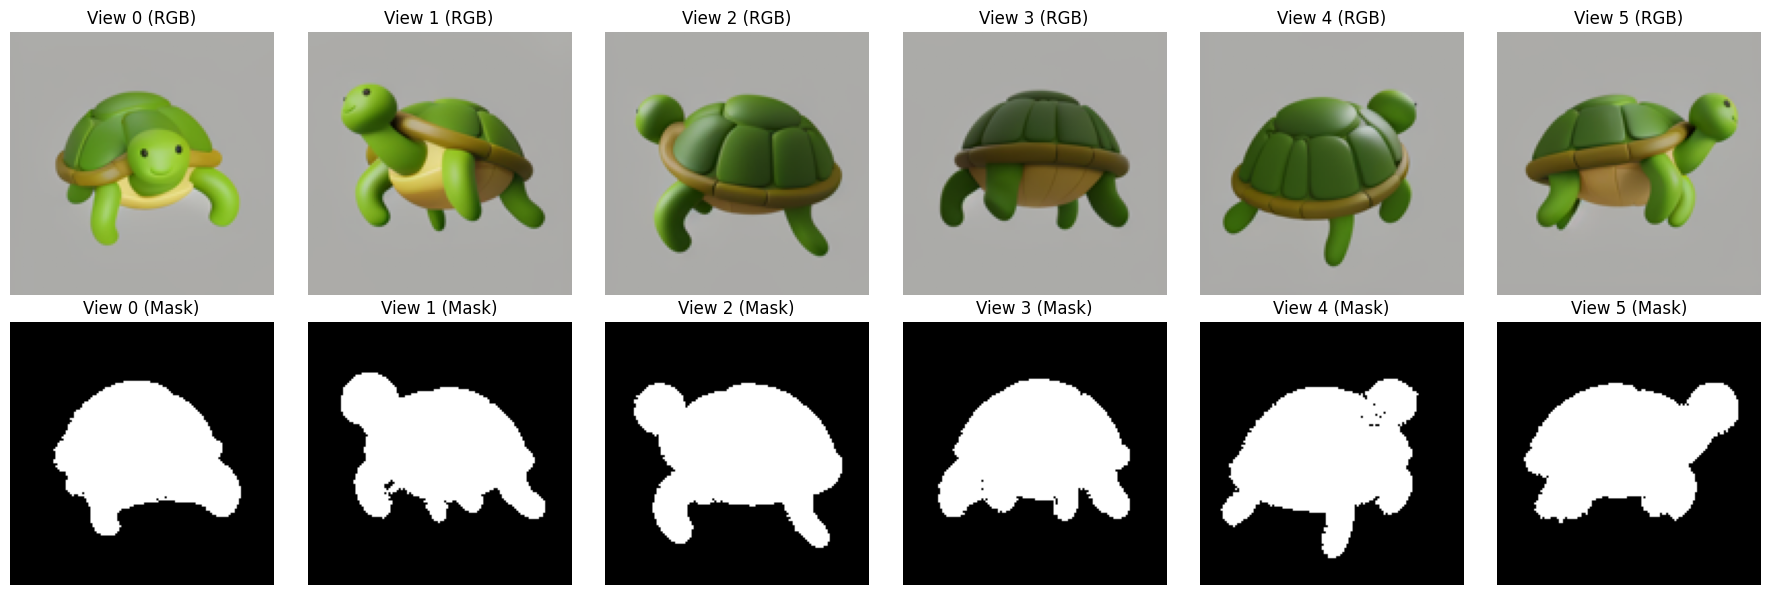

In [48]:
target_images, target_sil = load_target_images(N_VIEWS, DEVICE)
visualize_inputs(target_images, target_sil)

In [50]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

# PyTorch3D imports
from pytorch3d.structures import Meshes
from pytorch3d.utils import ico_sphere
from pytorch3d.io import save_obj
from pytorch3d.renderer import (
    FoVPerspectiveCameras, look_at_view_transform,
    RasterizationSettings, MeshRenderer, MeshRasterizer,
    SoftSilhouetteShader, BlendParams,
    PointLights, SoftPhongShader, TexturesVertex
)
from pytorch3d.loss import (
    mesh_edge_loss,
    mesh_laplacian_smoothing,
    mesh_normal_consistency,
)

In [51]:
import matplotlib.pyplot as plt


def image_grid(
    images,
    rows=None,
    cols=None,
    fill: bool = True,
    show_axes: bool = False,
    rgb: bool = True,
):
    """
    A util function for plotting a grid of images.

    Args:
        images: (N, H, W, 4) array of RGBA images
        rows: number of rows in the grid
        cols: number of columns in the grid
        fill: boolean indicating if the space between images should be filled
        show_axes: boolean indicating if the axes of the plots should be visible
        rgb: boolean, If True, only RGB channels are plotted.
            If False, only the alpha channel is plotted.

    Returns:
        None
    """
    if (rows is None) != (cols is None):
        raise ValueError("Specify either both rows and cols or neither.")

    if rows is None:
        rows = len(images)
        cols = 1

    gridspec_kw = {"wspace": 0.0, "hspace": 0.0} if fill else {}
    fig, axarr = plt.subplots(rows, cols, gridspec_kw=gridspec_kw, figsize=(15, 9))
    bleed = 0
    fig.subplots_adjust(left=bleed, bottom=bleed, right=(1 - bleed), top=(1 - bleed))

    for ax, im in zip(axarr.ravel(), images):
        if rgb:
            # only render RGB channels
            ax.imshow(im)
        else:
            # only render Alpha channel
            ax.imshow(im)
        if not show_axes:
            ax.set_axis_off()

In [59]:
# -----------------------------------------------------------------------------
# 1. SETUP & CONFIGURATION
# -----------------------------------------------------------------------------
IMAGE_SIZE = 128

# Zero123 typical defaults (adjust these to match your generation settings!)
# If your images are "front, right, back, left, top, bottom", these angles need changing.
# Below assumes a ring of 6 views around the object at fixed elevation.
ELEVATION = 0.0  # degrees
AZIMUTHS = np.linspace(0, 360, N_VIEWS, endpoint=False) # [0, 60, 120, 180, 240, 300]
DISTANCE = 2.0   # Distance from camera to object center

In [60]:
# -----------------------------------------------------------------------------
# 3. INITIALIZE SCENE
# -----------------------------------------------------------------------------

# Load Data
target_rgb, target_cameras_mask = load_target_images(N_VIEWS, DEVICE)

# Place a point light in front of the object. As mentioned above, the front of
# the cow is facing the -z direction.
lights = PointLights(device=device, location=[[0.0, 0.0, -3.0]])

# Setup Cameras
# We create a batch of N_VIEWS cameras
R, T = look_at_view_transform(dist=DISTANCE, elev=ELEVATION, azim=AZIMUTHS)
cameras = FoVPerspectiveCameras(device=DEVICE, R=R, T=T) # Zero123 often uses ~40-50 FOV

camera = FoVPerspectiveCameras(device=device, R=R[None, 1, ...],
                                  T=T[None, 1, ...])

# Initialize Source Mesh (Icosphere)
# Level 3 is a good balance (~642 verts, 1280 faces). Level 4 is smoother but slower.
src_mesh = ico_sphere(4, DEVICE)

# We want to optimize offsets, not absolute positions, to keep it stable
deform_verts = torch.zeros_like(src_mesh.verts_packed(), requires_grad=True, device=DEVICE)

# Setup Renderer (Silhouette Only for Geometry Fitting)
# We only care about the silhouette shader for deforming geometry to fit the mask
blend_params = BlendParams(sigma=1e-4, gamma=1e-4)
raster_settings = RasterizationSettings(
    image_size=IMAGE_SIZE,
    blur_radius=0.0,
    faces_per_pixel=1,
)

renderer_silhouette = MeshRenderer(
    rasterizer=MeshRasterizer(
        cameras=cameras,
        raster_settings=raster_settings
    ),
    shader=SoftSilhouetteShader(blend_params=blend_params)
)

# Optimizer
optimizer = torch.optim.Adam([deform_verts], lr=LR)

target_cameras = [FoVPerspectiveCameras(device=device, R=R[None, i, ...],
                                           T=T[None, i, ...]) for i in range(N_VIEWS)]

Loading 6 images...


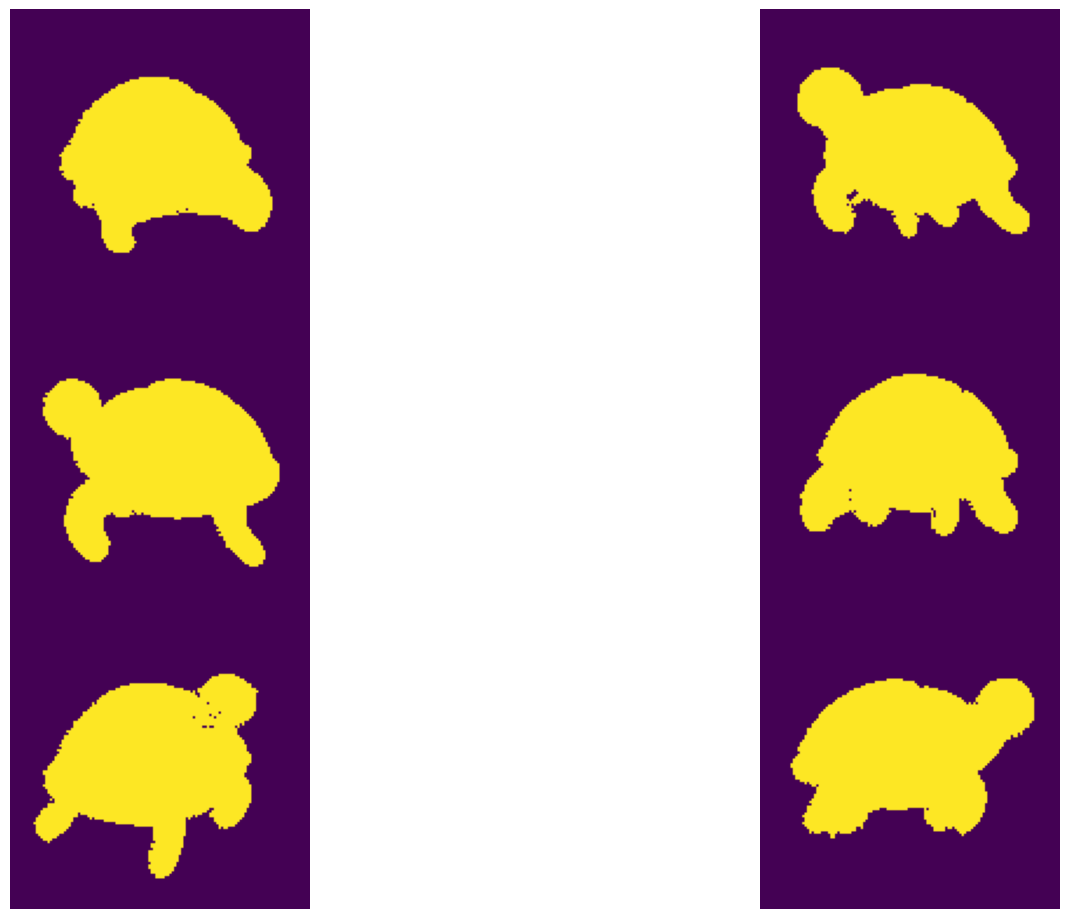

In [61]:
# Rasterization settings for silhouette rendering
sigma = 1e-4
raster_settings_silhouette = RasterizationSettings(
    image_size=IMAGE_SIZE,
    blur_radius=np.log(1. / 1e-4 - 1.)*sigma,
    faces_per_pixel=50,
)

# Silhouette renderer
renderer_silhouette = MeshRenderer(
    rasterizer=MeshRasterizer(
        cameras=camera,
        raster_settings=raster_settings_silhouette
    ),
    shader=SoftSilhouetteShader()
)

# Visualize silhouette images
image_grid(target_sil.cpu().numpy(), rows=3, cols=2, rgb=False)
plt.show()

In [62]:
# We initialize the source shape to be a sphere of radius 1.
src_mesh = ico_sphere(5, device)

In [63]:
# Rasterization settings for differentiable rendering, where the blur_radius
# initialization is based on Liu et al, 'Soft Rasterizer: A Differentiable
# Renderer for Image-based 3D Reasoning', ICCV 2019
sigma = 1e-4
raster_settings_soft = RasterizationSettings(
    image_size=IMAGE_SIZE,
    blur_radius=np.log(1. / 1e-4 - 1.)*sigma,
    faces_per_pixel=50,
)

# Silhouette renderer
renderer_silhouette = MeshRenderer(
    rasterizer=MeshRasterizer(
        cameras=camera,
        raster_settings=raster_settings_soft
    ),
    shader=SoftSilhouetteShader()
)

In [67]:
# Show a visualization comparing the rendered predicted mesh to the ground truth
# mesh
def visualize_prediction(predicted_mesh, renderer=renderer_silhouette,
                         target_image=target_rgb[1], title='',
                         silhouette=False):
    inds = 3 if silhouette else range(3)
    with torch.no_grad():
        predicted_images = renderer(predicted_mesh)
    plt.figure(figsize=(20, 10))
    plt.subplot(1, 2, 1)
    plt.imshow(predicted_images[0, ..., inds].cpu().detach().numpy())

    plt.subplot(1, 2, 2)
    plt.imshow(target_image.cpu().detach().numpy())
    plt.title(title)
    plt.axis("off")

# Plot losses as a function of optimization iteration
def plot_losses(losses):
    fig = plt.figure(figsize=(13, 5))
    ax = fig.gca()
    for k, l in losses.items():
        ax.plot(l['values'], label=k + " loss")
    ax.legend(fontsize="16")
    ax.set_xlabel("Iteration", fontsize="16")
    ax.set_ylabel("Loss", fontsize="16")
    ax.set_title("Loss vs iterations", fontsize="16")

In [88]:
LR = 0.05  # Learning rate
ITERATIONS = 2000

In [92]:
# Number of views to optimize over in each SGD iteration
num_views_per_iteration = 2
# Plot period for the losses
plot_period = 250

%matplotlib inline

# Optimize using rendered silhouette image loss, mesh edge loss, mesh normal
# consistency, and mesh laplacian smoothing
losses = {"silhouette": {"weight": 1.0, "values": []},
          "edge": {"weight": 1.0, "values": []},
          "normal": {"weight": 0.5, "values": []},
          "laplacian": {"weight": 1.0, "values": []},
         }

# Losses to smooth / regularize the mesh shape
def update_mesh_shape_prior_losses(mesh, loss):
    # and (b) the edge length of the predicted mesh
    loss["edge"] = mesh_edge_loss(mesh)

    # mesh normal consistency
    loss["normal"] = mesh_normal_consistency(mesh)

    # mesh laplacian smoothing
    loss["laplacian"] = mesh_laplacian_smoothing(mesh, method="uniform")

# We will learn to deform the source mesh by offsetting its vertices
# The shape of the deform parameters is equal to the total number of vertices in
# src_mesh
verts_shape = src_mesh.verts_packed().shape
deform_verts = torch.full(verts_shape, 0.0, device=device, requires_grad=True)

In [ ]:
LR = 0.01  # Learning rate

# The optimizer
optimizer = torch.optim.Adam([deform_verts], lr=LR)
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=200, gamma=0.9)

In [ ]:
ITERATIONS = 12000

total_loss = 0.078860:  42%|████▏     | 5000/12000 [02:19<03:23, 34.43it/s]/tmp/ipython-input-2628694592.py:9: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(20, 10))
total_loss = 0.075417: 100%|██████████| 12000/12000 [05:46<00:00, 34.63it/s]


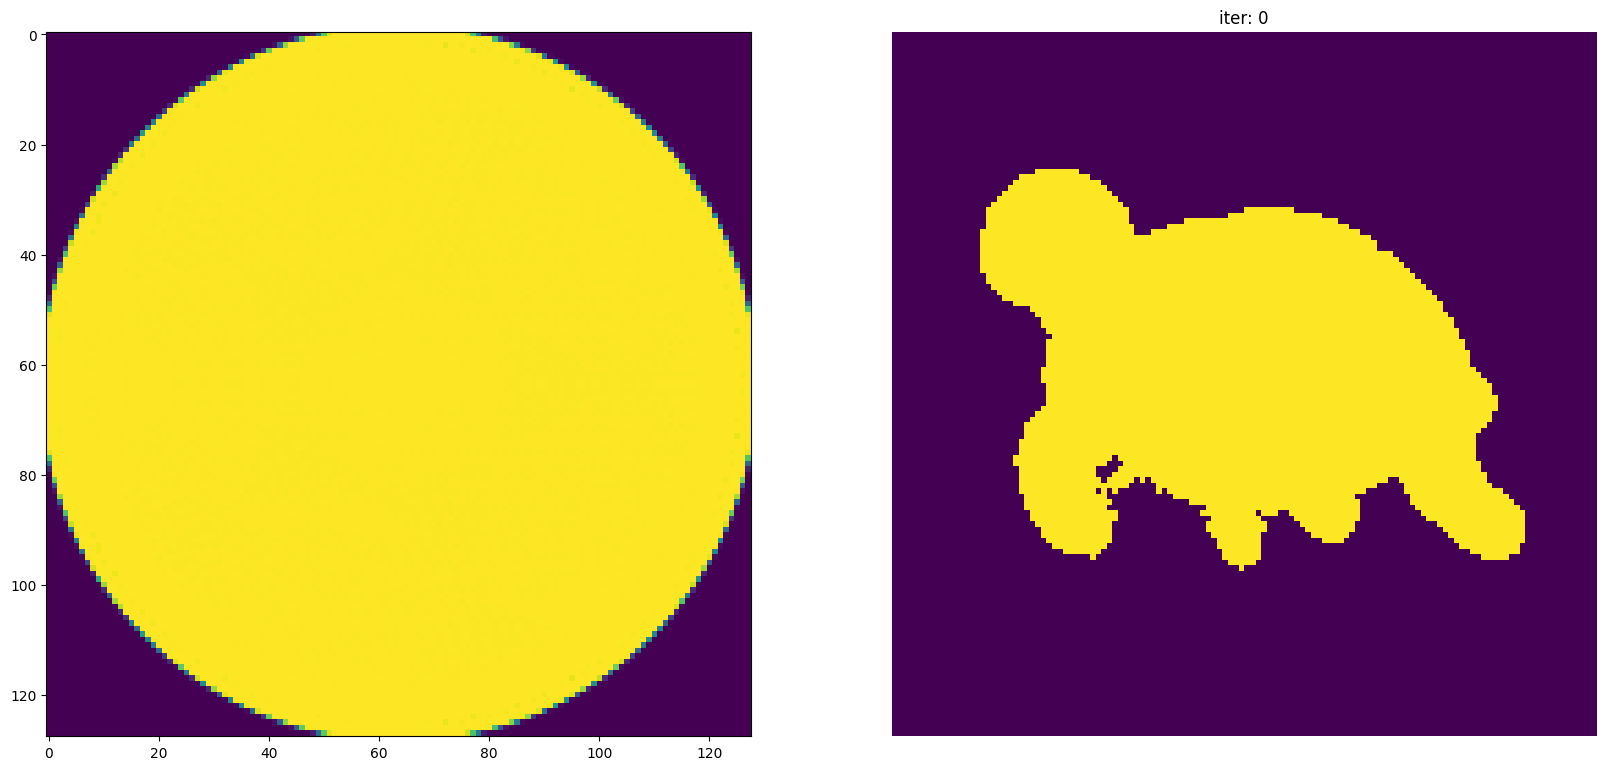

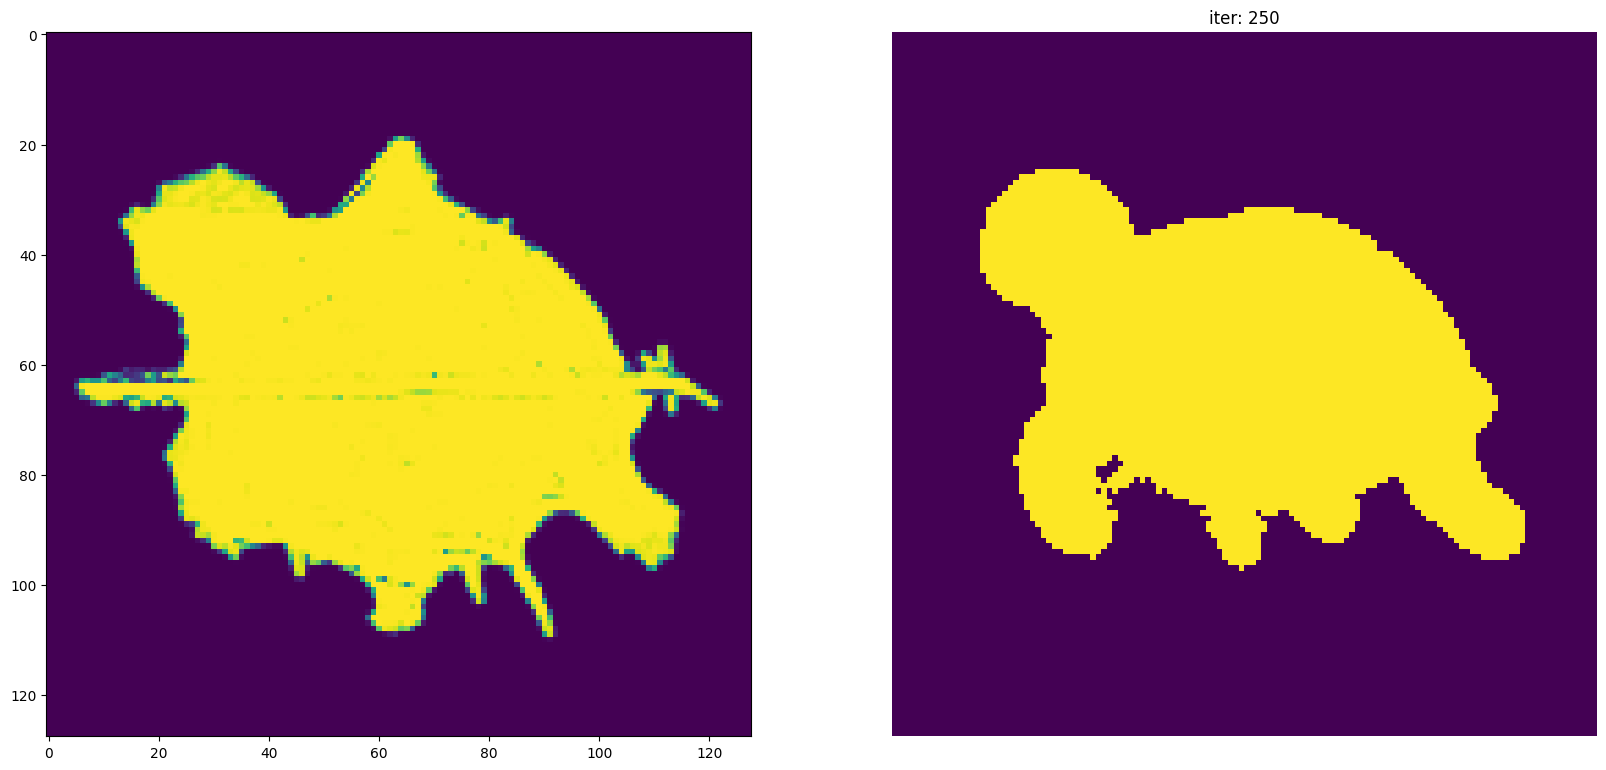

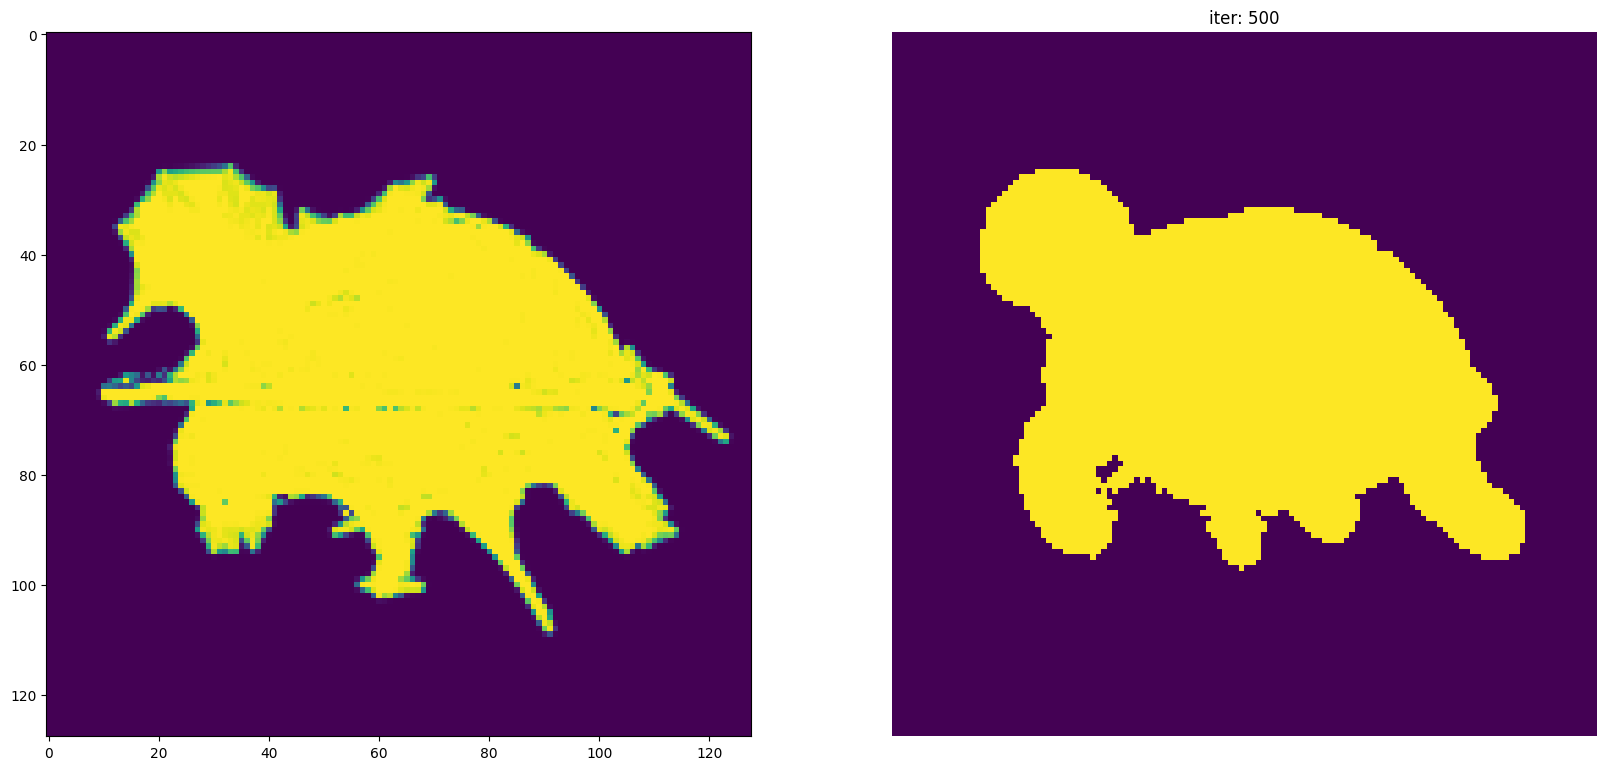

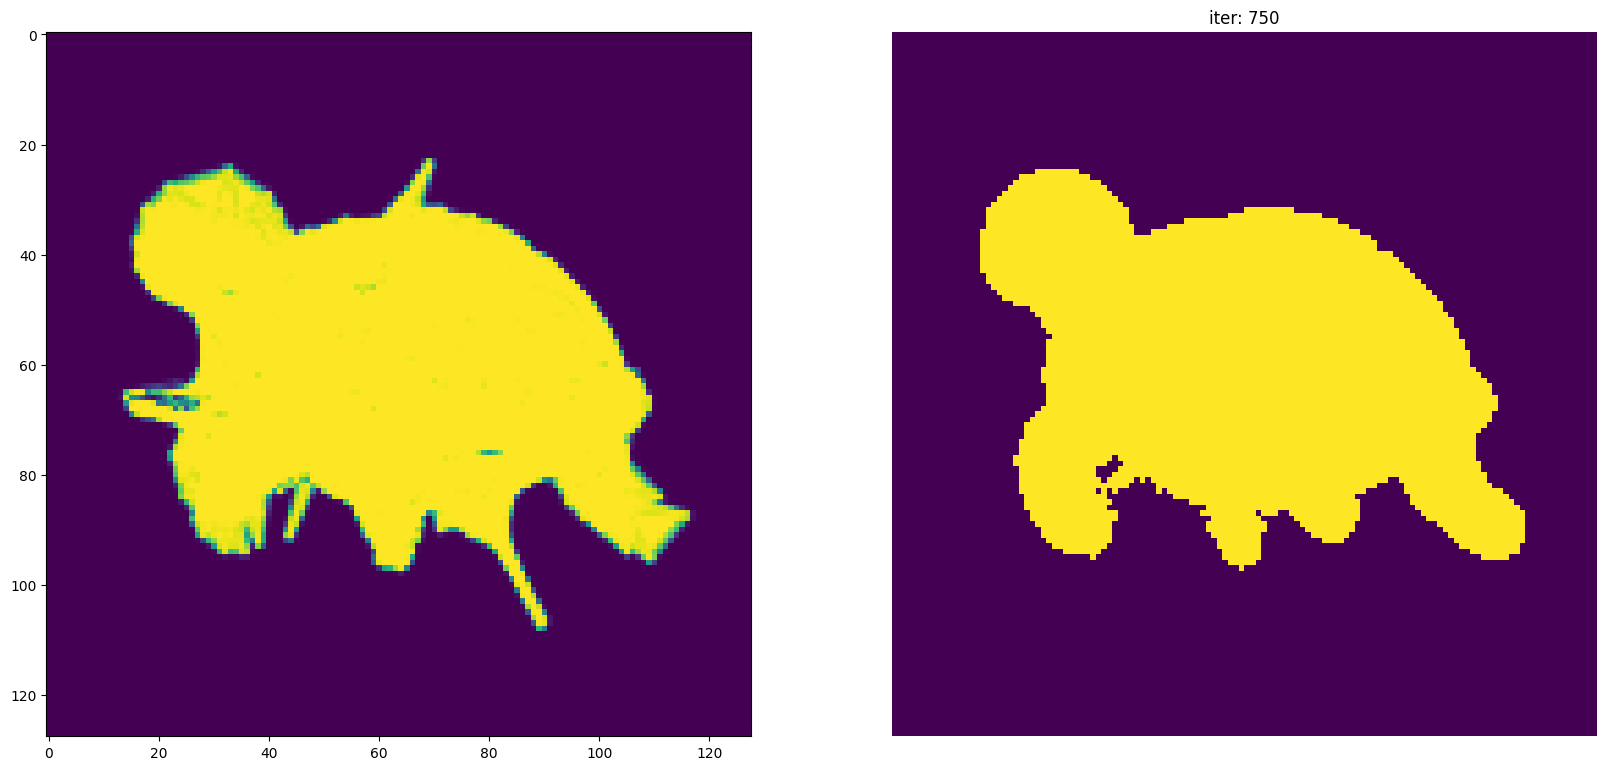

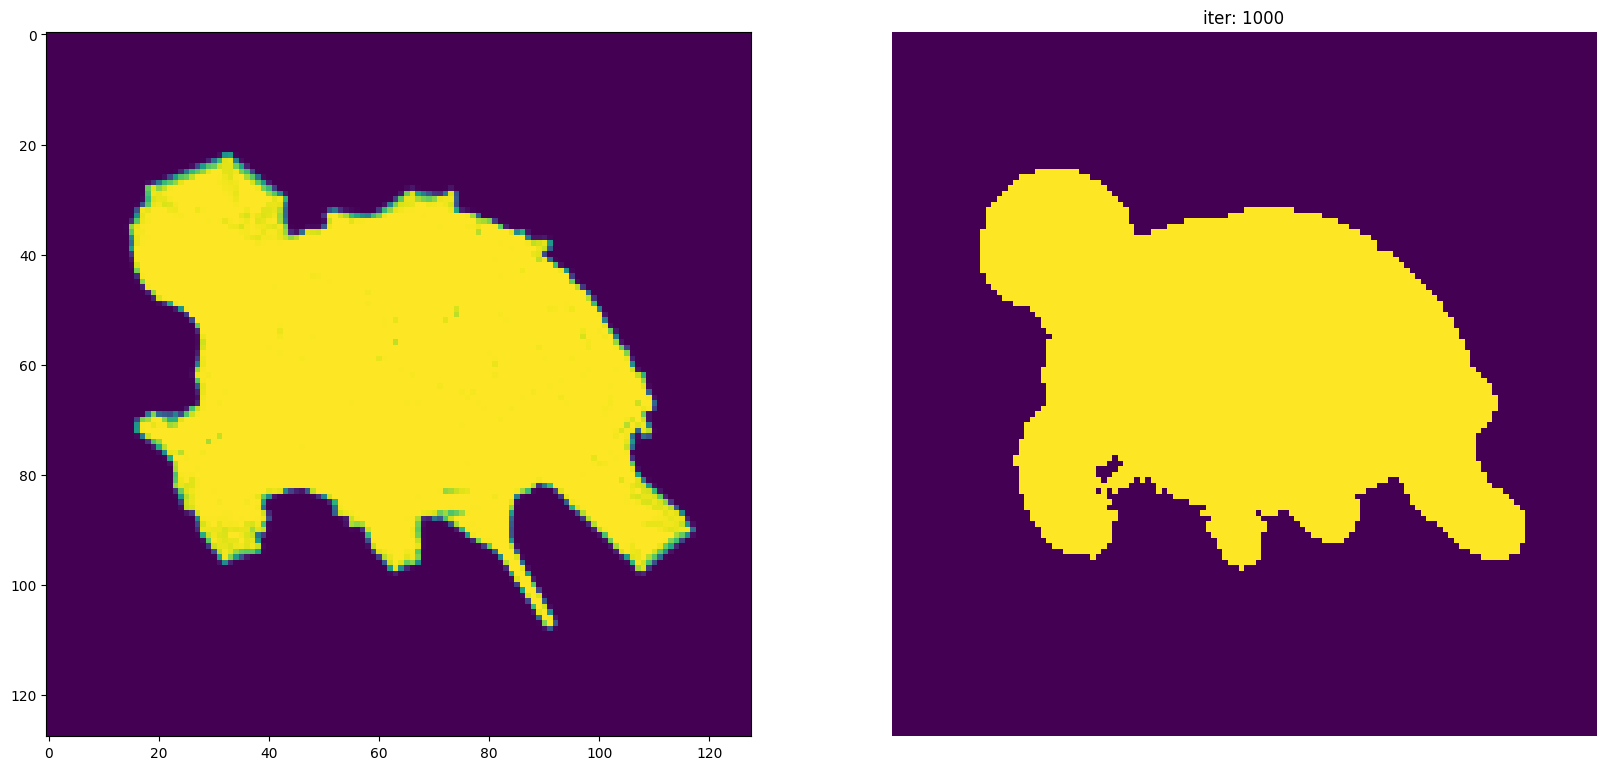

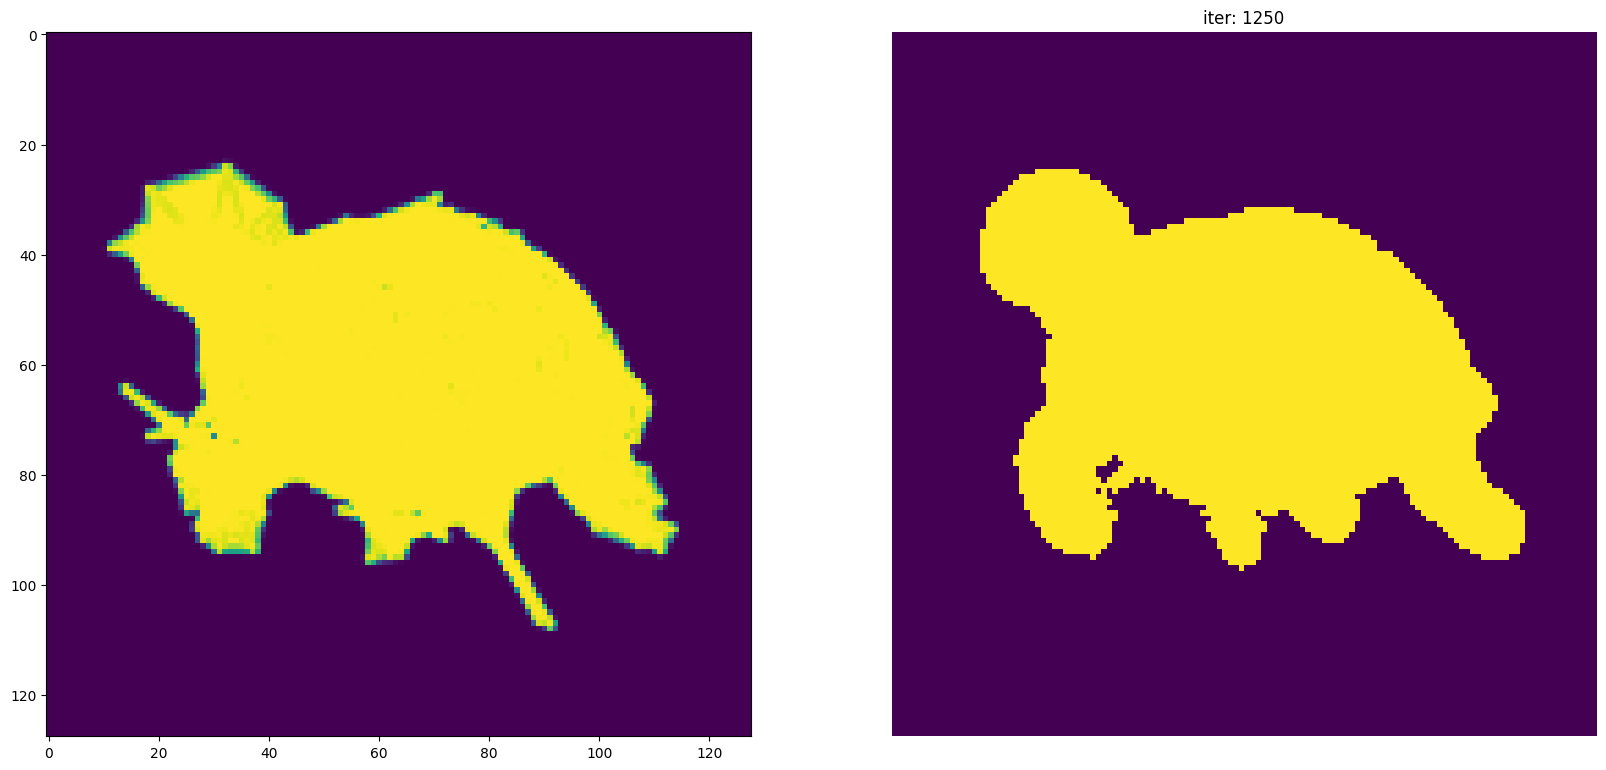

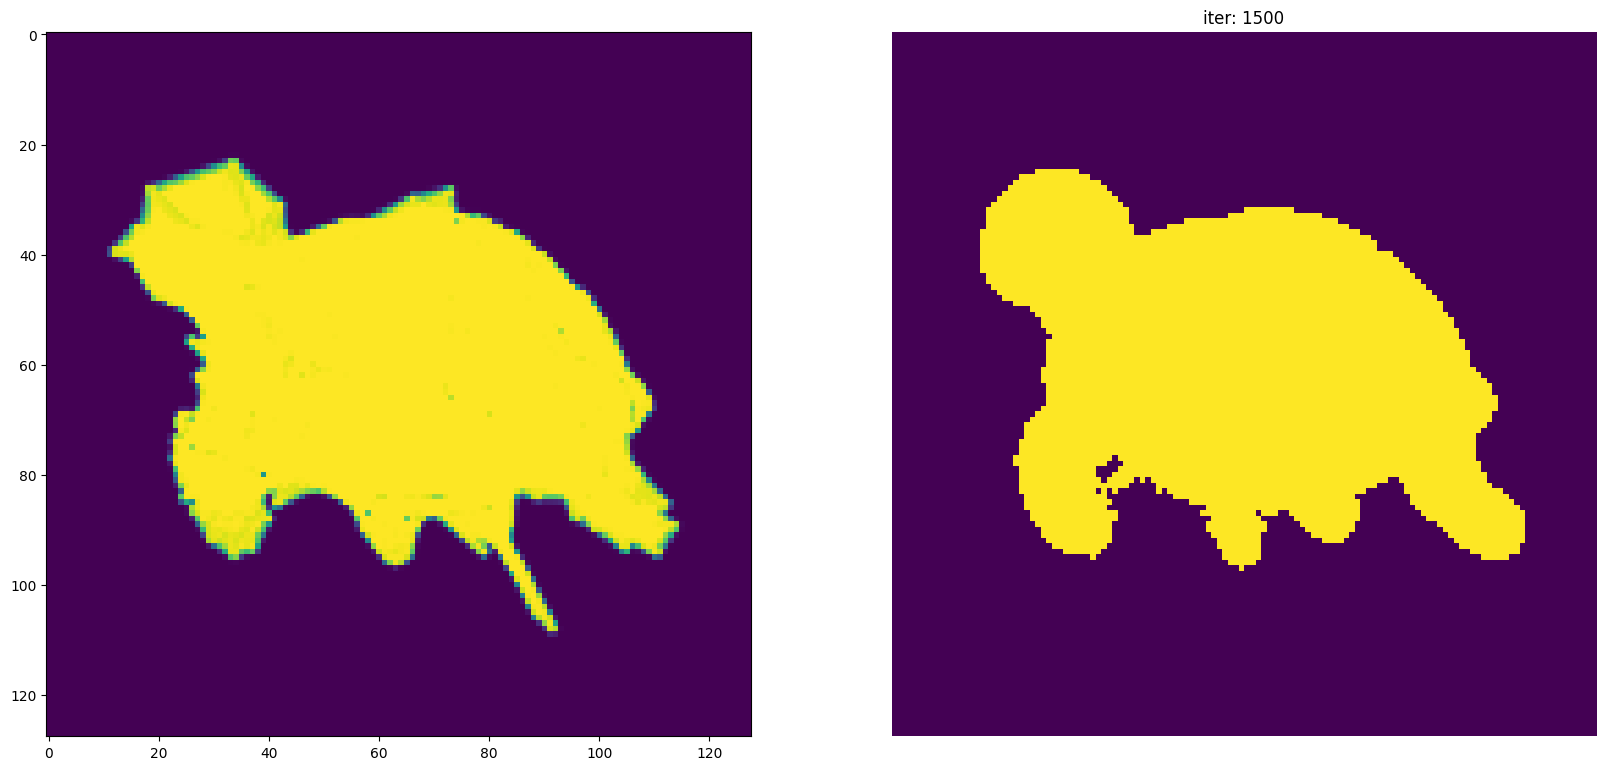

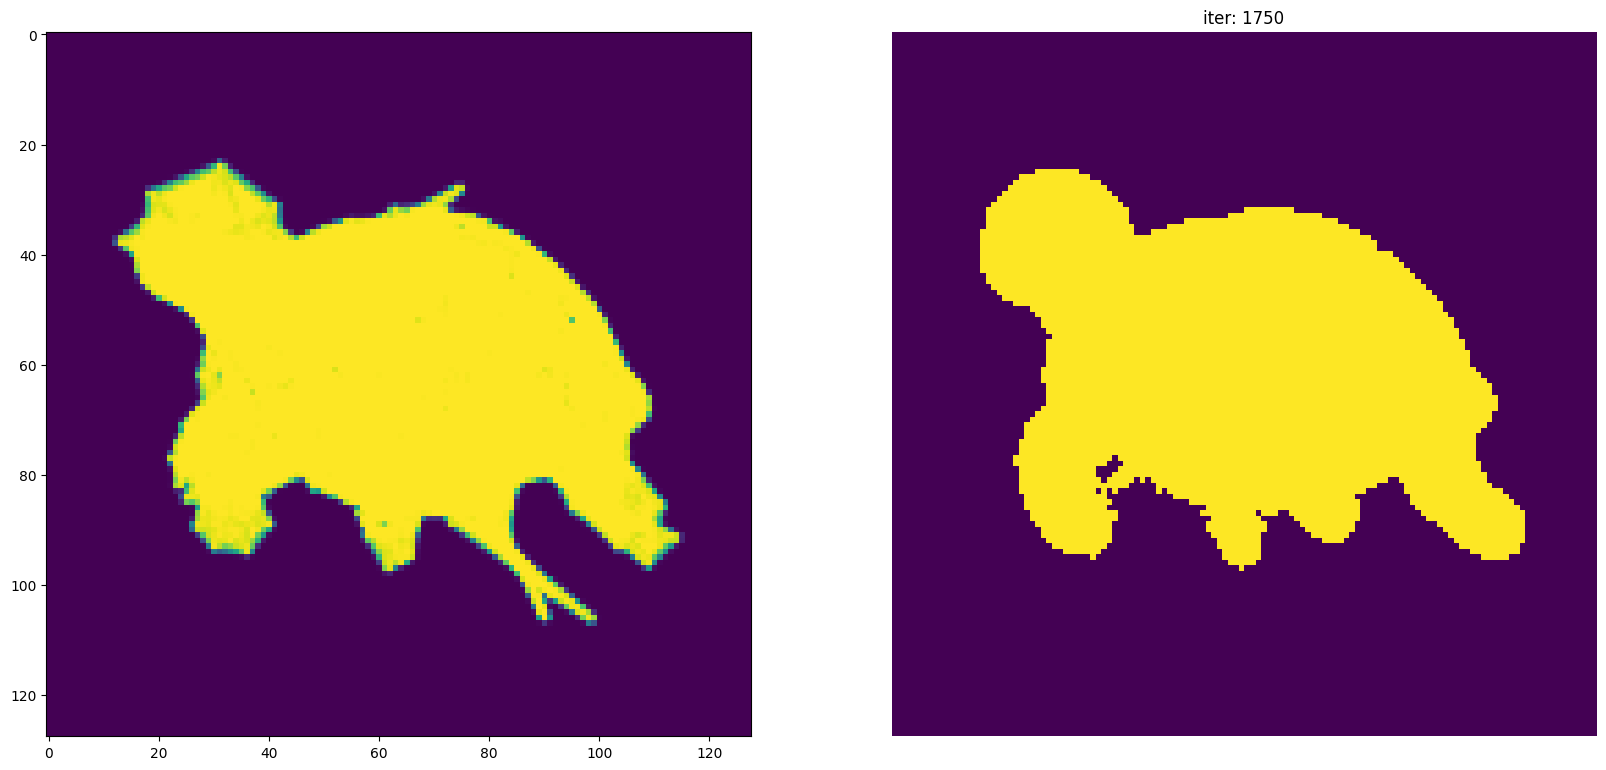

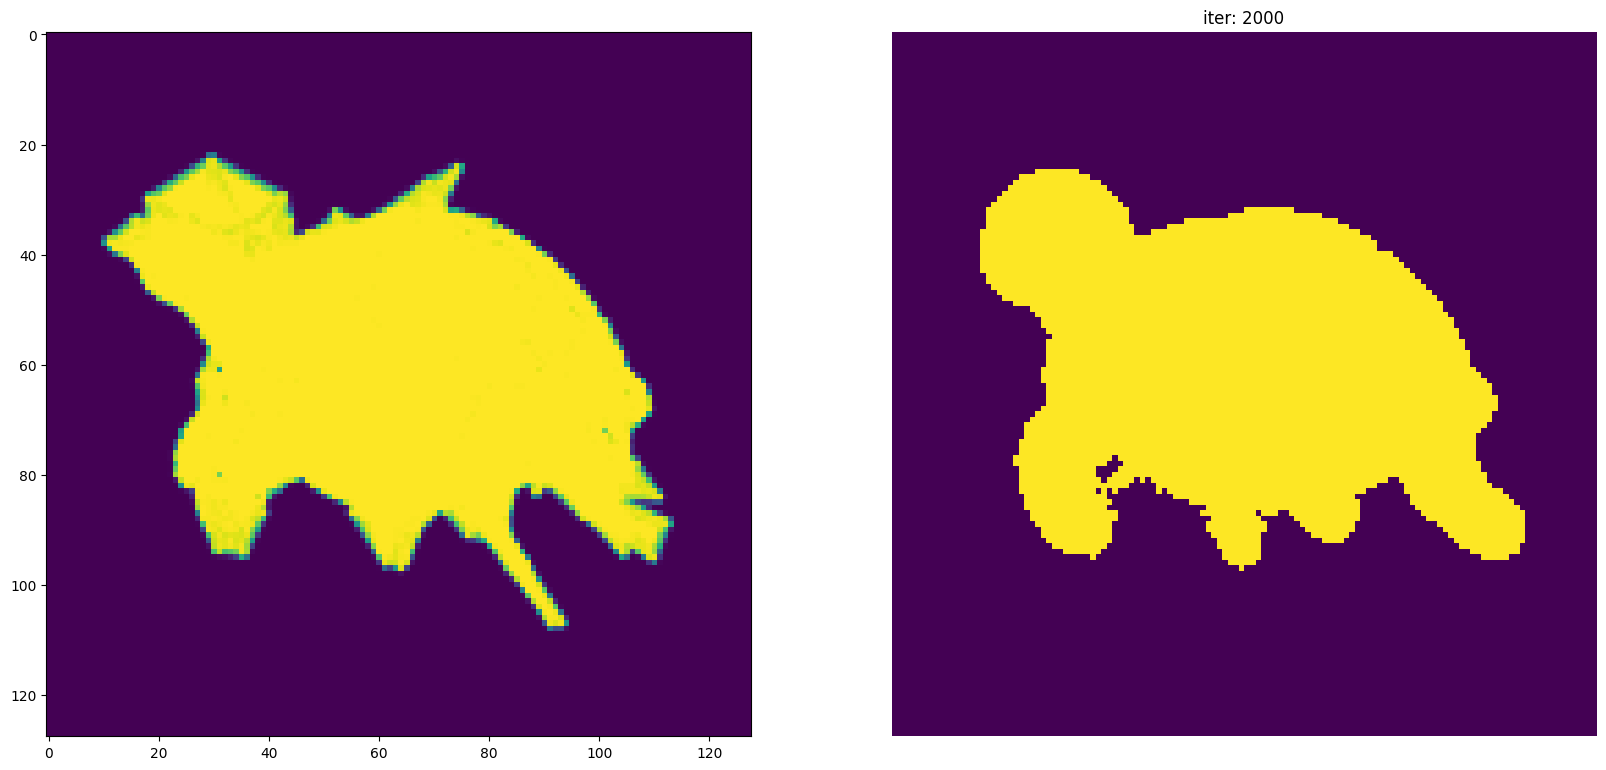

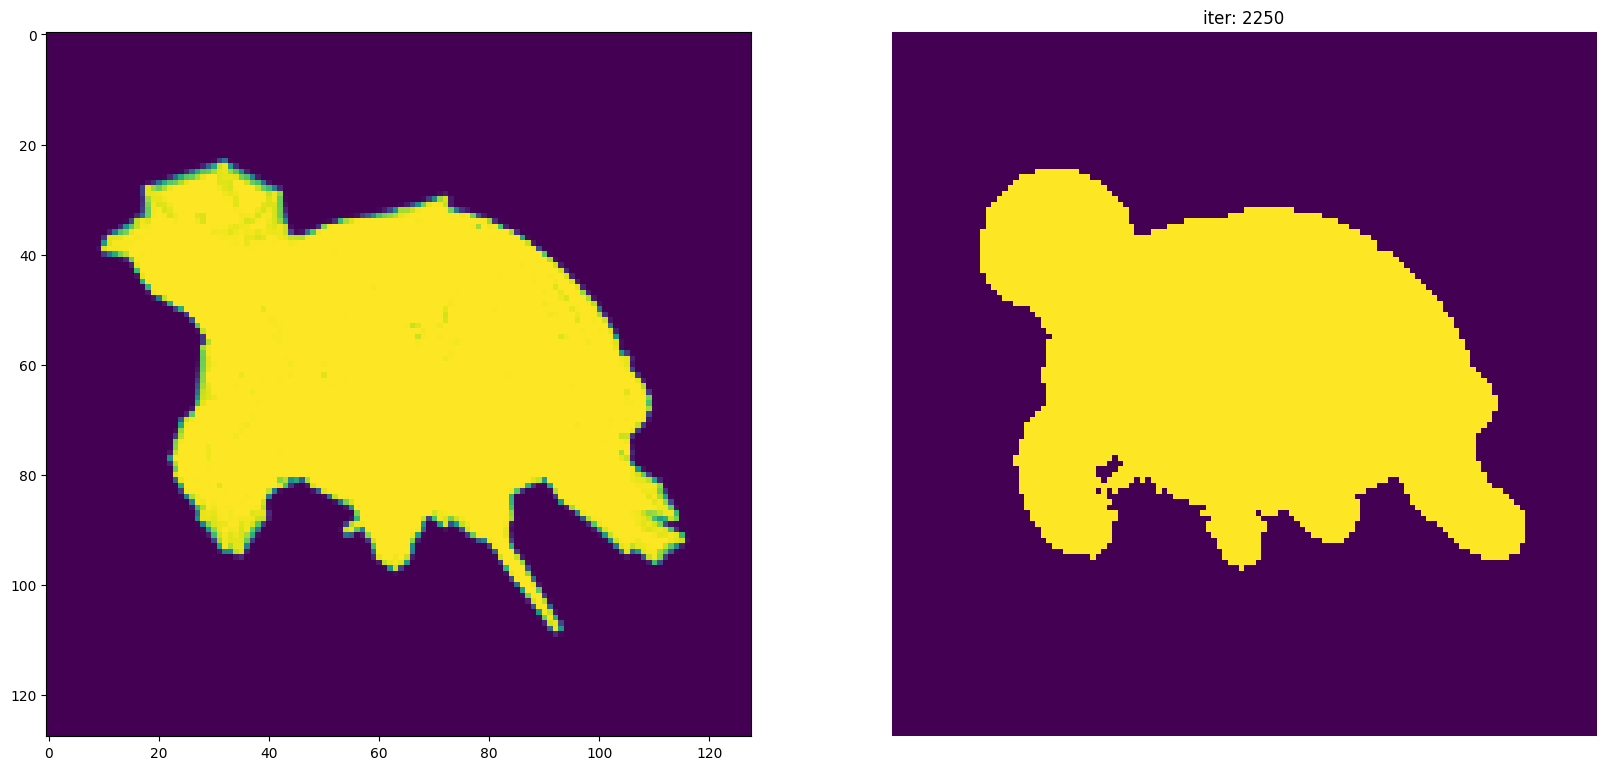

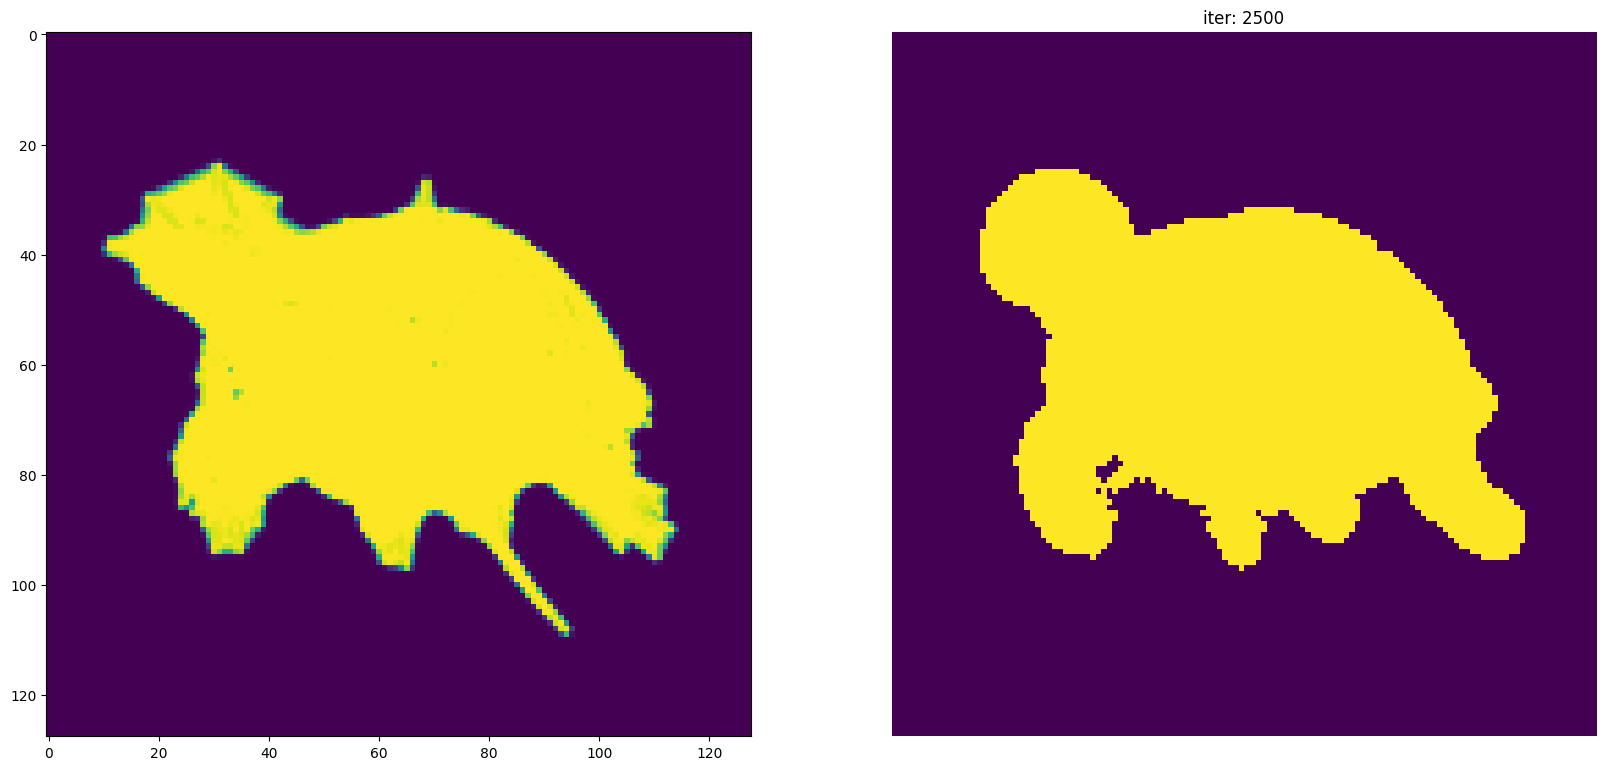

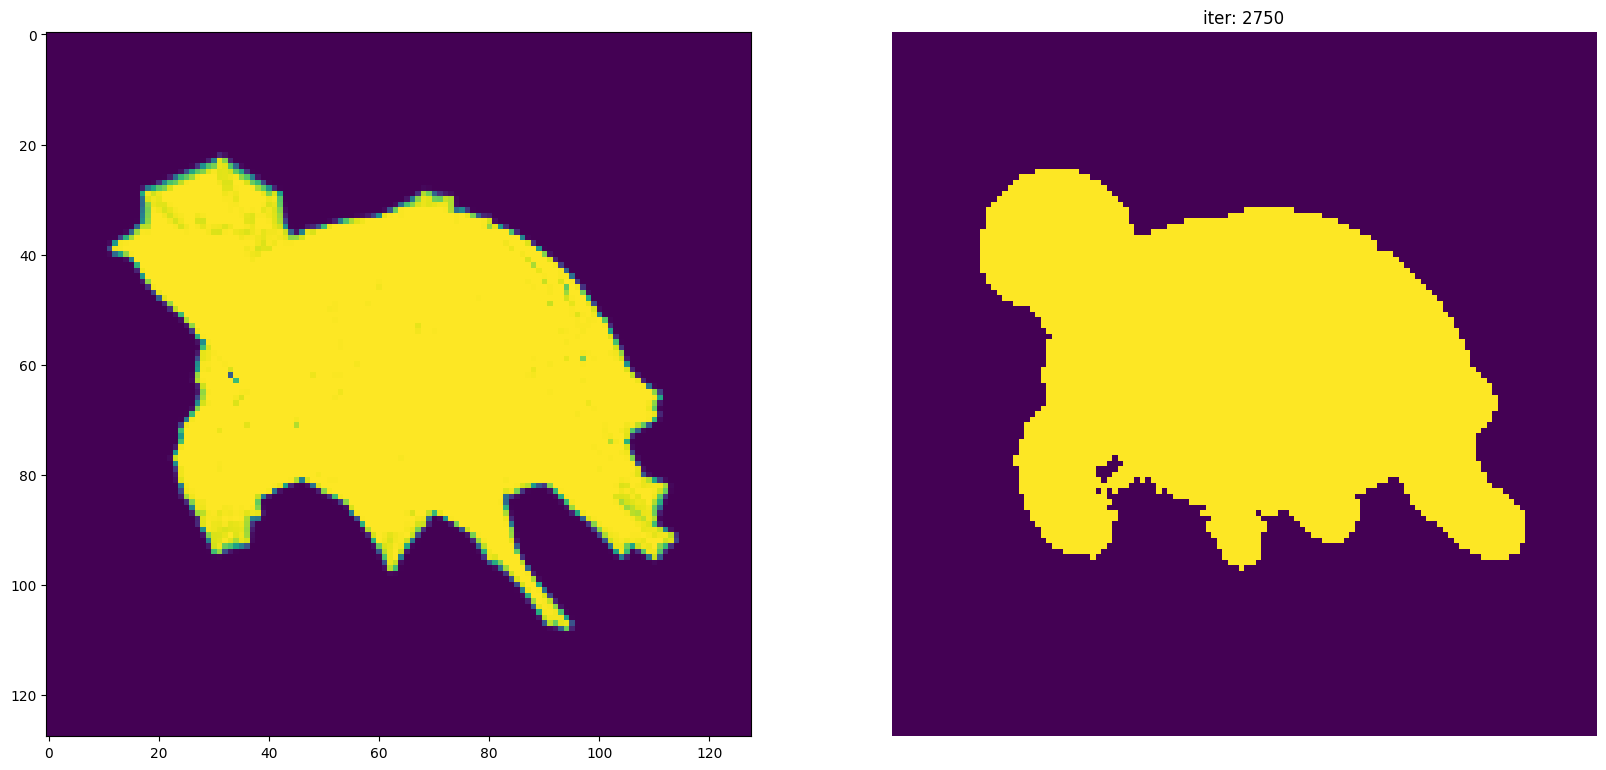

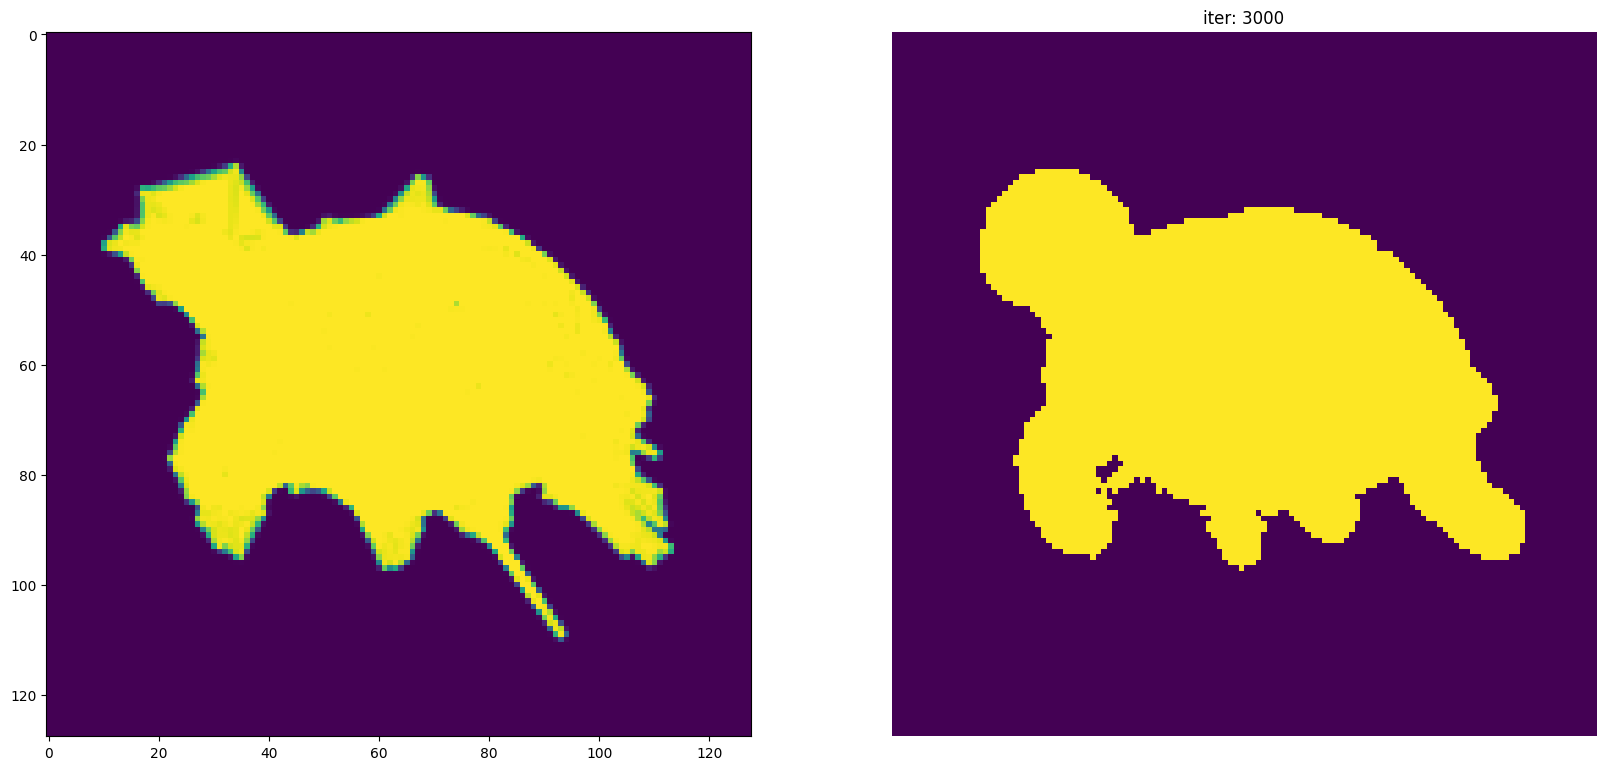

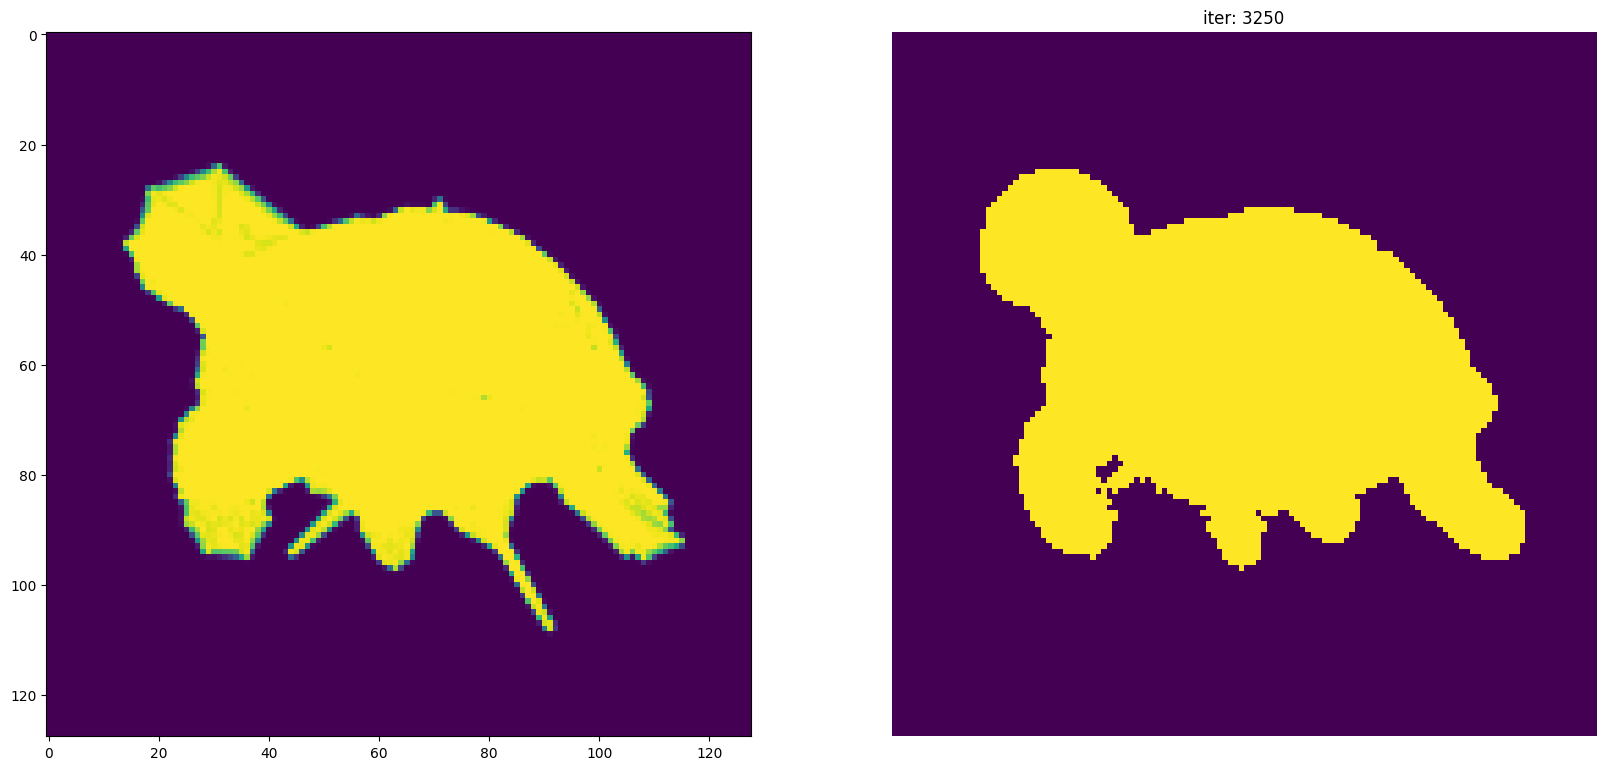

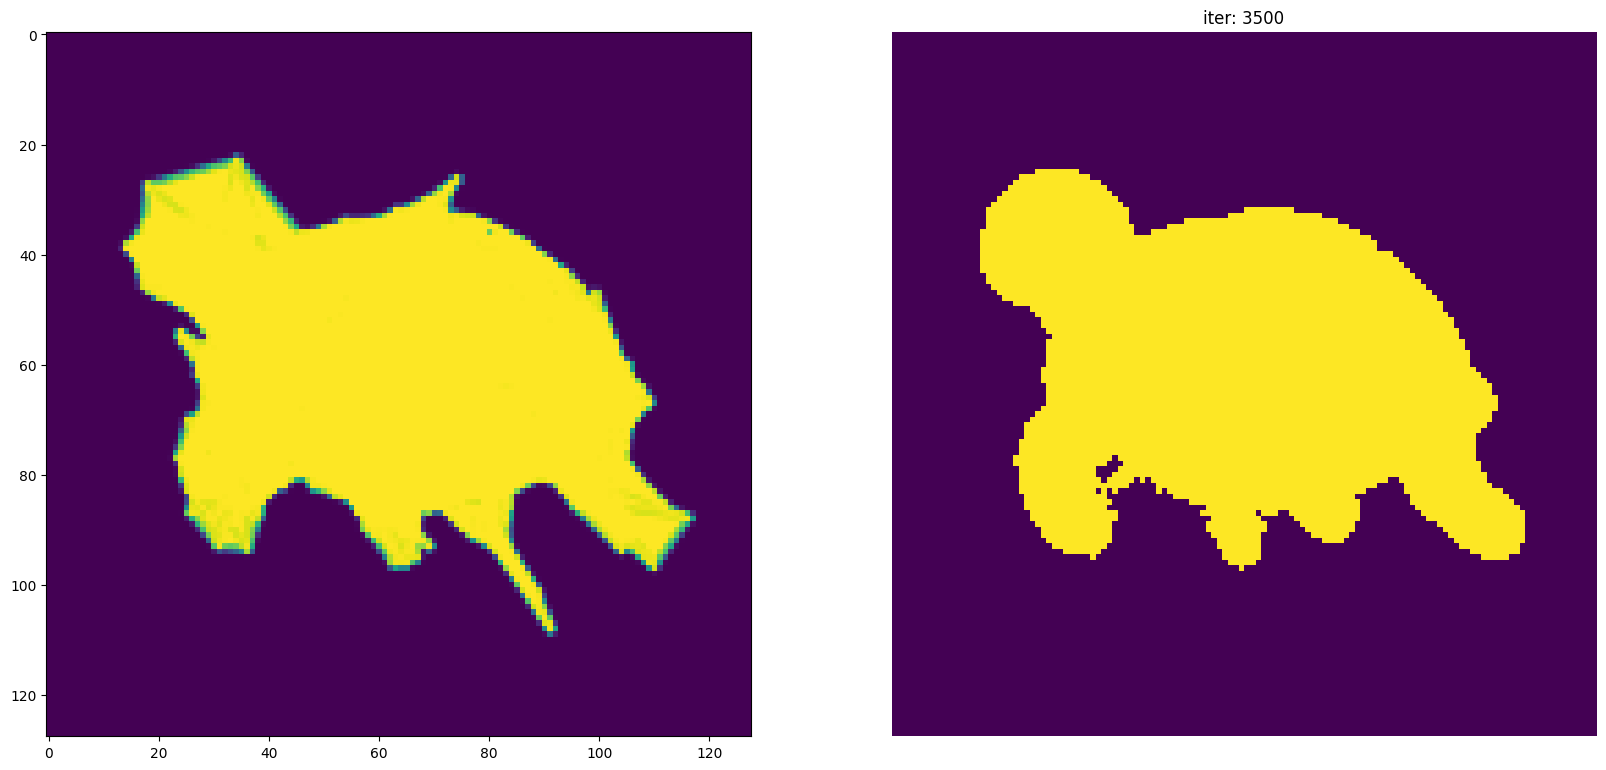

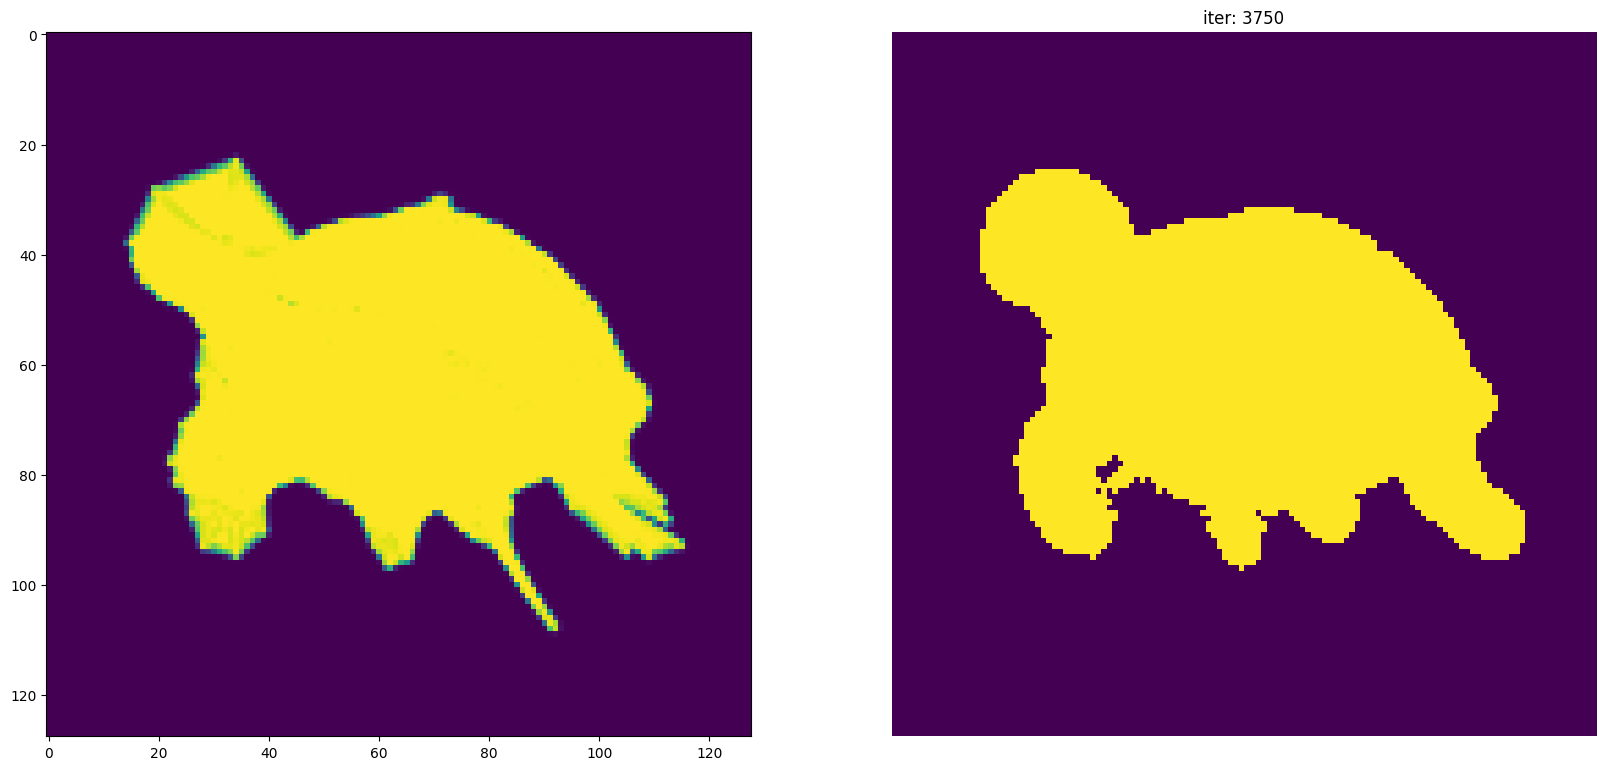

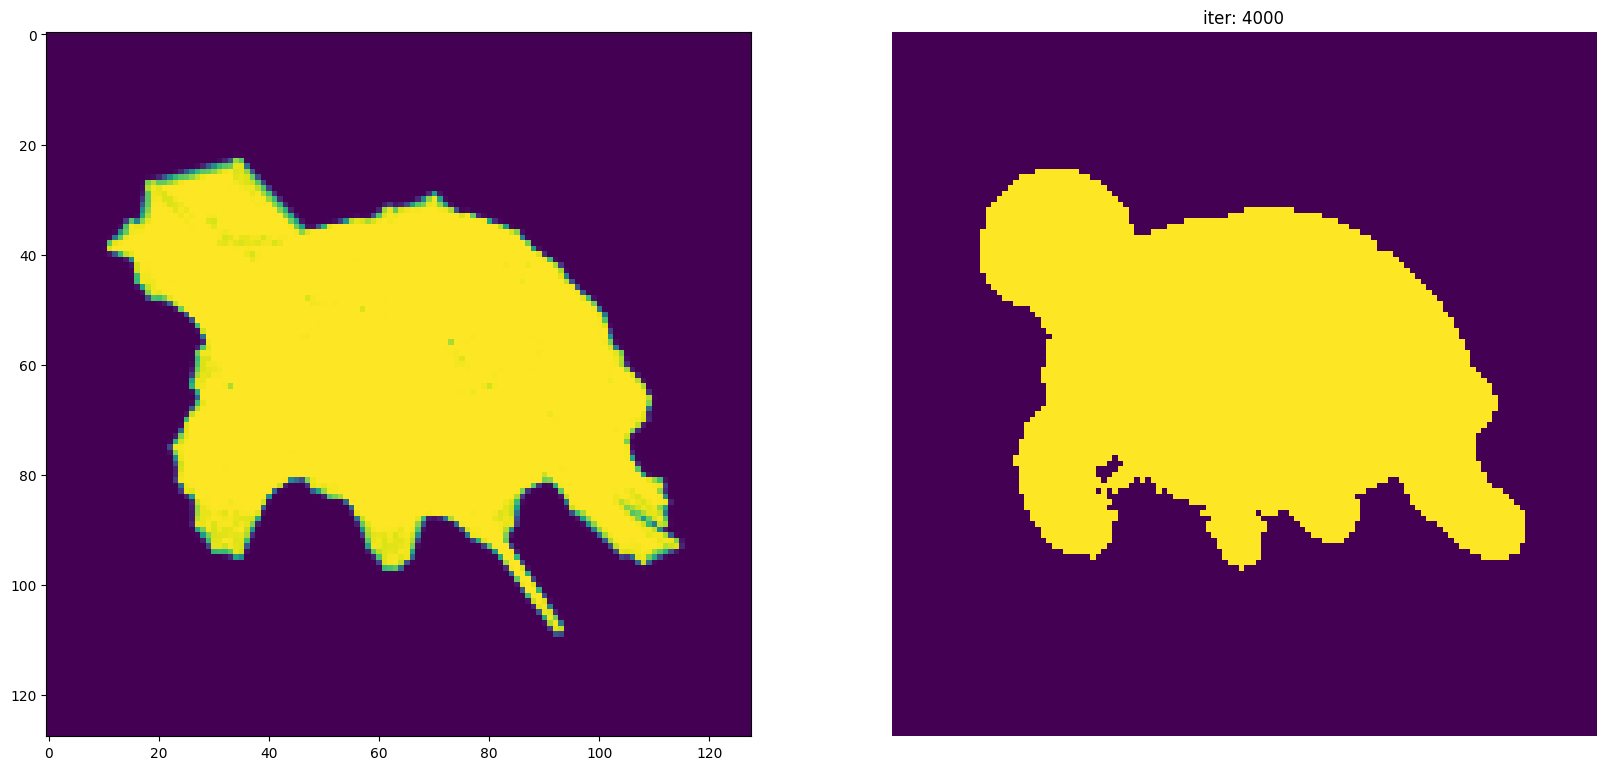

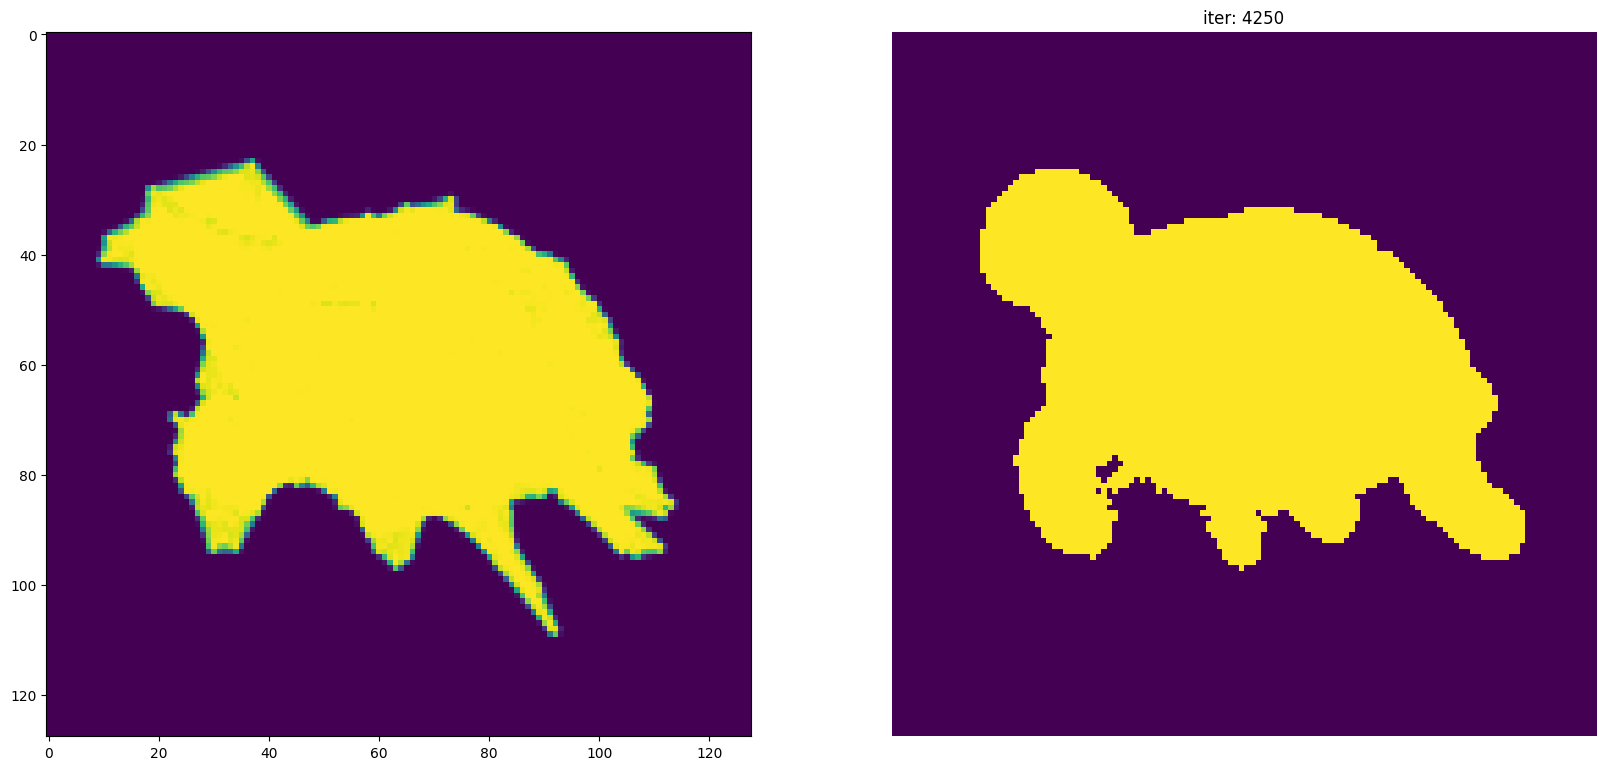

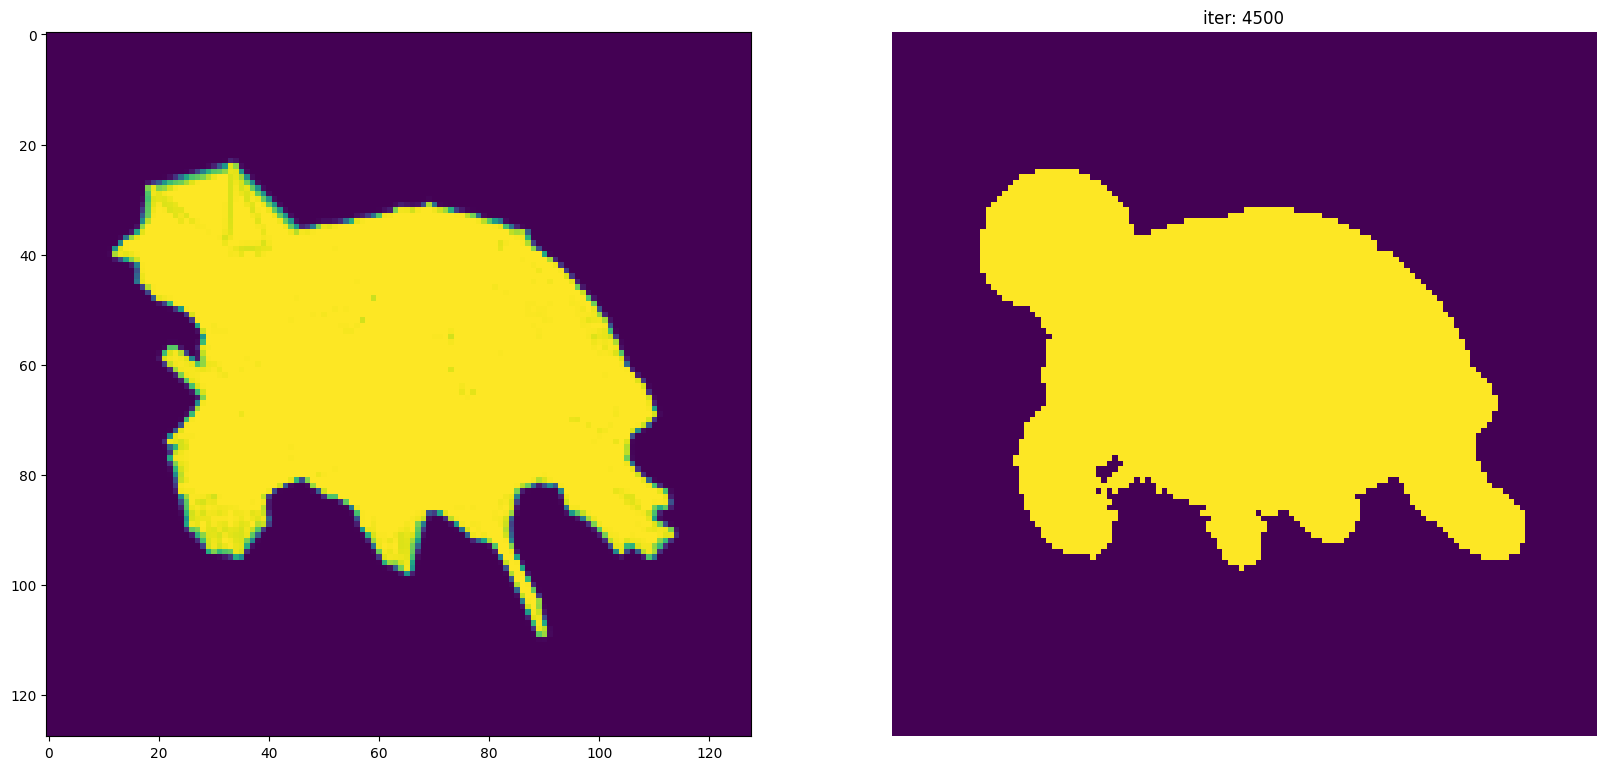

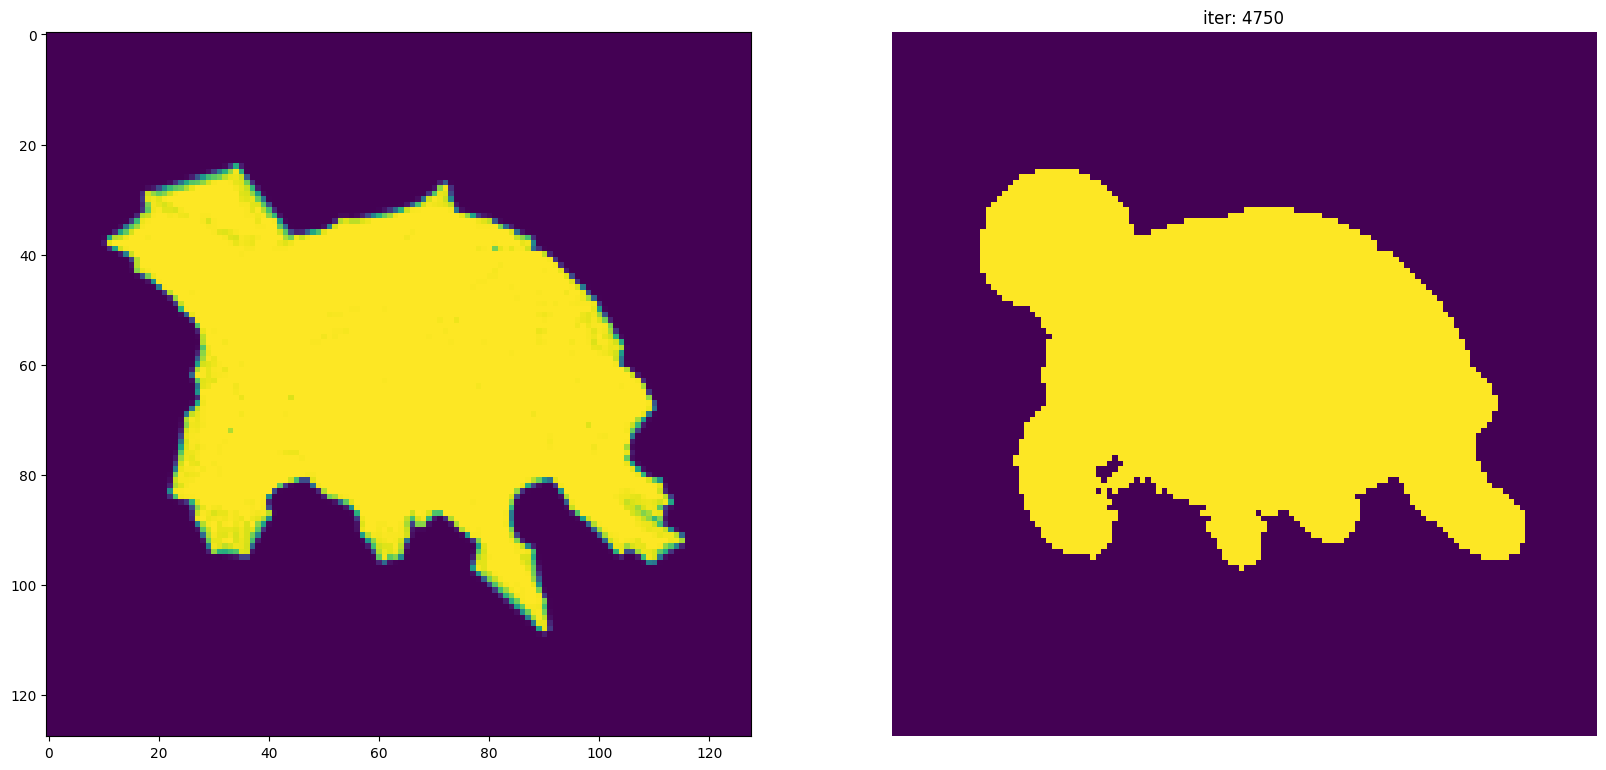

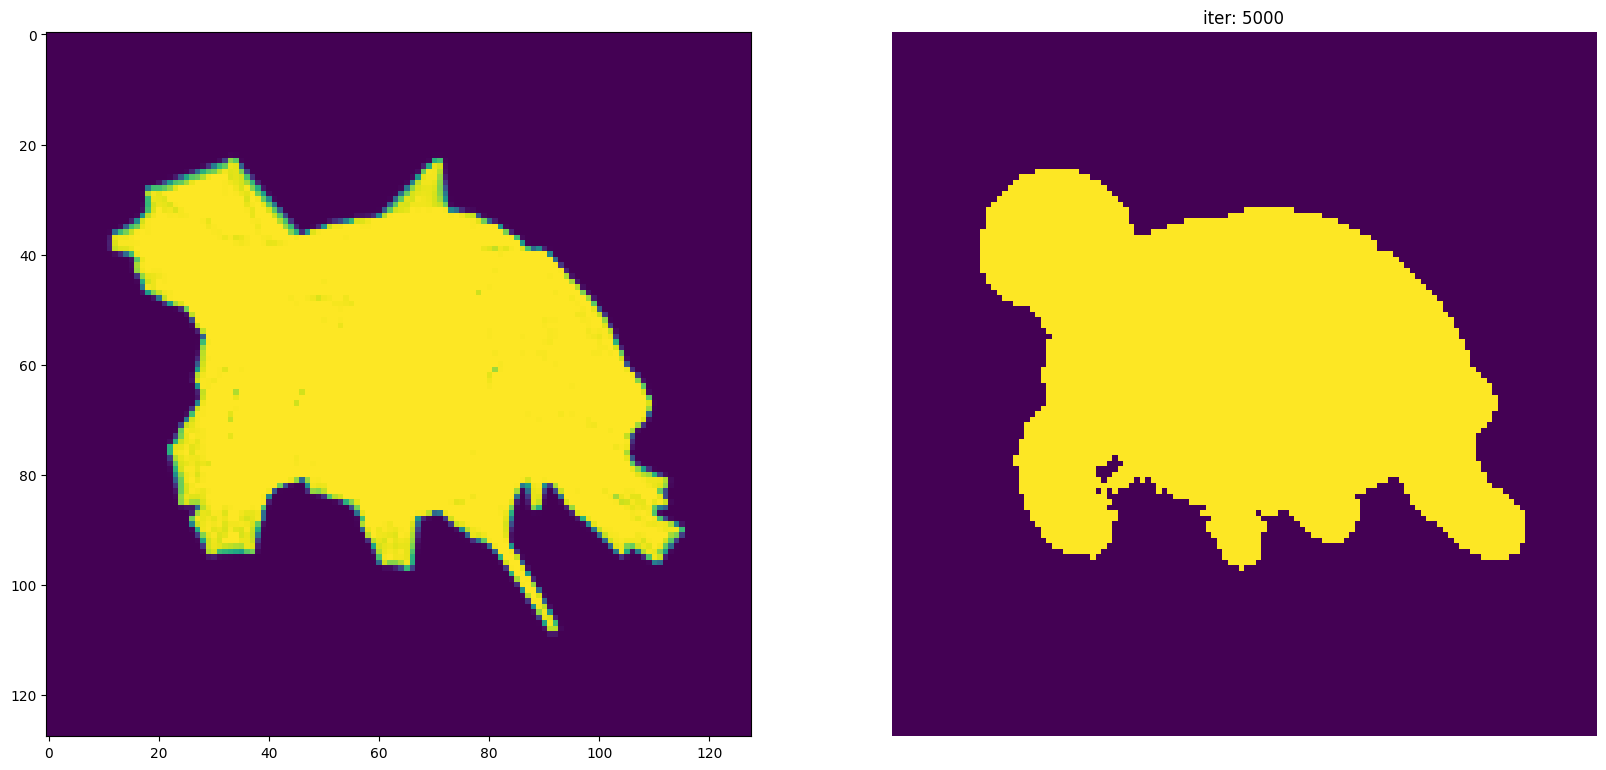

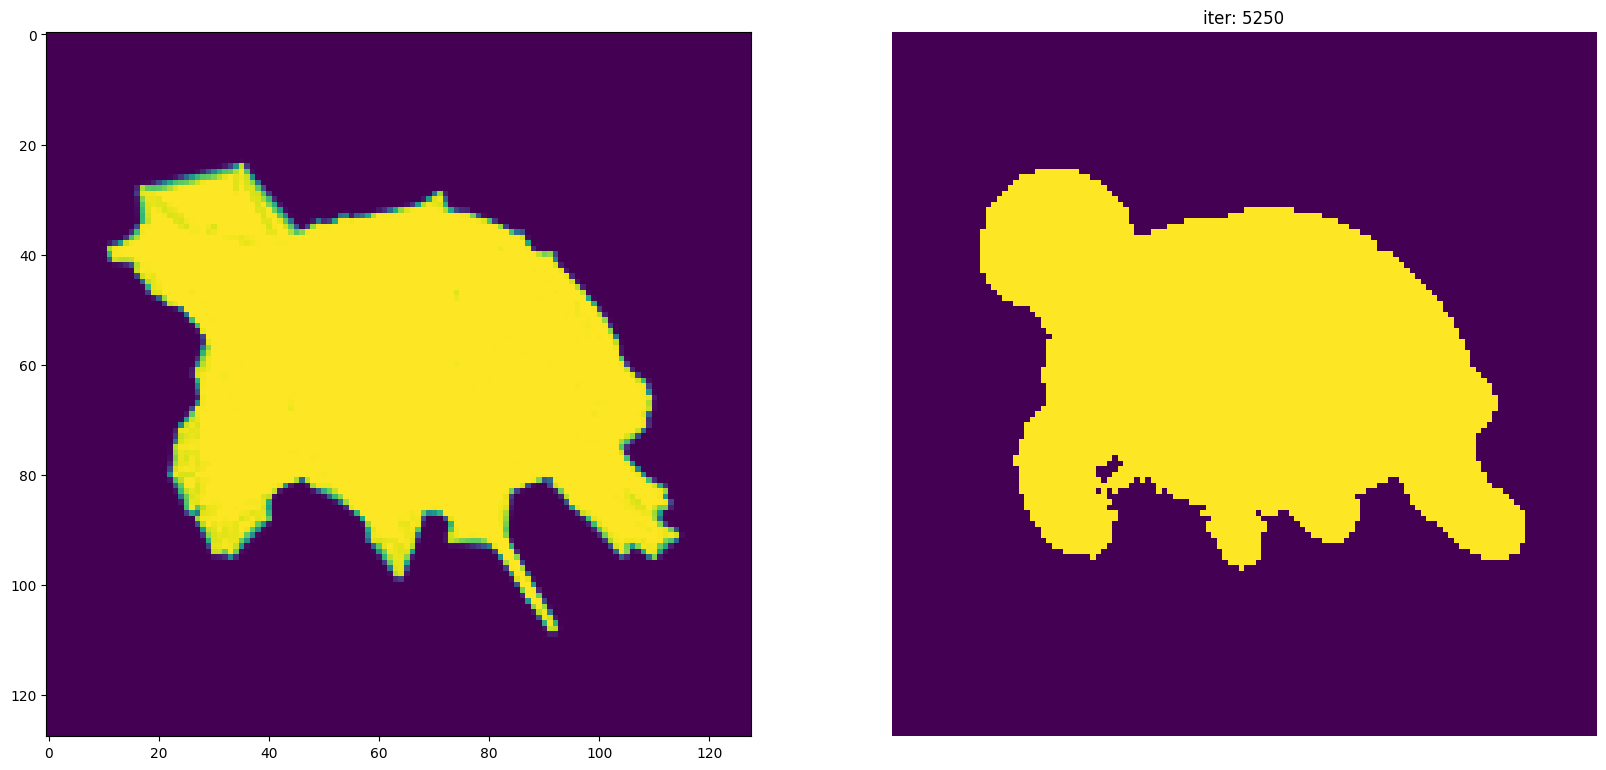

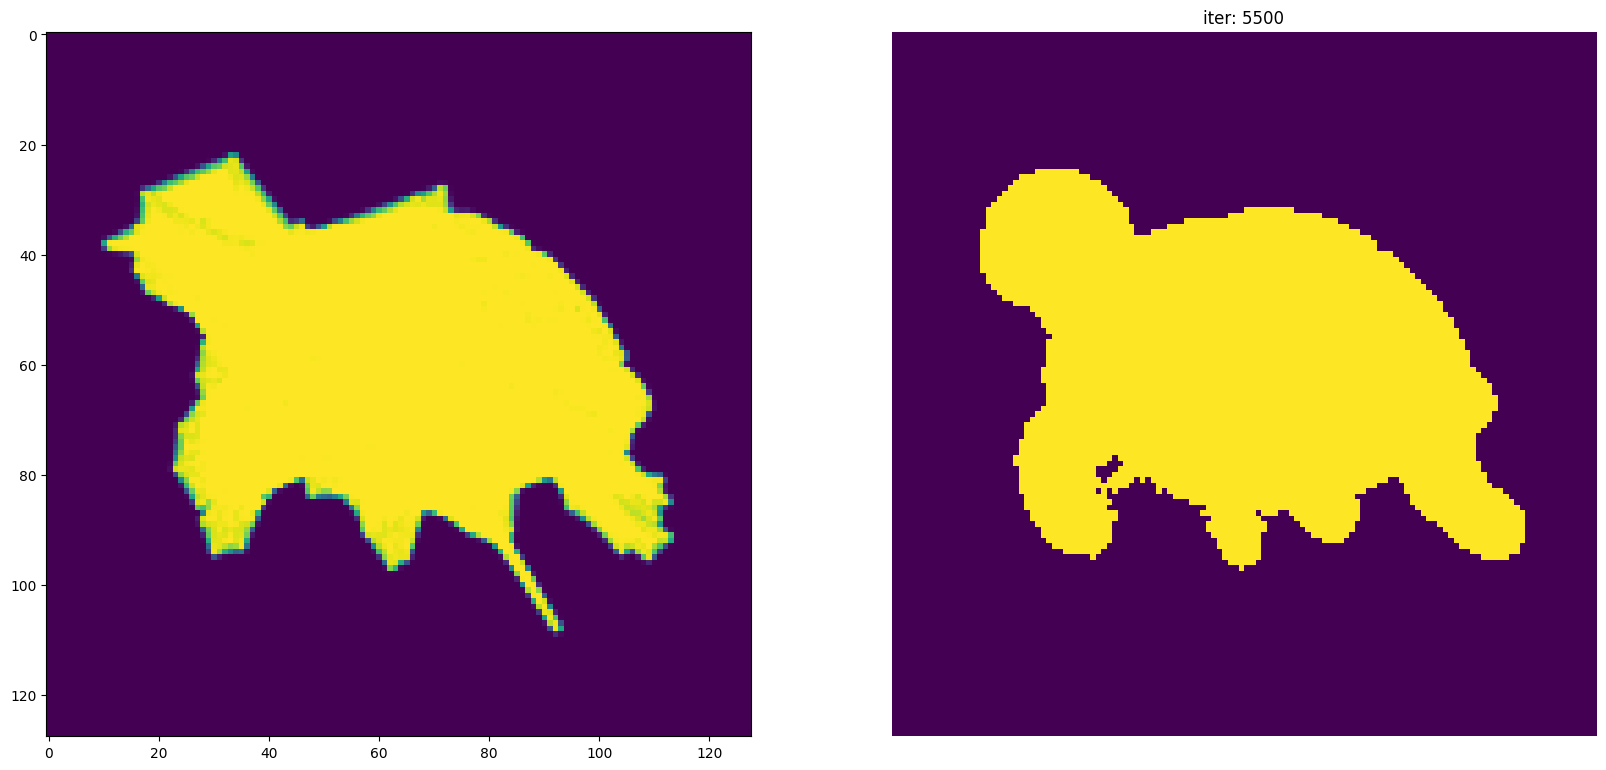

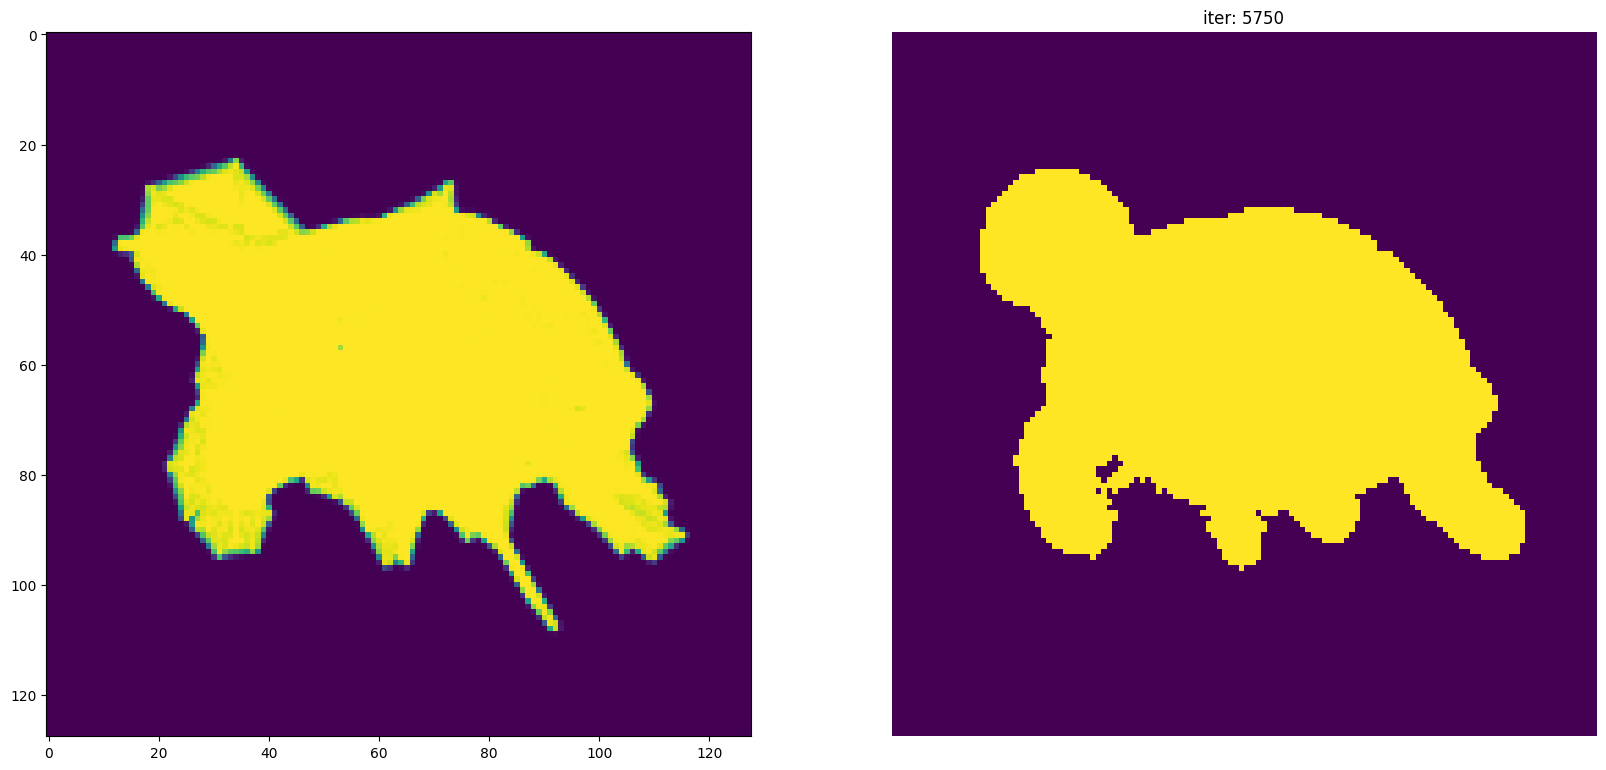

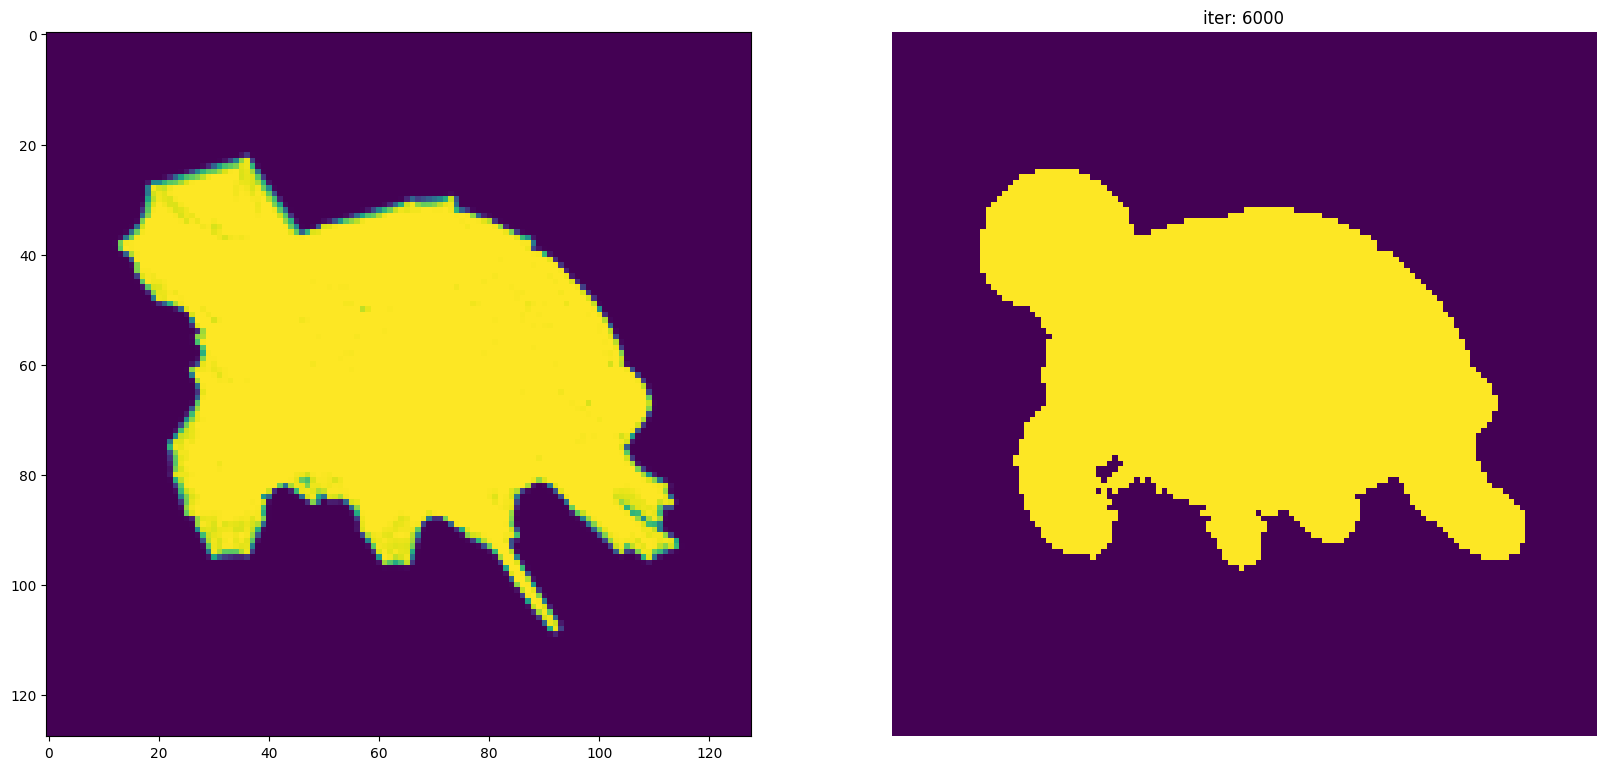

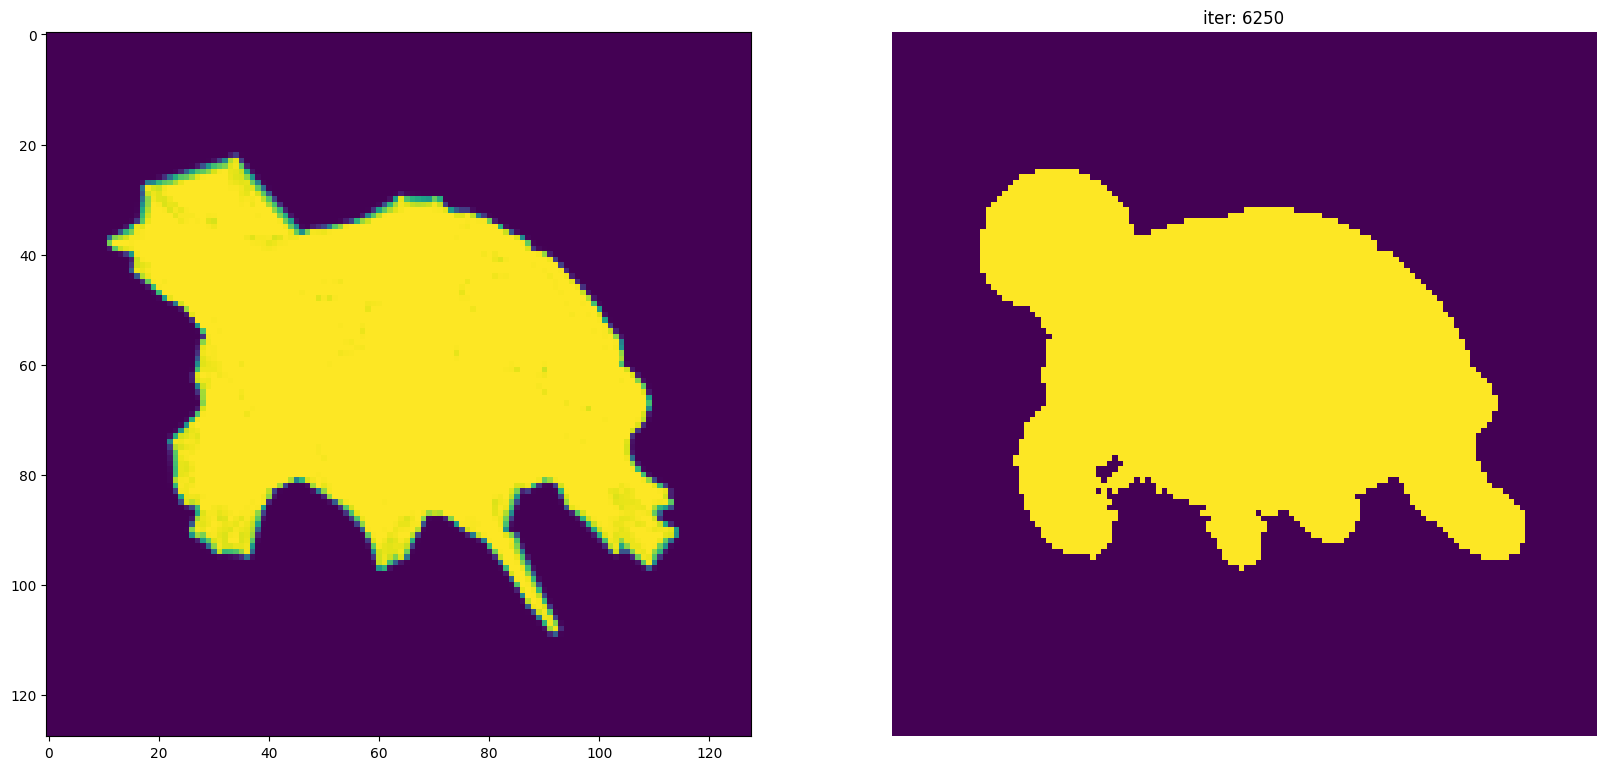

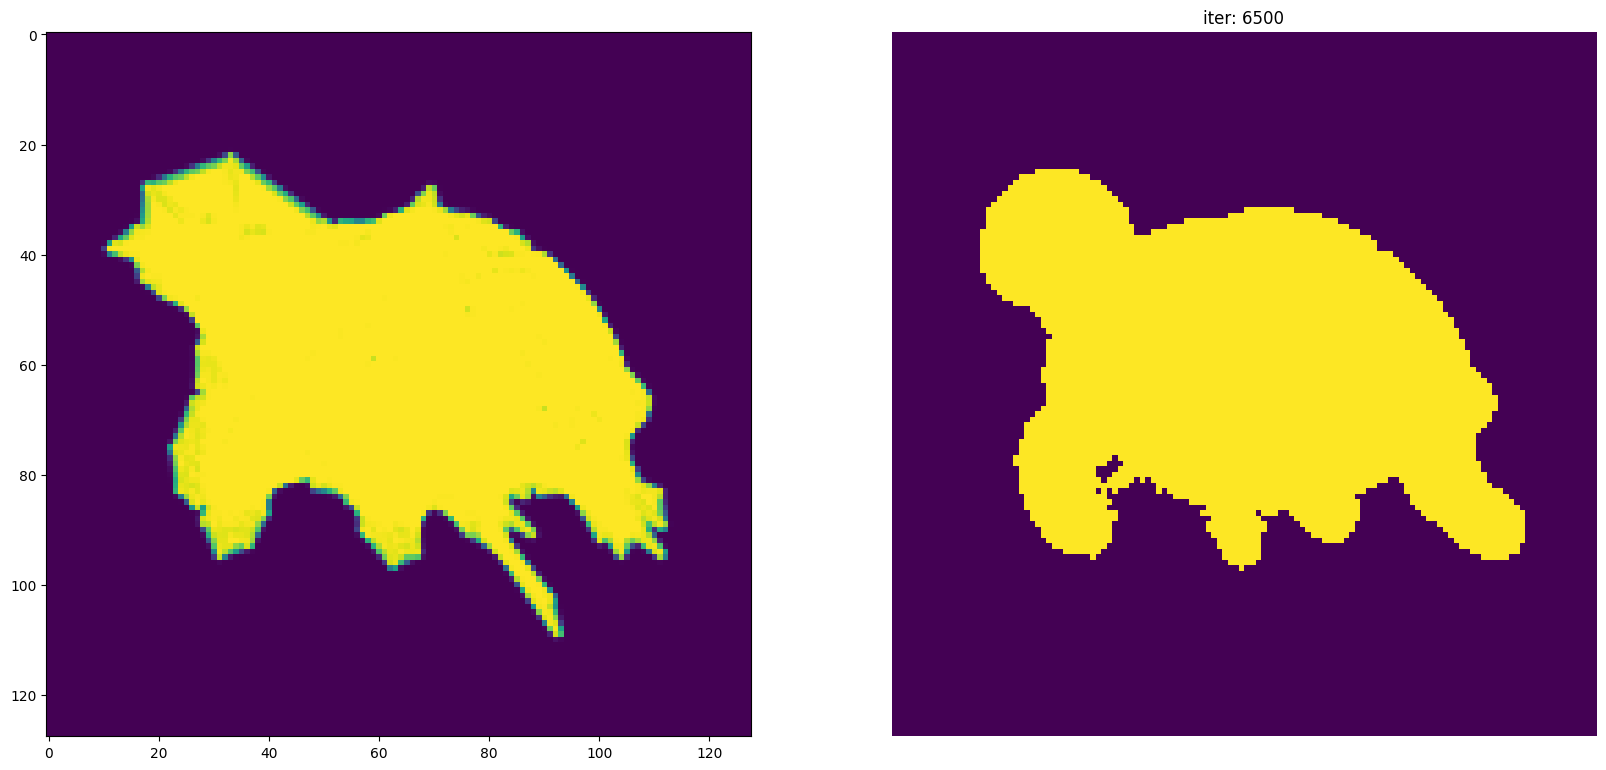

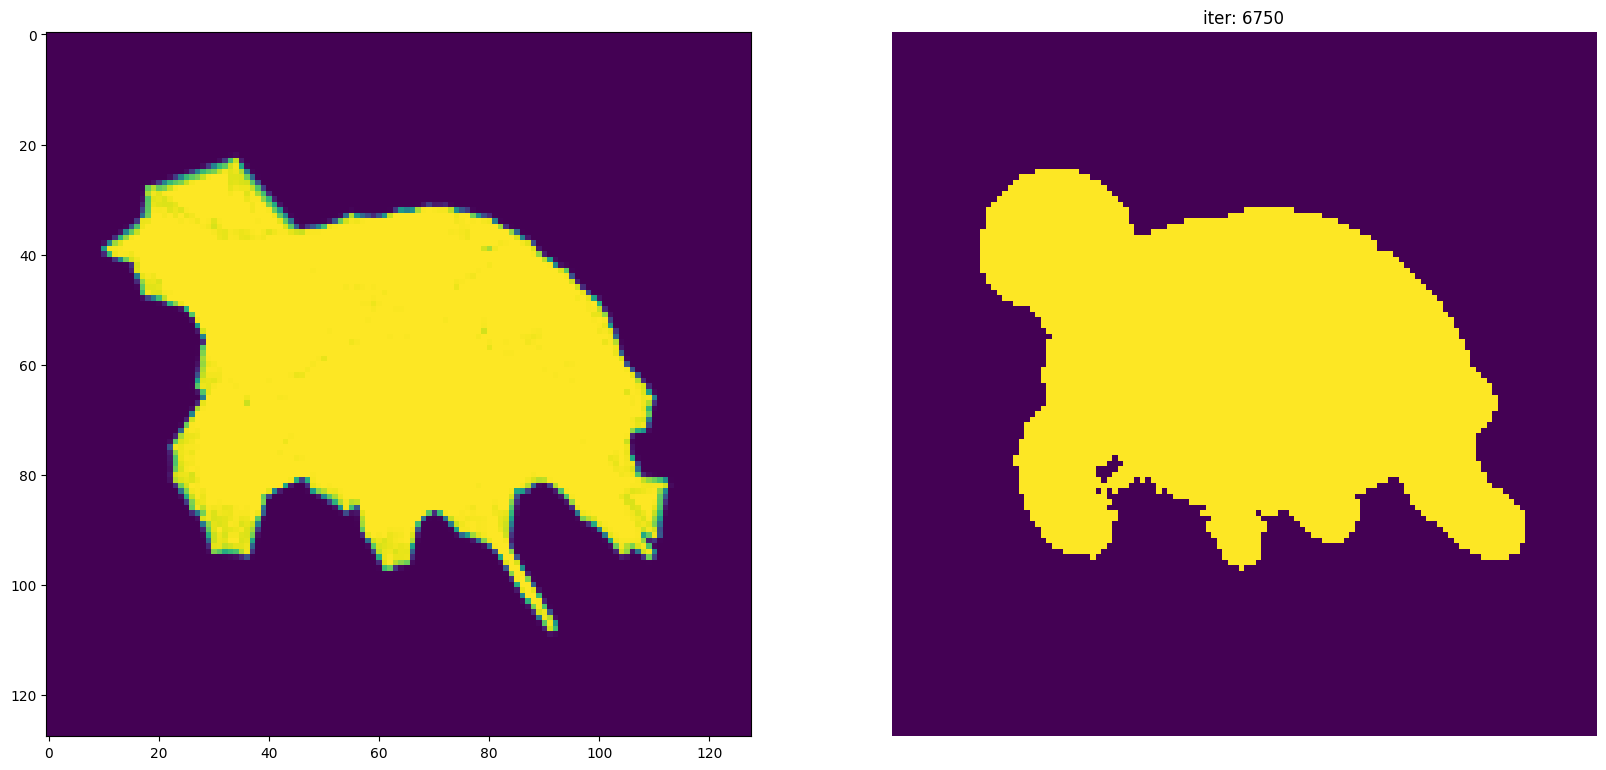

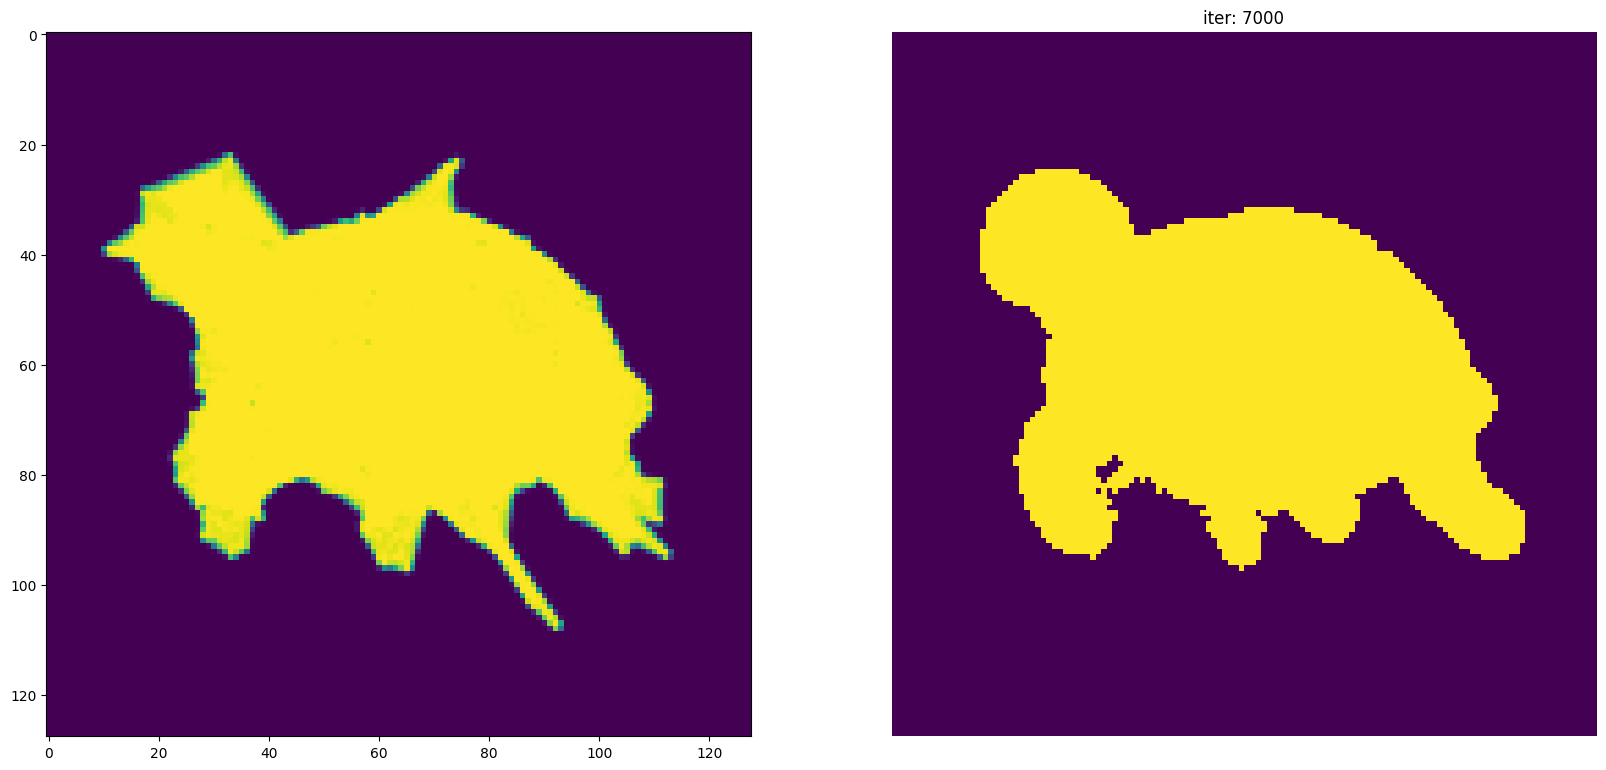

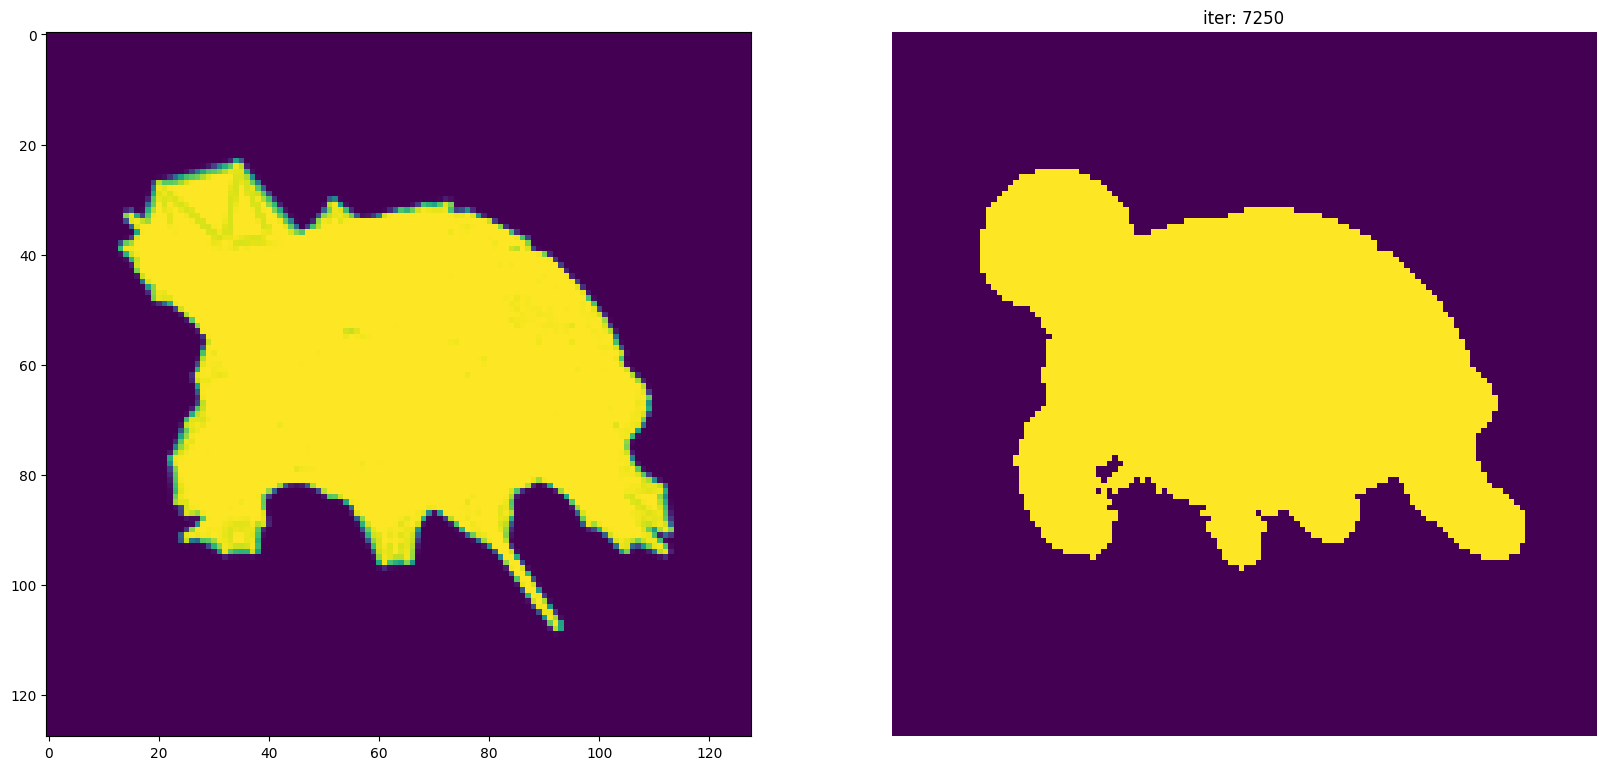

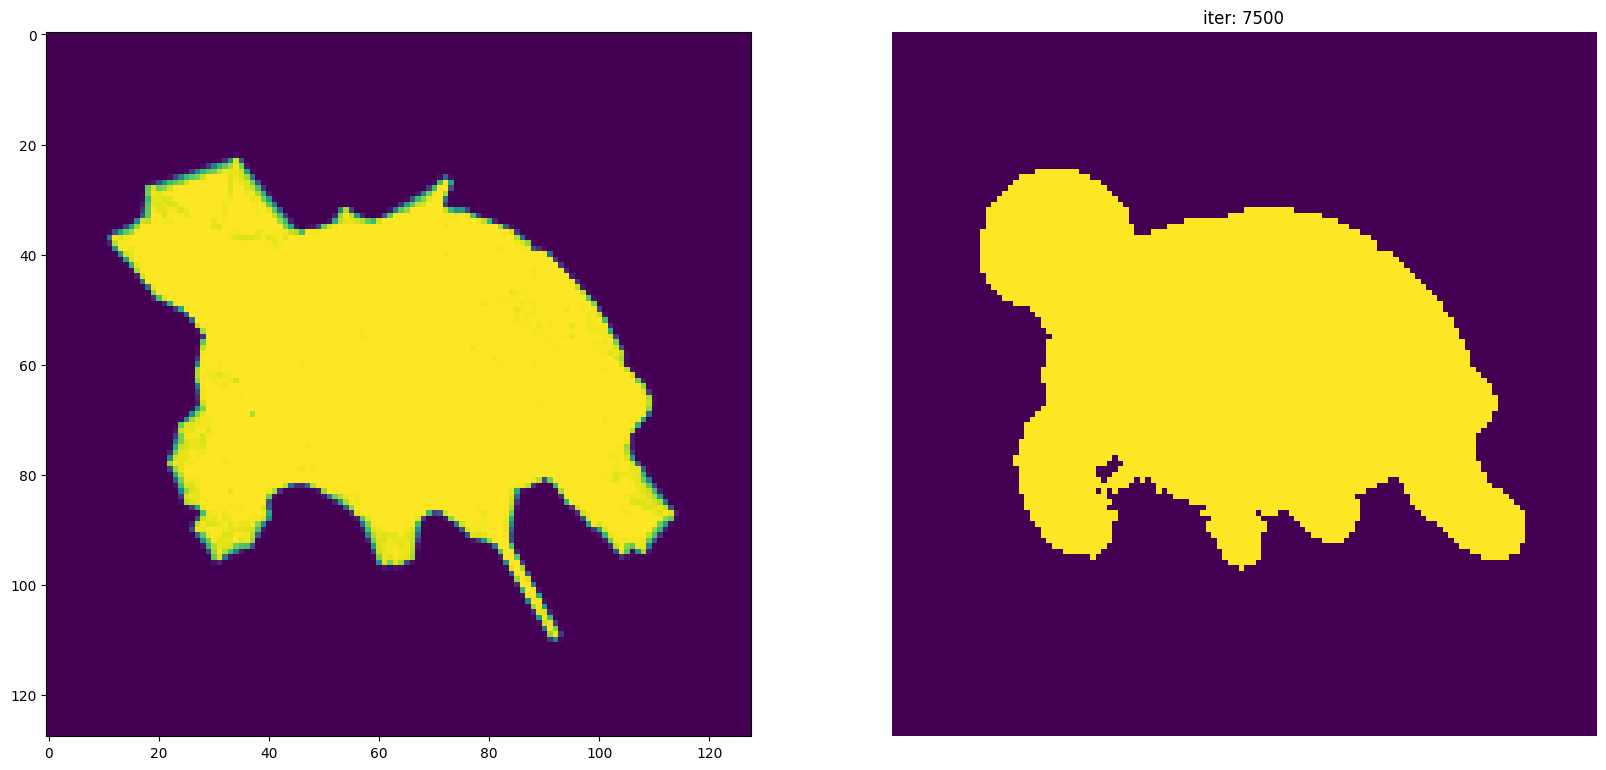

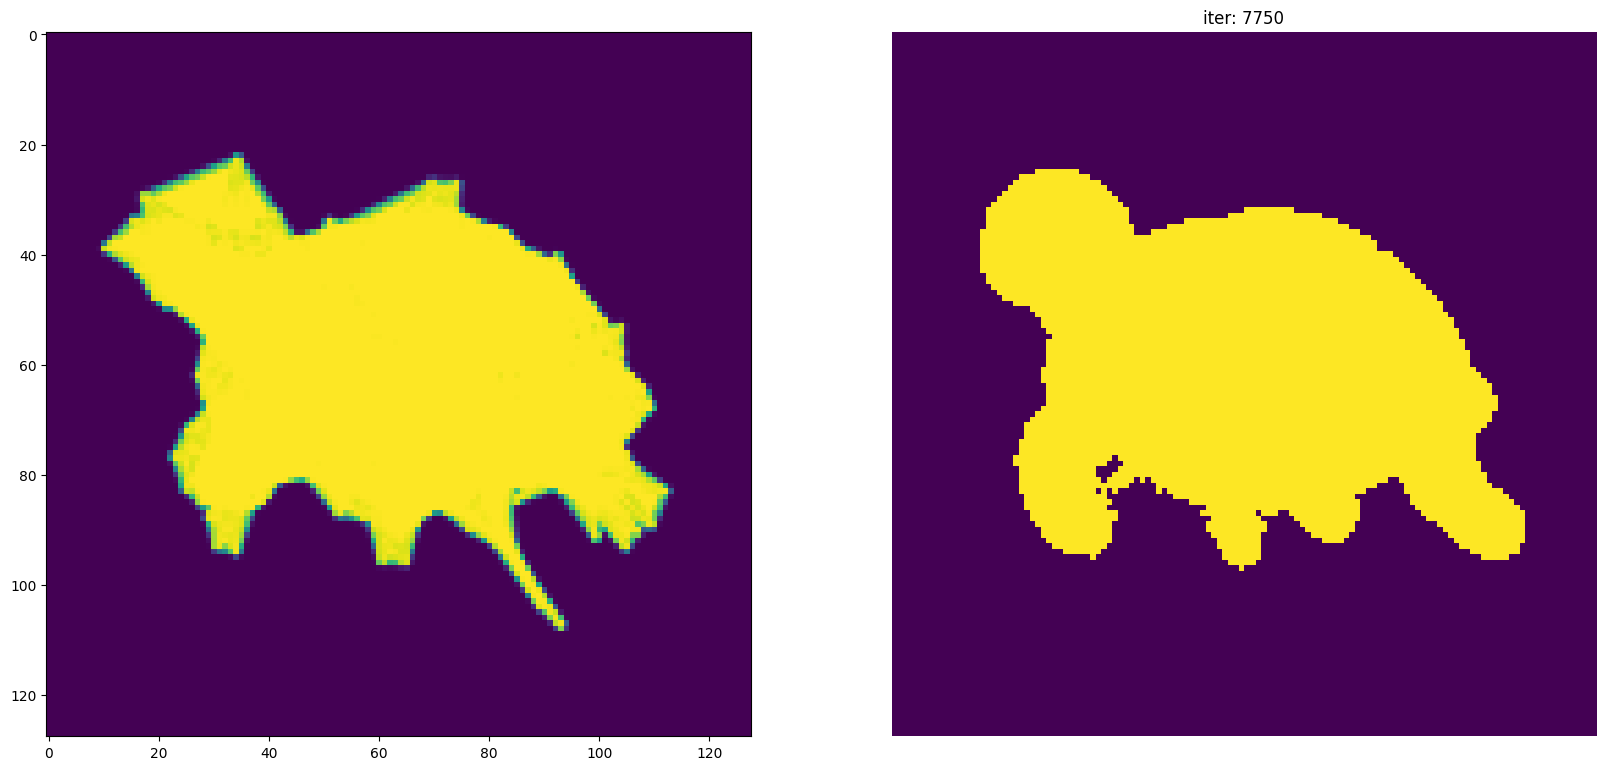

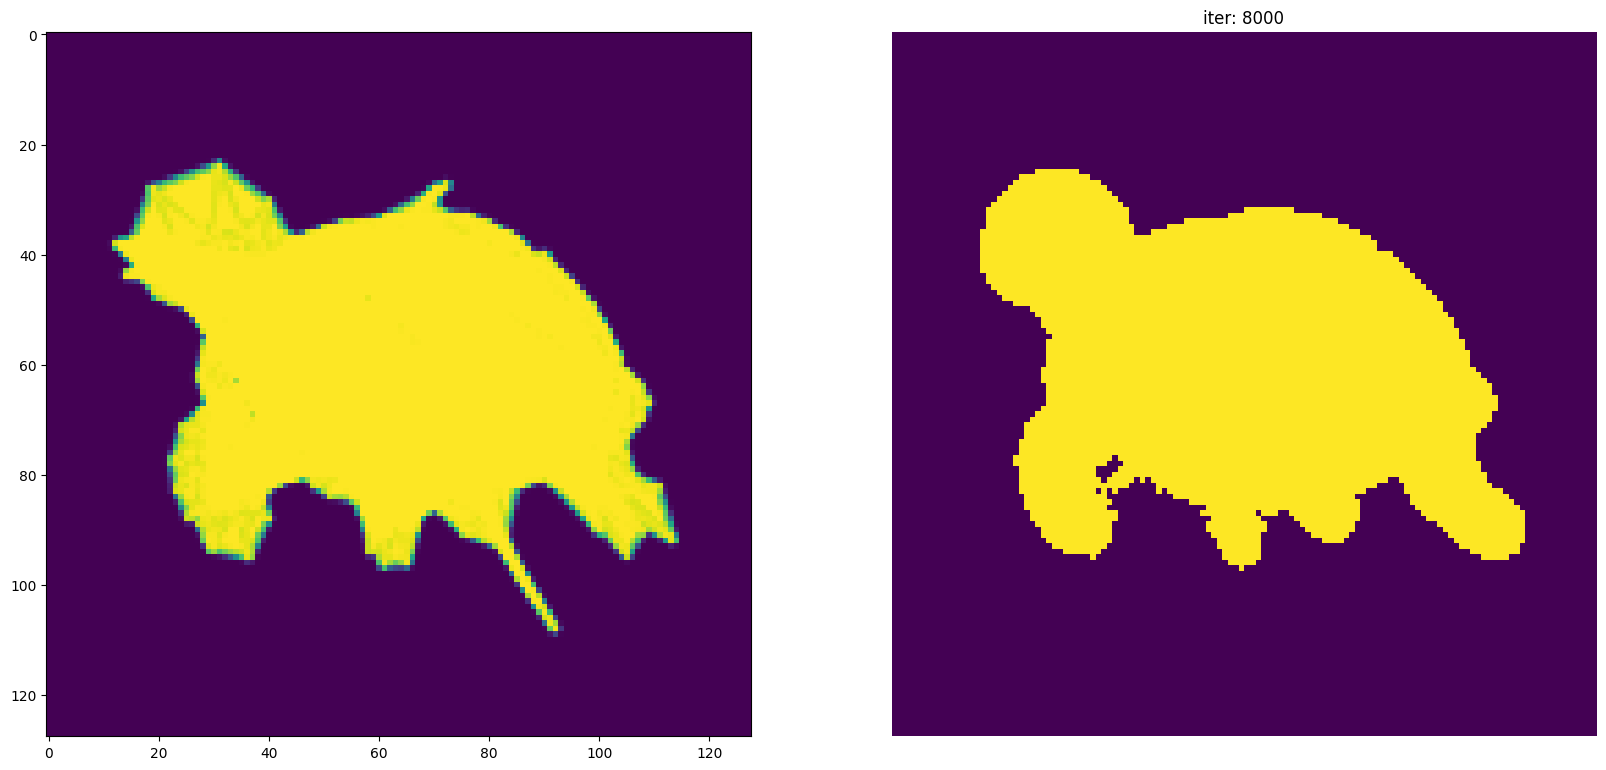

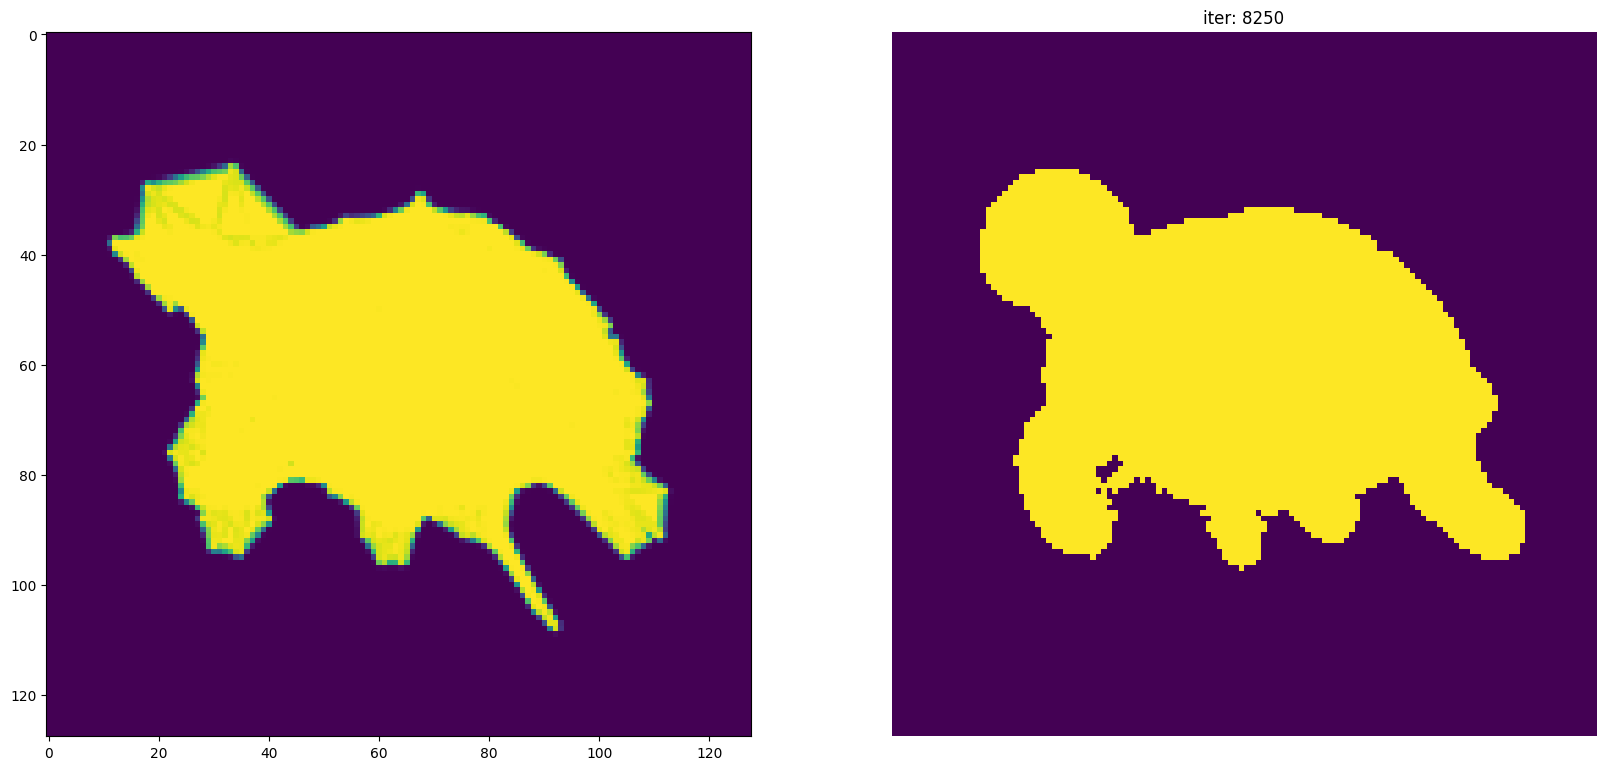

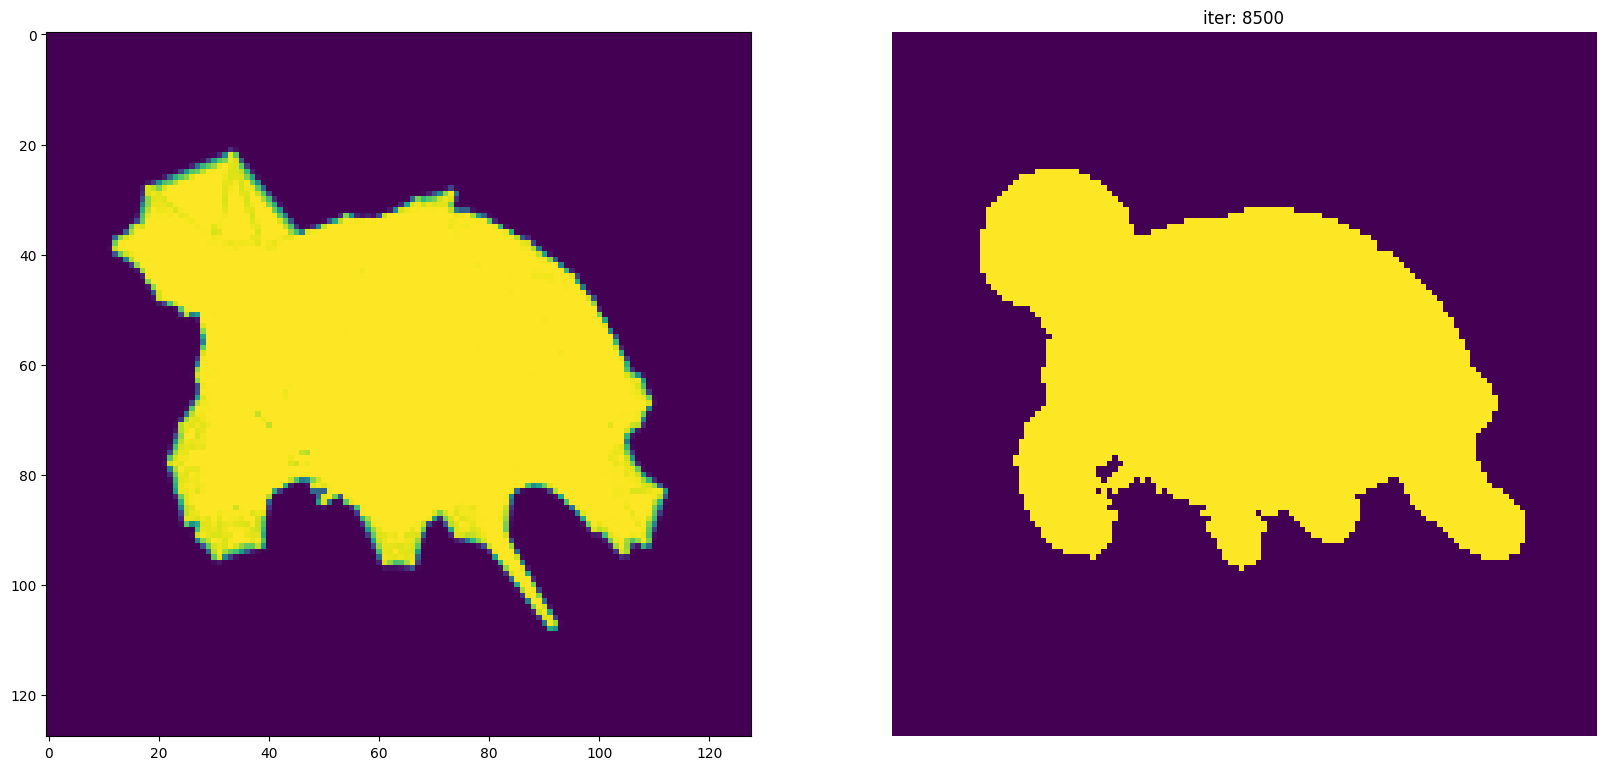

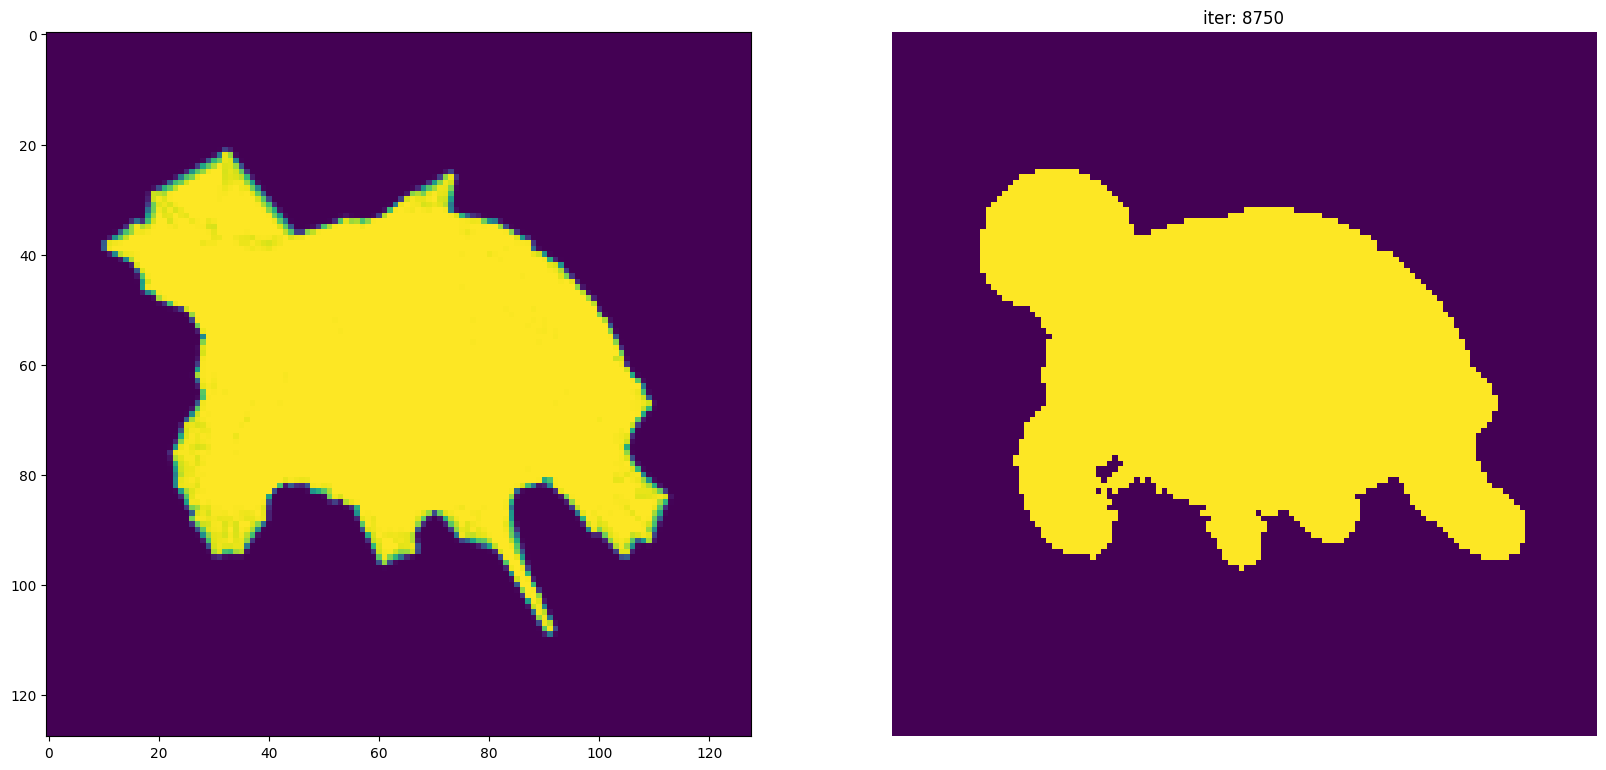

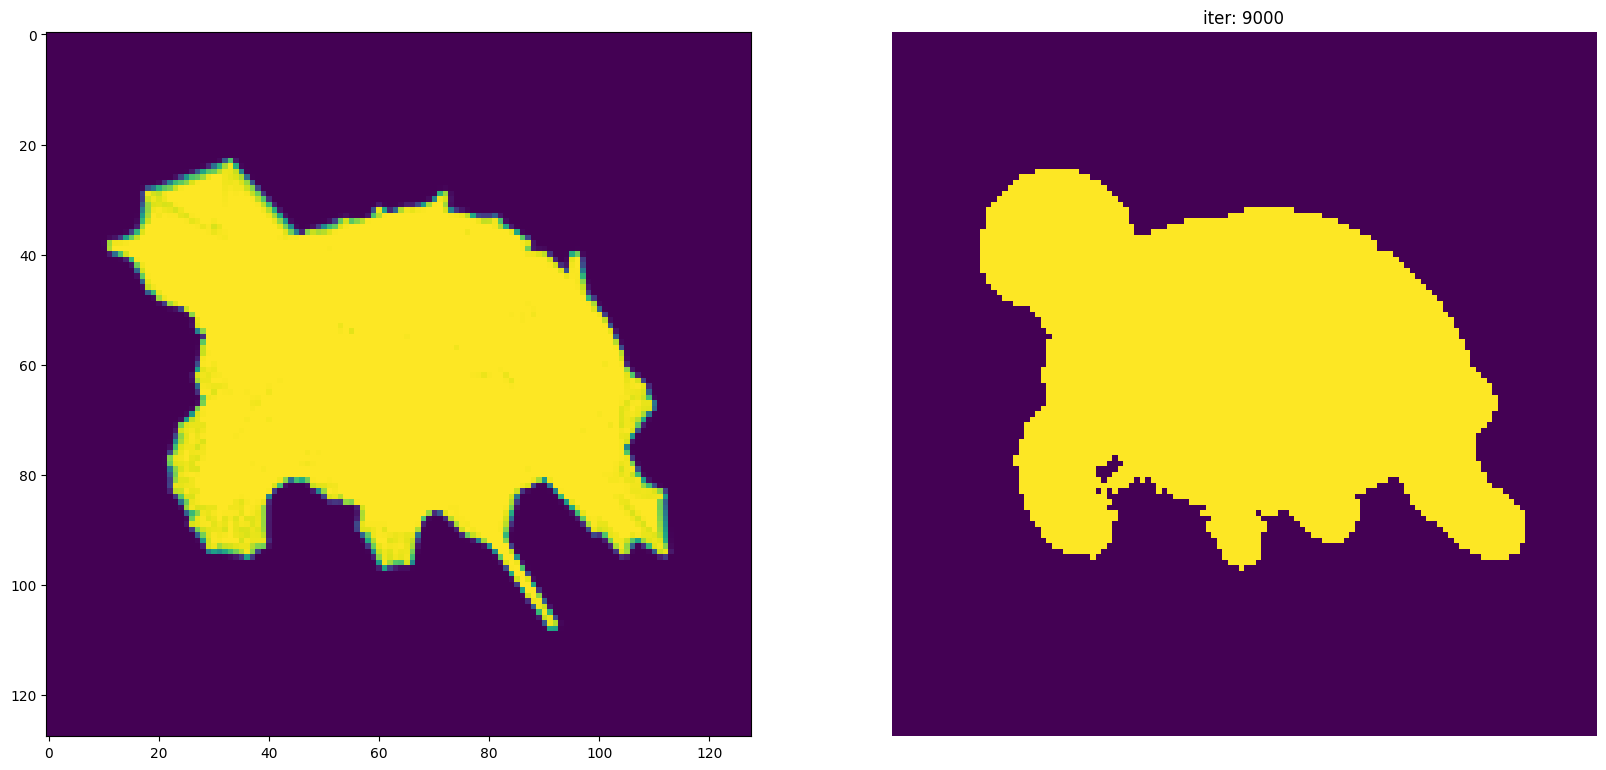

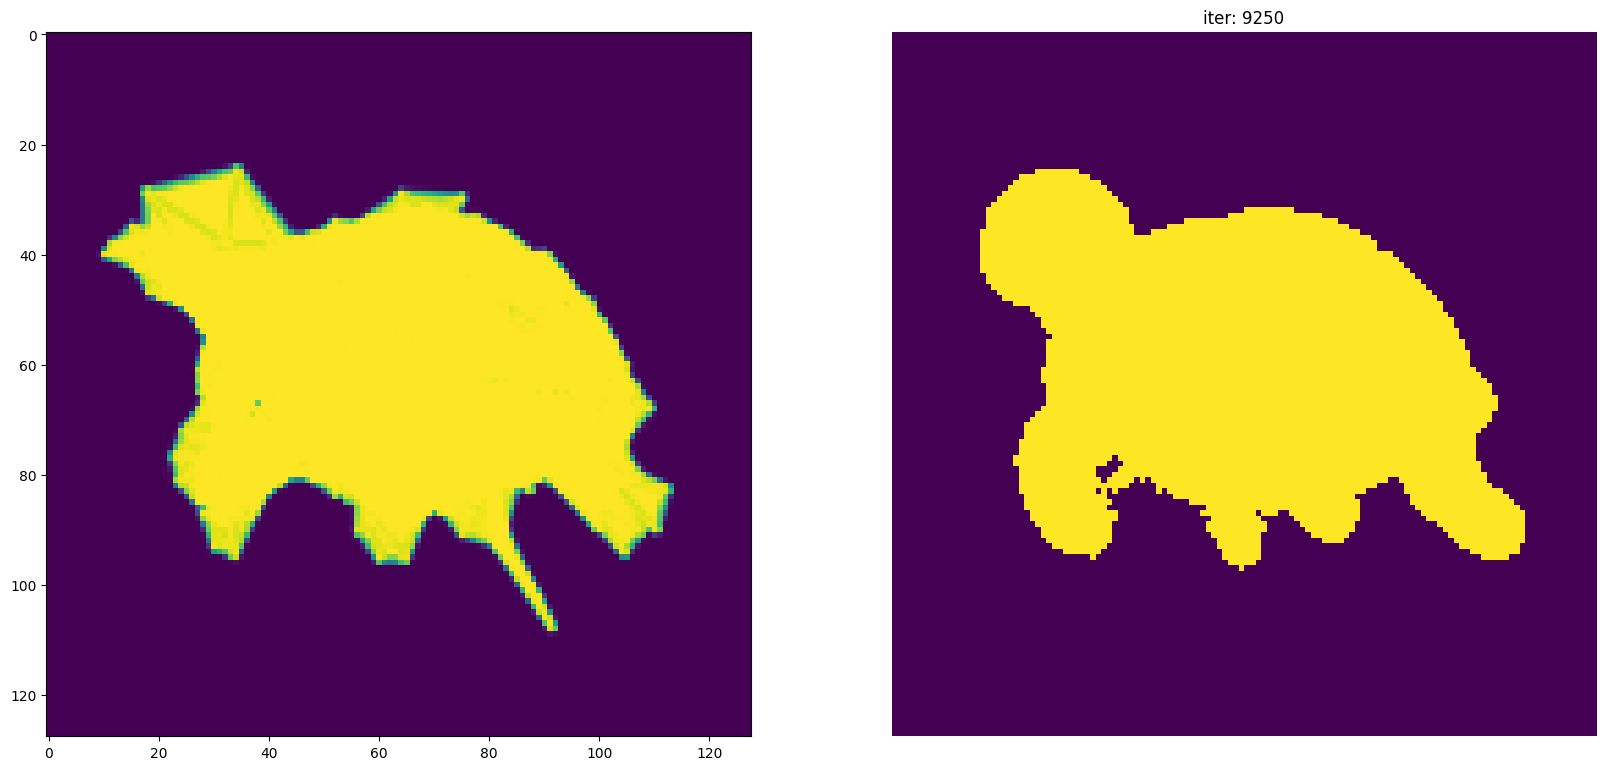

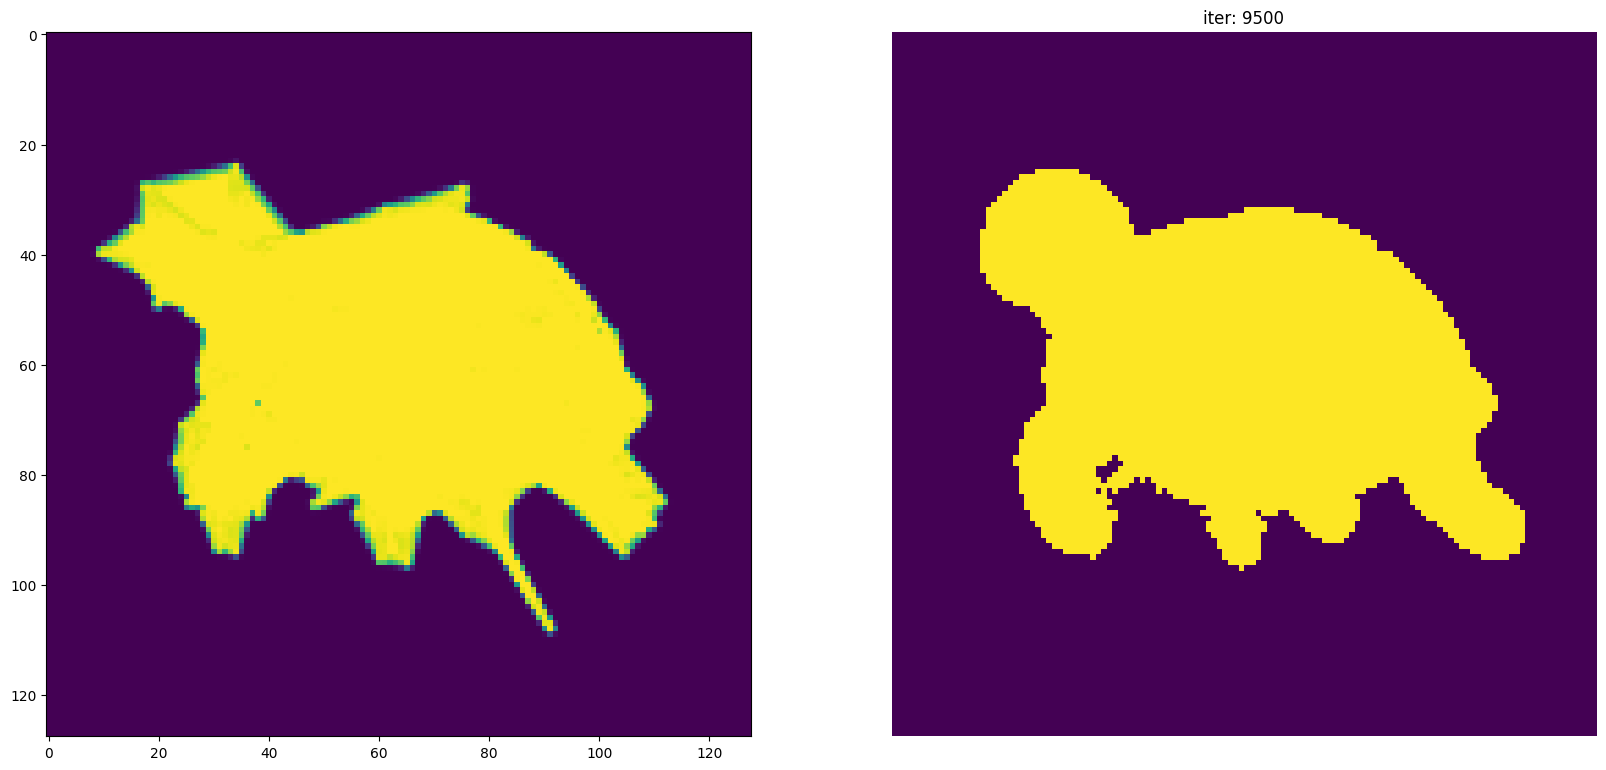

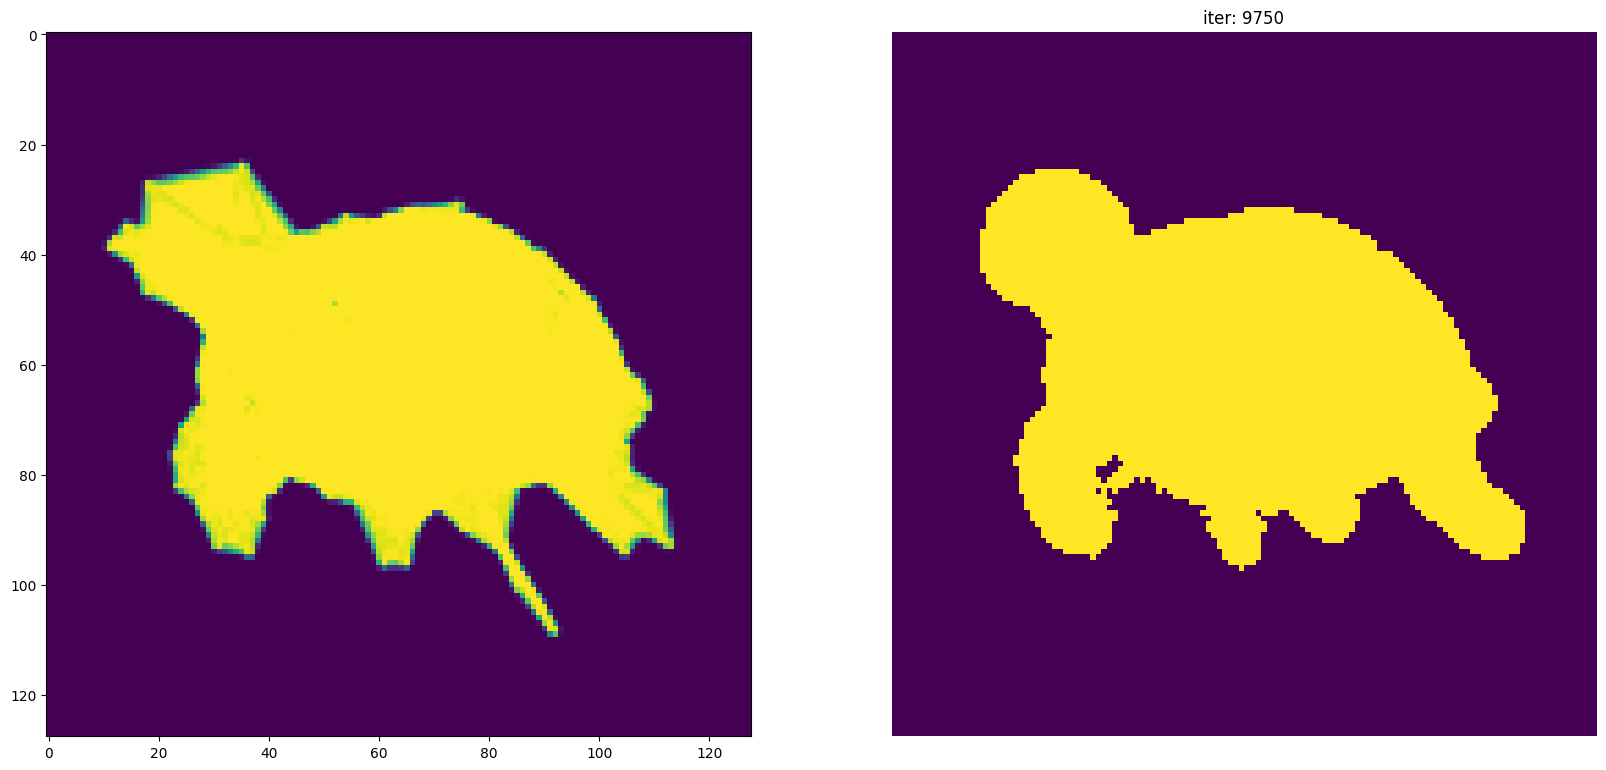

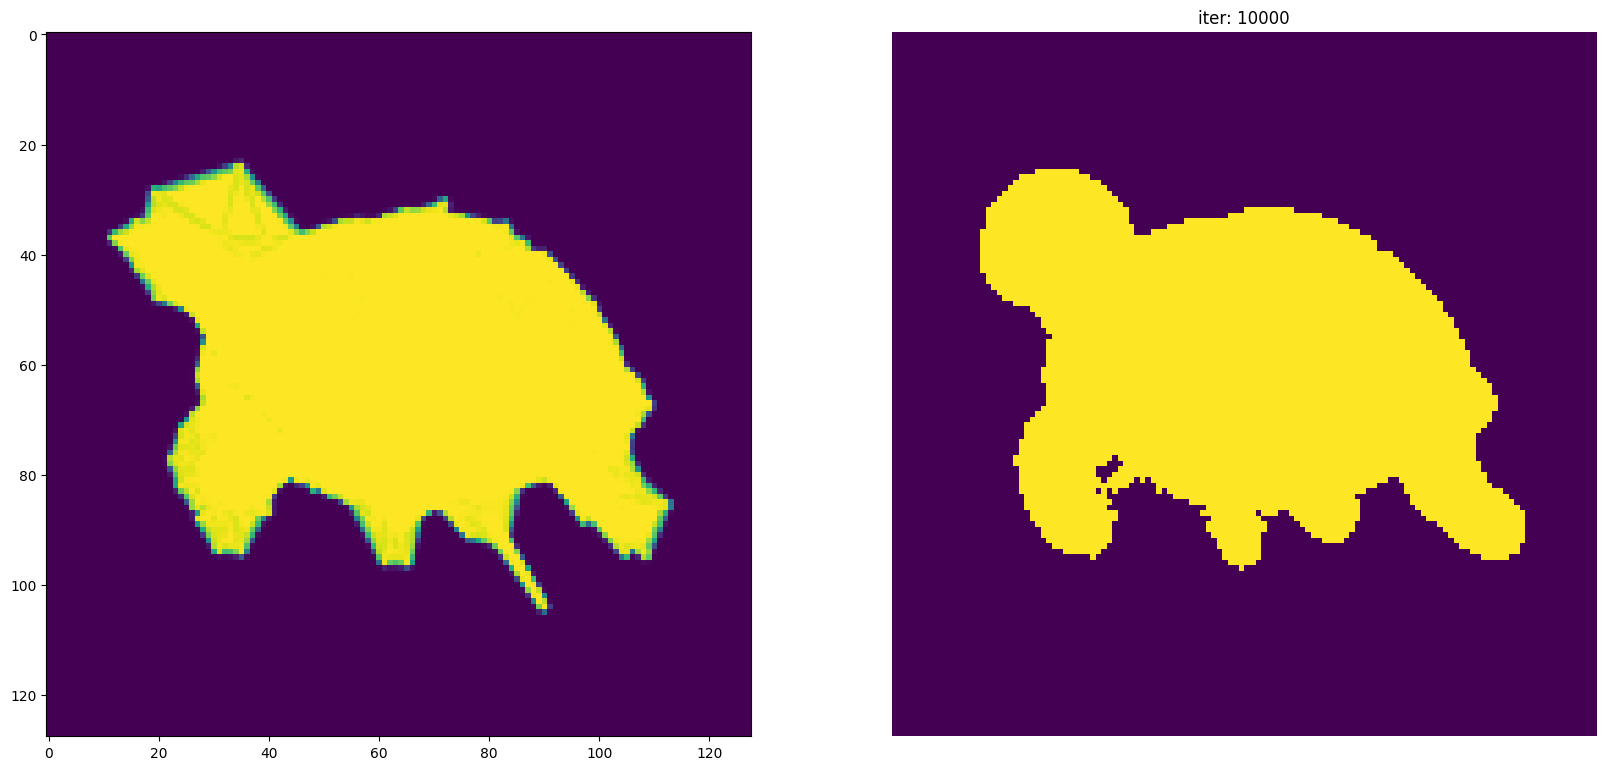

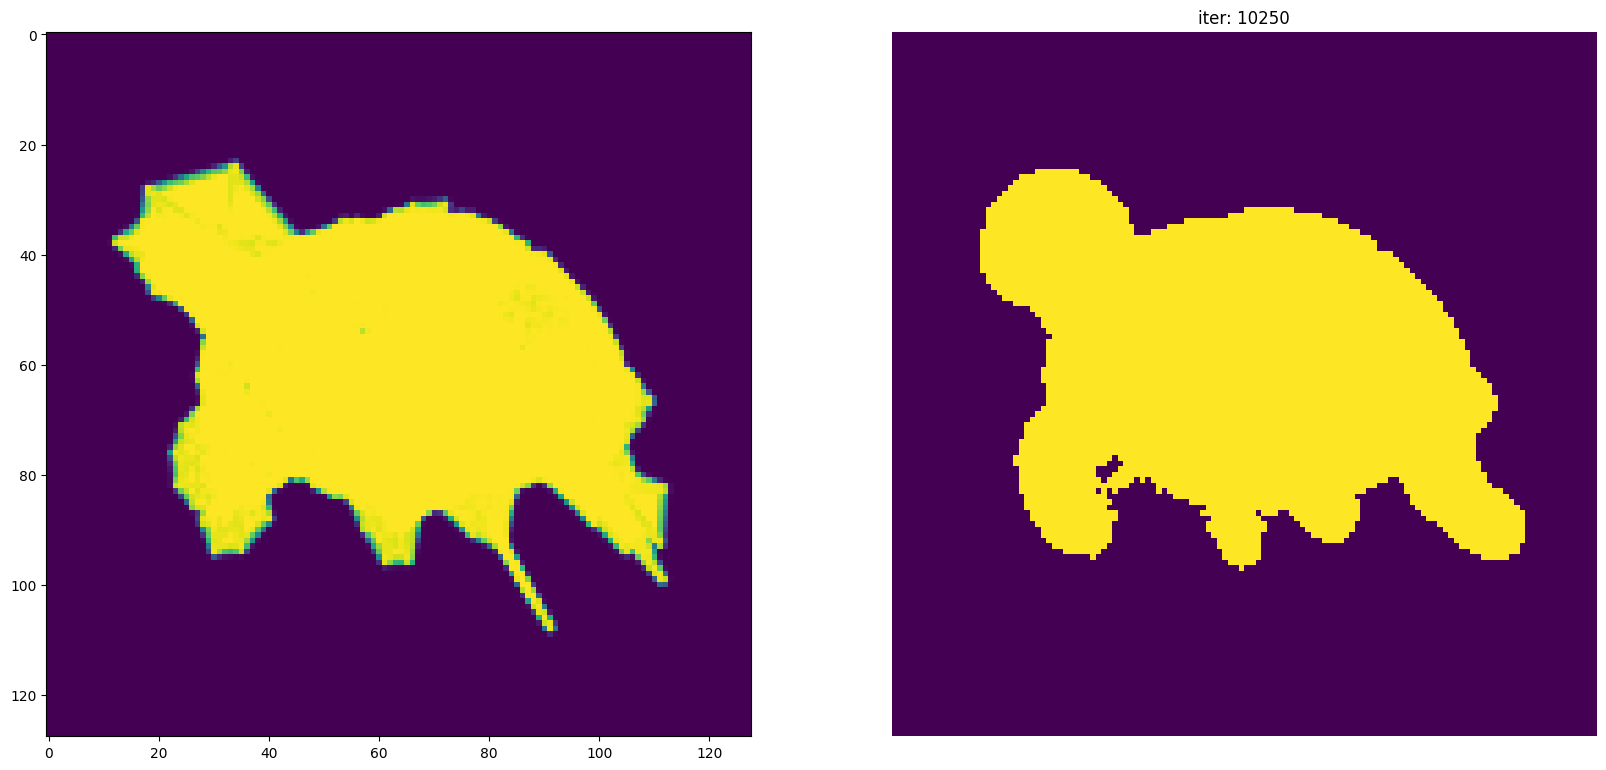

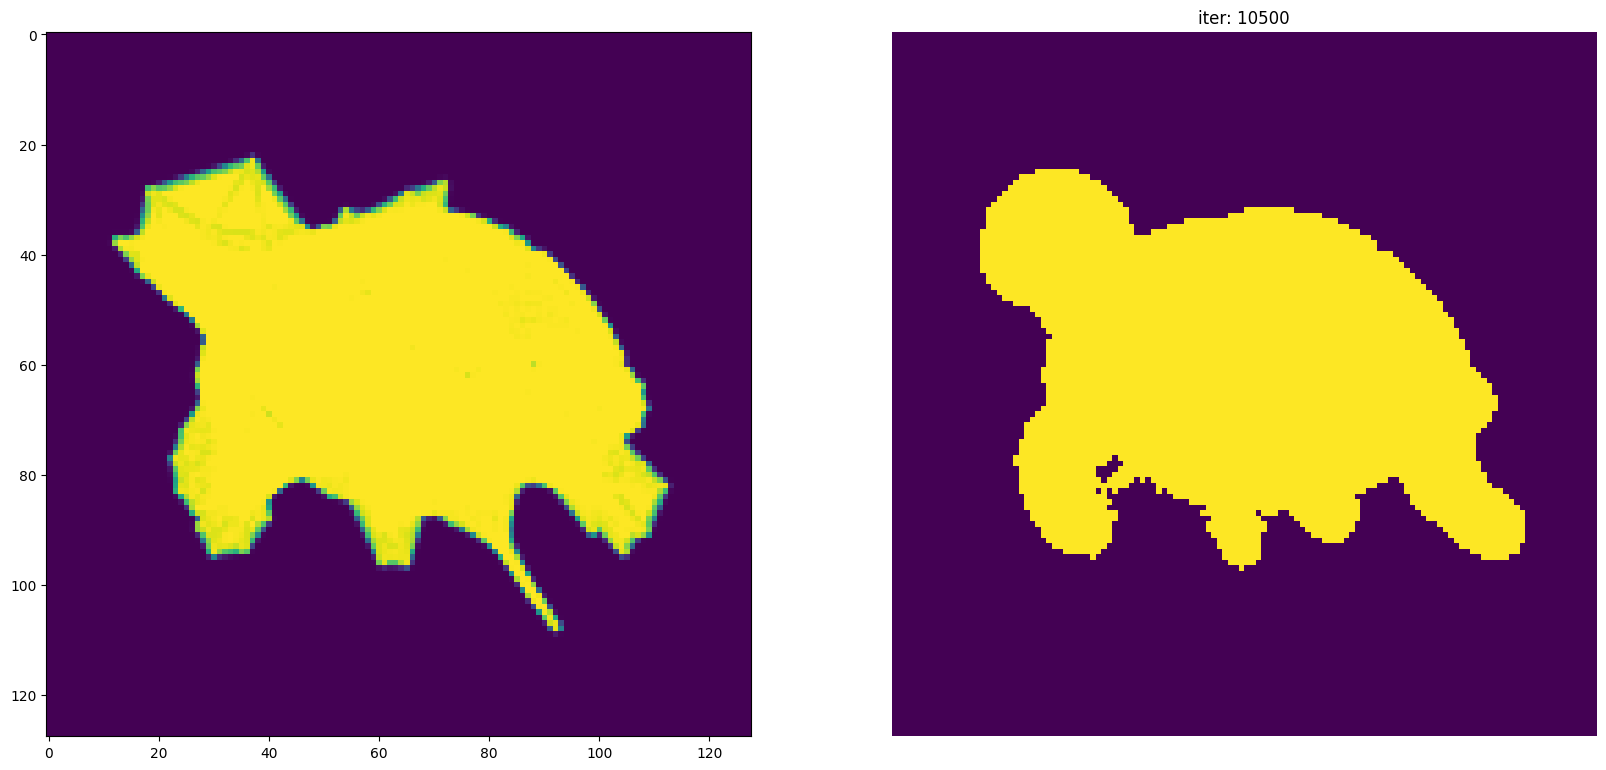

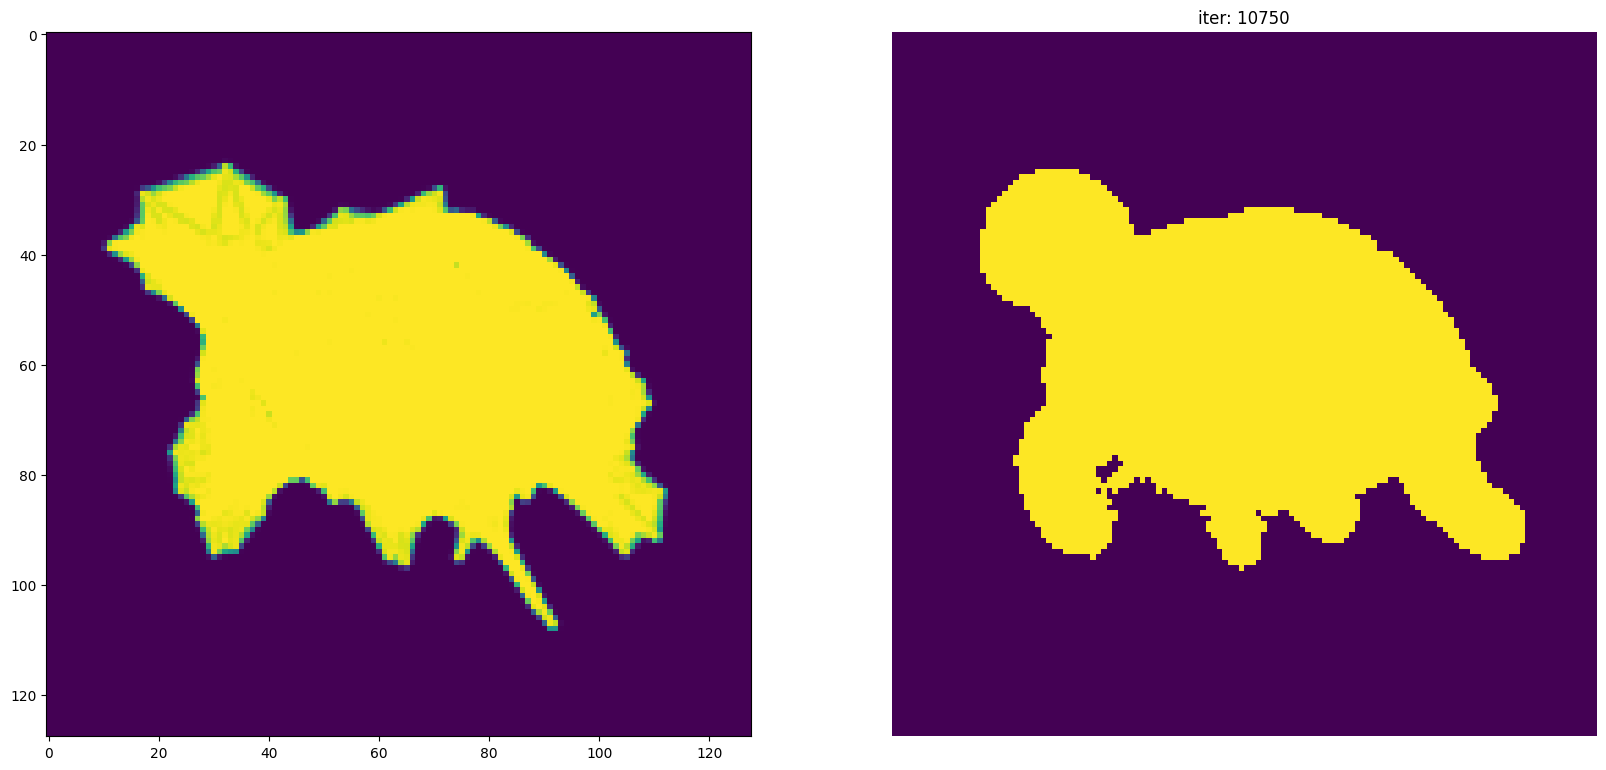

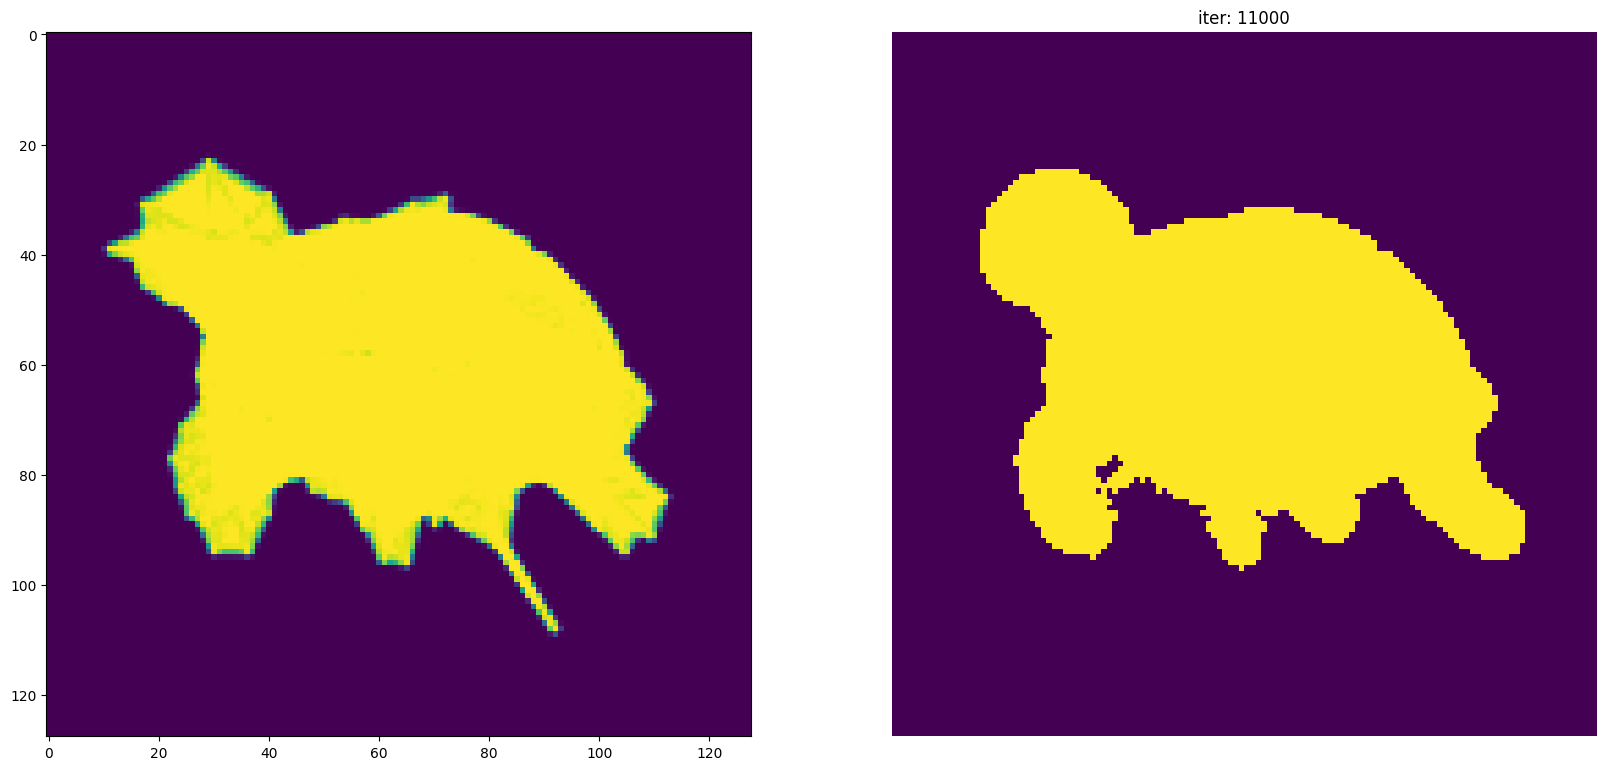

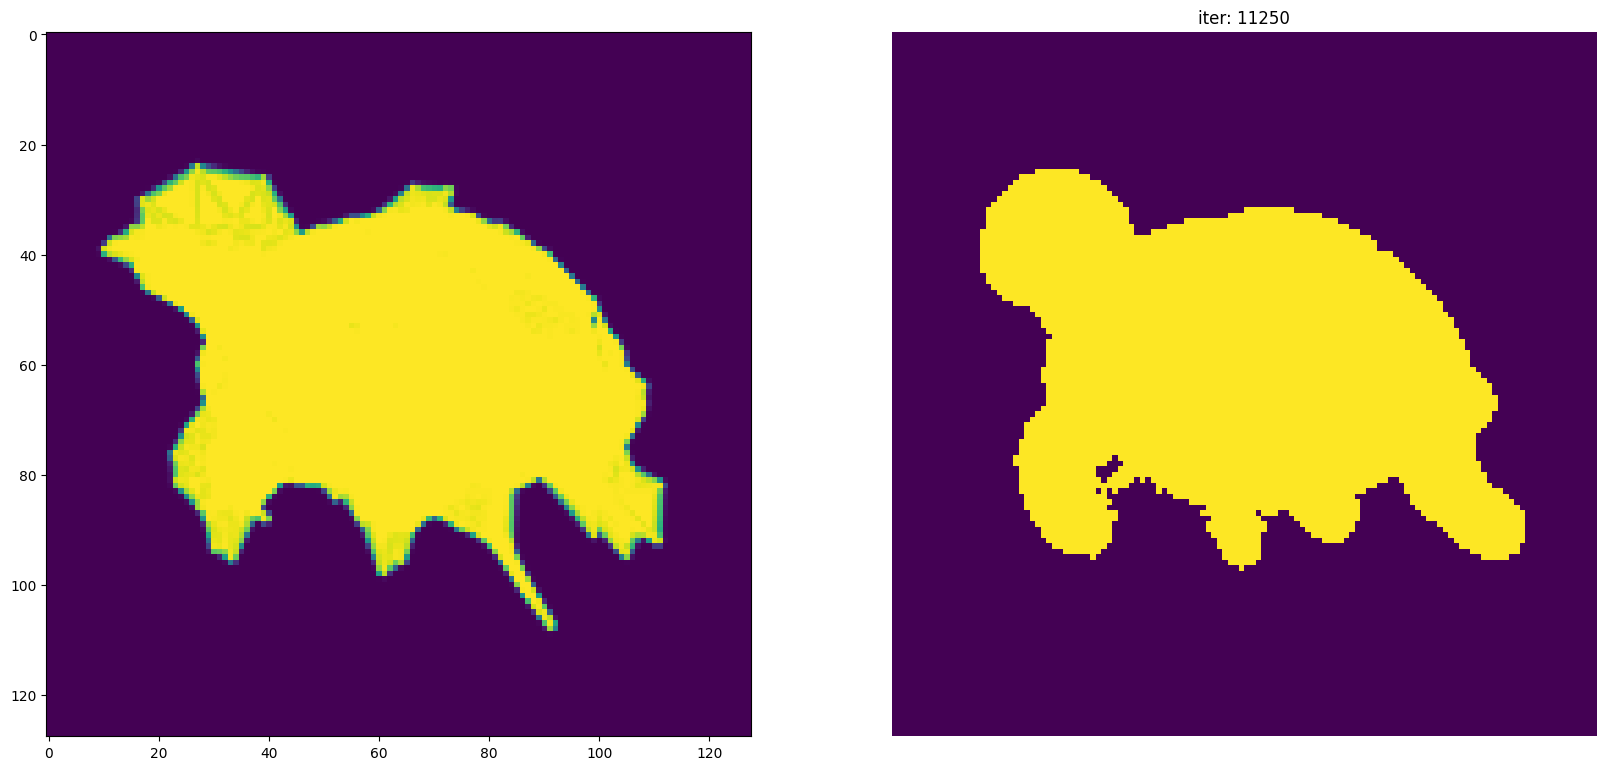

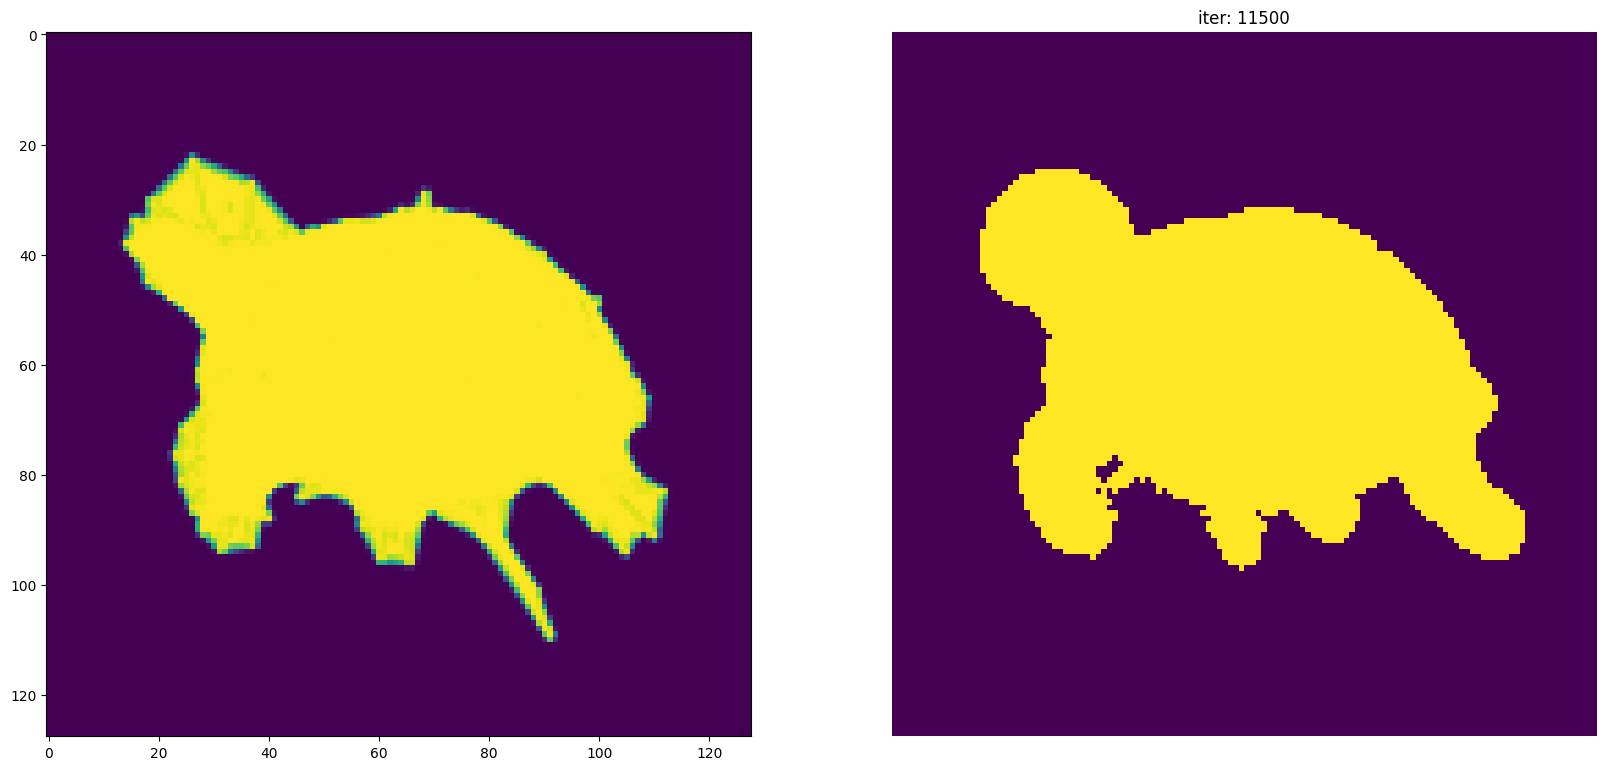

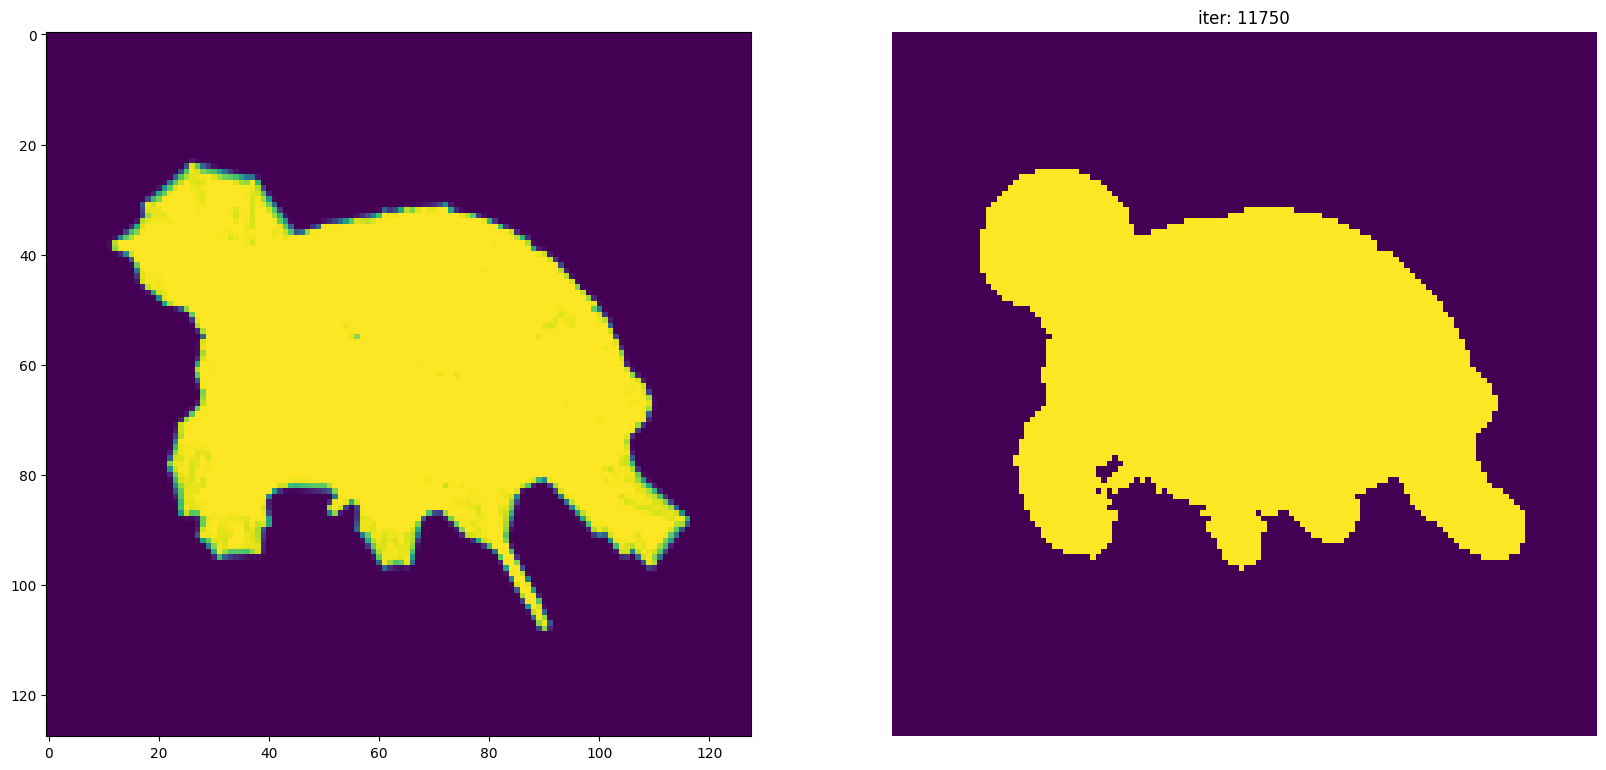

In [94]:
loop = tqdm(range(ITERATIONS))

for i in loop:
    # Initialize optimizer
    optimizer.zero_grad()

    # Deform the mesh
    new_src_mesh = src_mesh.offset_verts(deform_verts)

    # Losses to smooth /regularize the mesh shape
    loss = {k: torch.tensor(0.0, device=device) for k in losses}
    update_mesh_shape_prior_losses(new_src_mesh, loss)

    # Compute the average silhouette loss over two random views, as the average
    # squared L2 distance between the predicted silhouette and the target
    # silhouette from our dataset
    for j in np.random.permutation(N_VIEWS).tolist()[:num_views_per_iteration]:
        images_predicted = renderer_silhouette(new_src_mesh, cameras=target_cameras[j], lights=lights)
        predicted_silhouette = images_predicted[..., 3]
        loss_silhouette = ((predicted_silhouette - target_sil[j]) ** 2).mean()
        loss["silhouette"] += loss_silhouette / num_views_per_iteration

    # Weighted sum of the losses
    sum_loss = torch.tensor(0.0, device=device)
    for k, l in loss.items():
        sum_loss += l * losses[k]["weight"]
        losses[k]["values"].append(float(l.detach().cpu()))


    # Print the losses
    loop.set_description("total_loss = %.6f" % sum_loss)

    # Plot mesh
    if i % plot_period == 0:
        visualize_prediction(new_src_mesh, title="iter: %d" % i, silhouette=True,
                             target_image=target_sil[1])

    # Optimization step
    sum_loss.backward()
    optimizer.step()
    # scheduler.step()

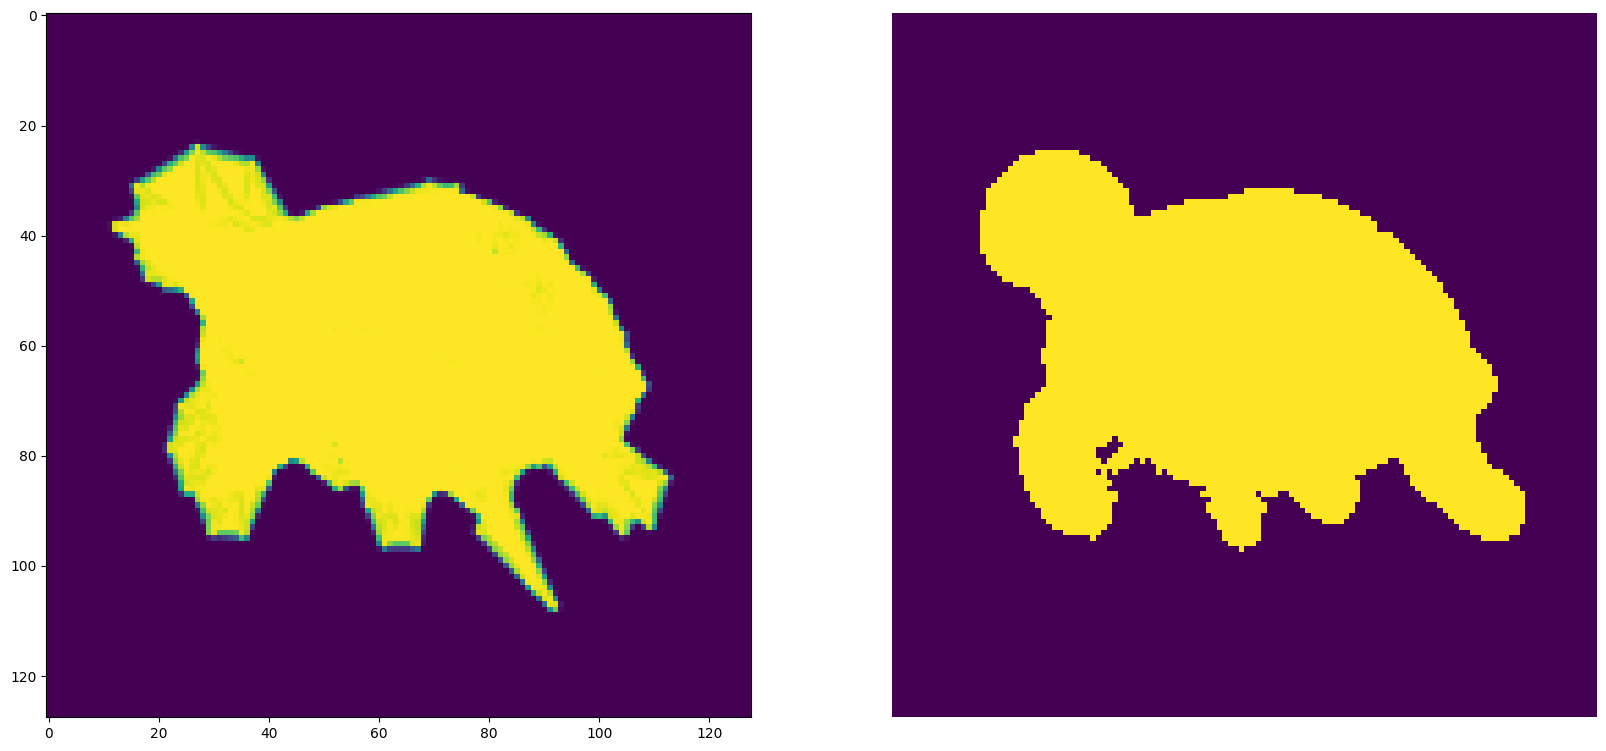

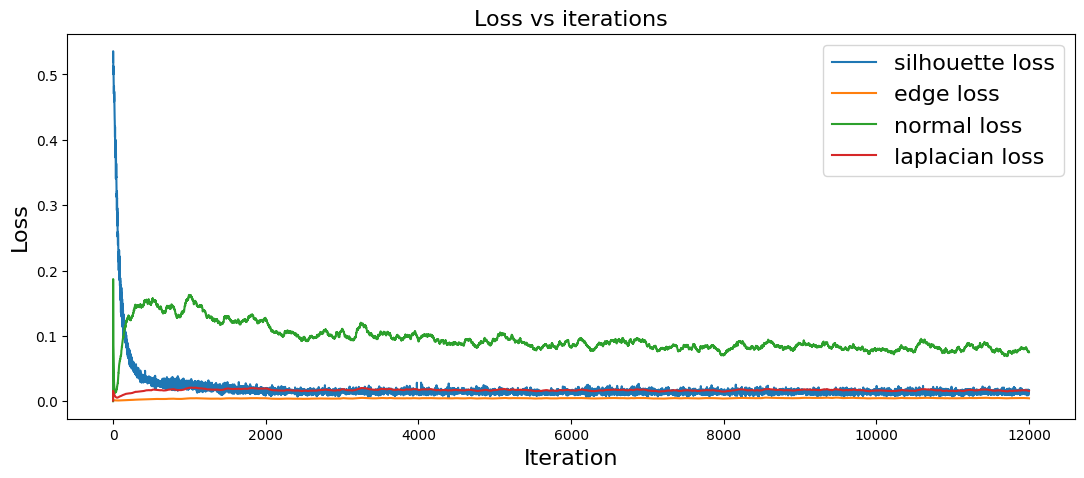

In [95]:
visualize_prediction(new_src_mesh, silhouette=True,
                     target_image=target_sil[1])
plot_losses(losses)

In [96]:
# Rasterization settings for differentiable rendering, where the blur_radius
# initialization is based on Liu et al, 'Soft Rasterizer: A Differentiable
# Renderer for Image-based 3D Reasoning', ICCV 2019
sigma = 1e-4
raster_settings_soft = RasterizationSettings(
    image_size=IMAGE_SIZE,
    blur_radius=np.log(1. / 1e-4 - 1.)*sigma,
    faces_per_pixel=50,
    perspective_correct=False,
)

# Differentiable soft renderer using per vertex RGB colors for texture
renderer_textured = MeshRenderer(
    rasterizer=MeshRasterizer(
        cameras=camera,
        raster_settings=raster_settings_soft
    ),
    shader=SoftPhongShader(device=device,
        cameras=camera,
        lights=lights)
)

In [97]:
# Number of views to optimize over in each SGD iteration
num_views_per_iteration = 2
# Plot period for the losses
plot_period = 250

%matplotlib inline

# Optimize using rendered RGB image loss, rendered silhouette image loss, mesh
# edge loss, mesh normal consistency, and mesh laplacian smoothing
losses = {"rgb": {"weight": 1.0, "values": []},
          "silhouette": {"weight": 1.0, "values": []},
          "edge": {"weight": 1.0, "values": []},
          "normal": {"weight": 0.5, "values": []},
          "laplacian": {"weight": 1.0, "values": []},
         }

# We will learn to deform the source mesh by offsetting its vertices
# The shape of the deform parameters is equal to the total number of vertices in
# src_mesh
verts_shape = src_mesh.verts_packed().shape
# deform_verts = torch.full(verts_shape, 0.0, device=device, requires_grad=True)

# We will also learn per vertex colors for our sphere mesh that define texture
# of the mesh
sphere_verts_rgb = torch.full([1, verts_shape[0], 3], 0.5, device=device, requires_grad=True)

# The optimizer
# optimizer = torch.optim.SGD([deform_verts, sphere_verts_rgb], lr=1.0, momentum=0.9)
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=500, gamma=0.5)

In [106]:
optimizer = torch.optim.Adam([deform_verts, sphere_verts_rgb], lr=0.0005)
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)

In [107]:
ITERATIONS = 8000

total_loss = 0.113675:  62%|██████▎   | 5000/8000 [04:22<02:36, 19.19it/s]/tmp/ipython-input-2628694592.py:9: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(20, 10))
total_loss = 0.115523: 100%|██████████| 8000/8000 [07:00<00:00, 19.01it/s]


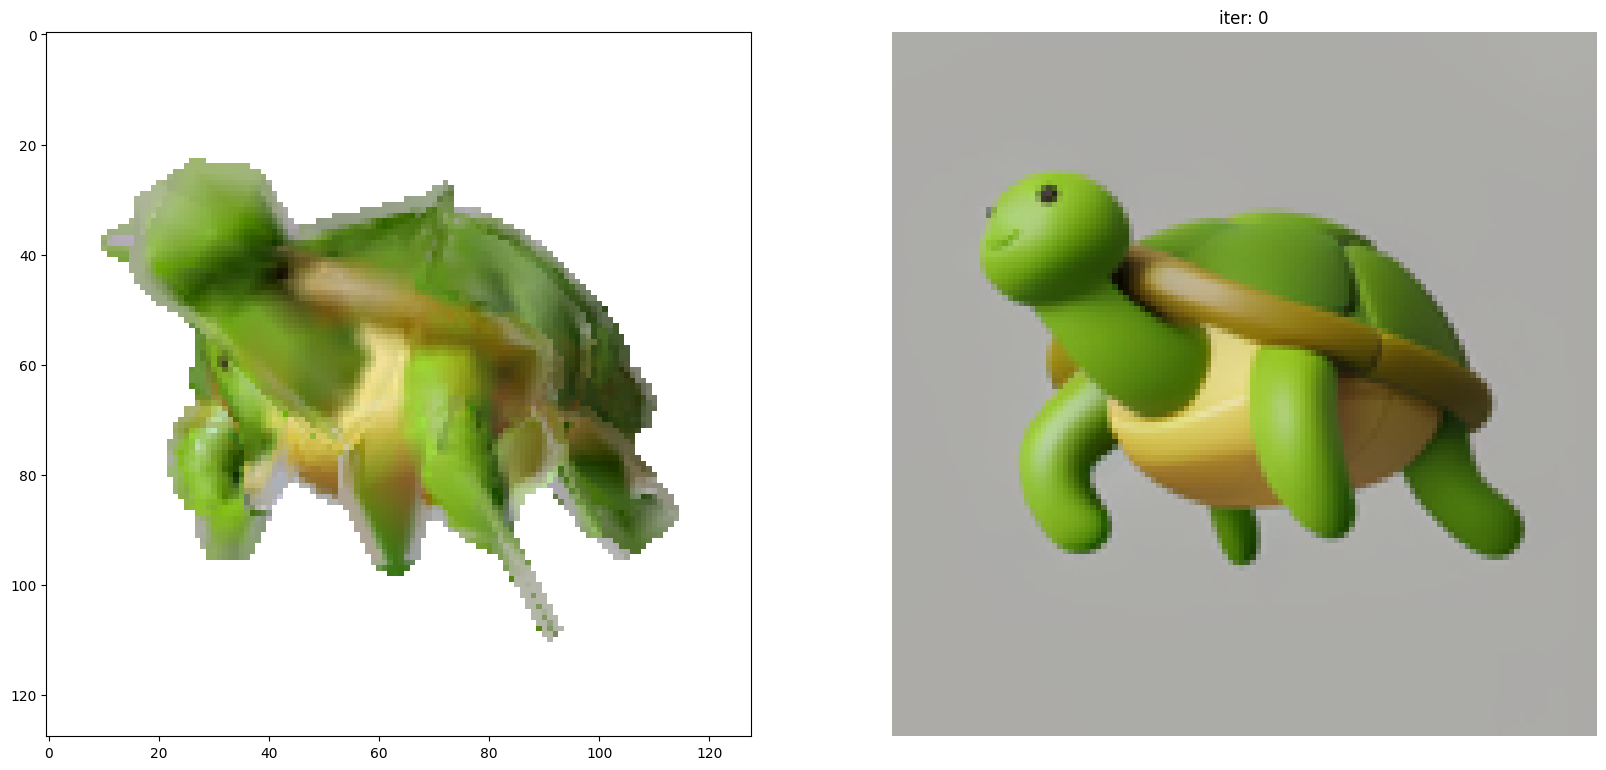

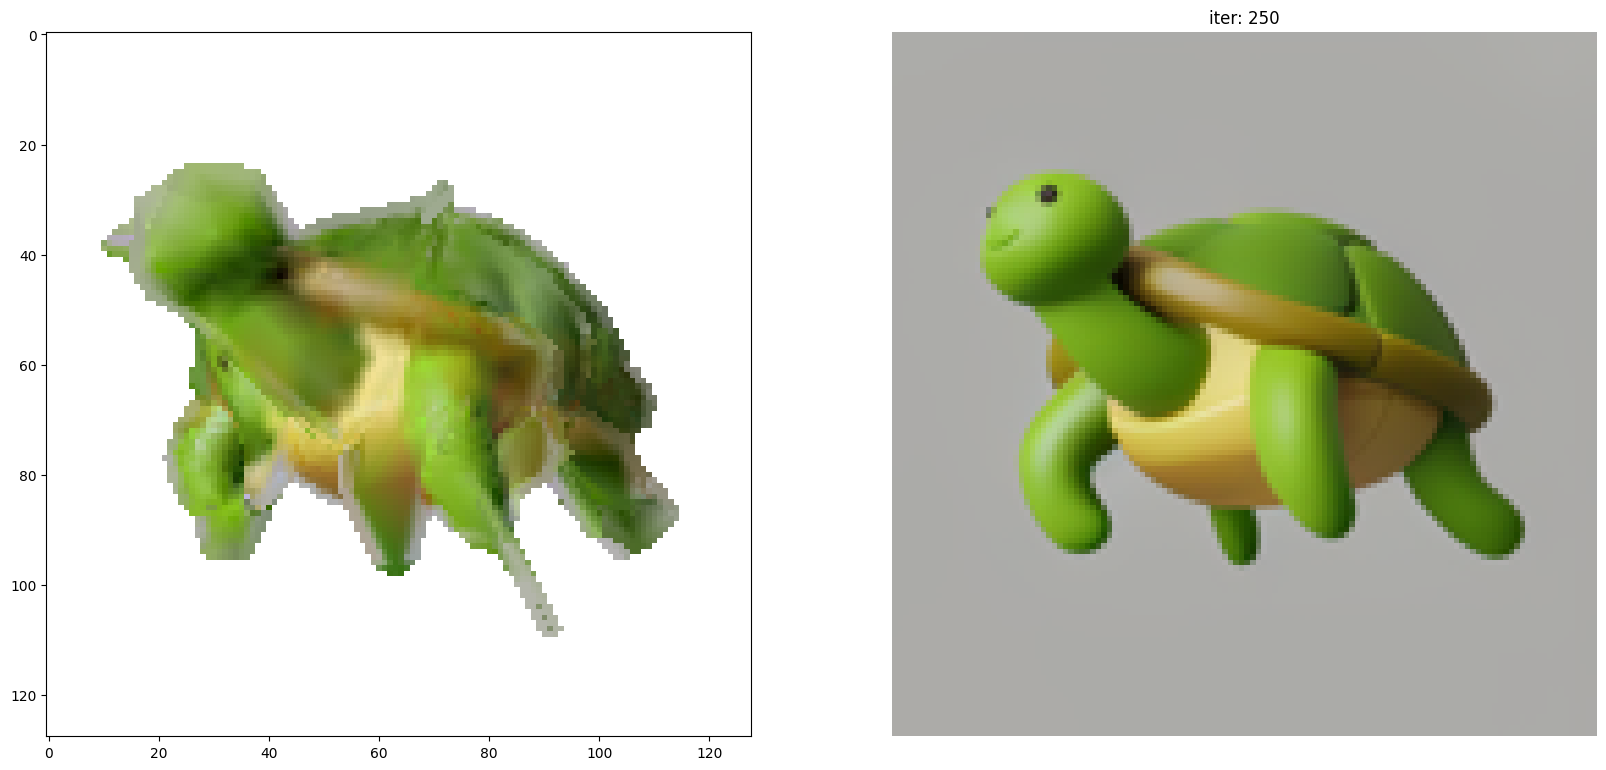

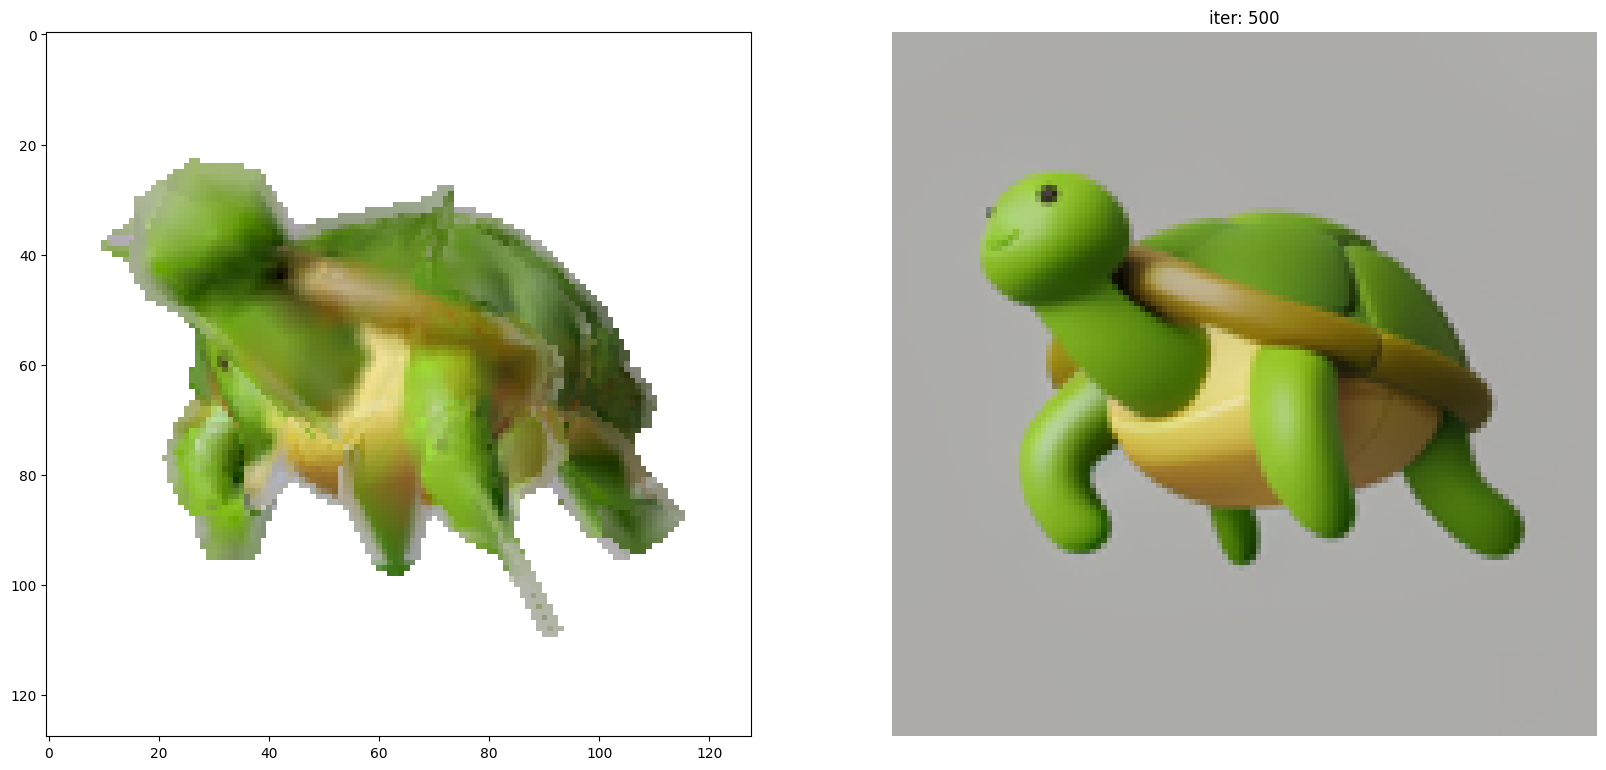

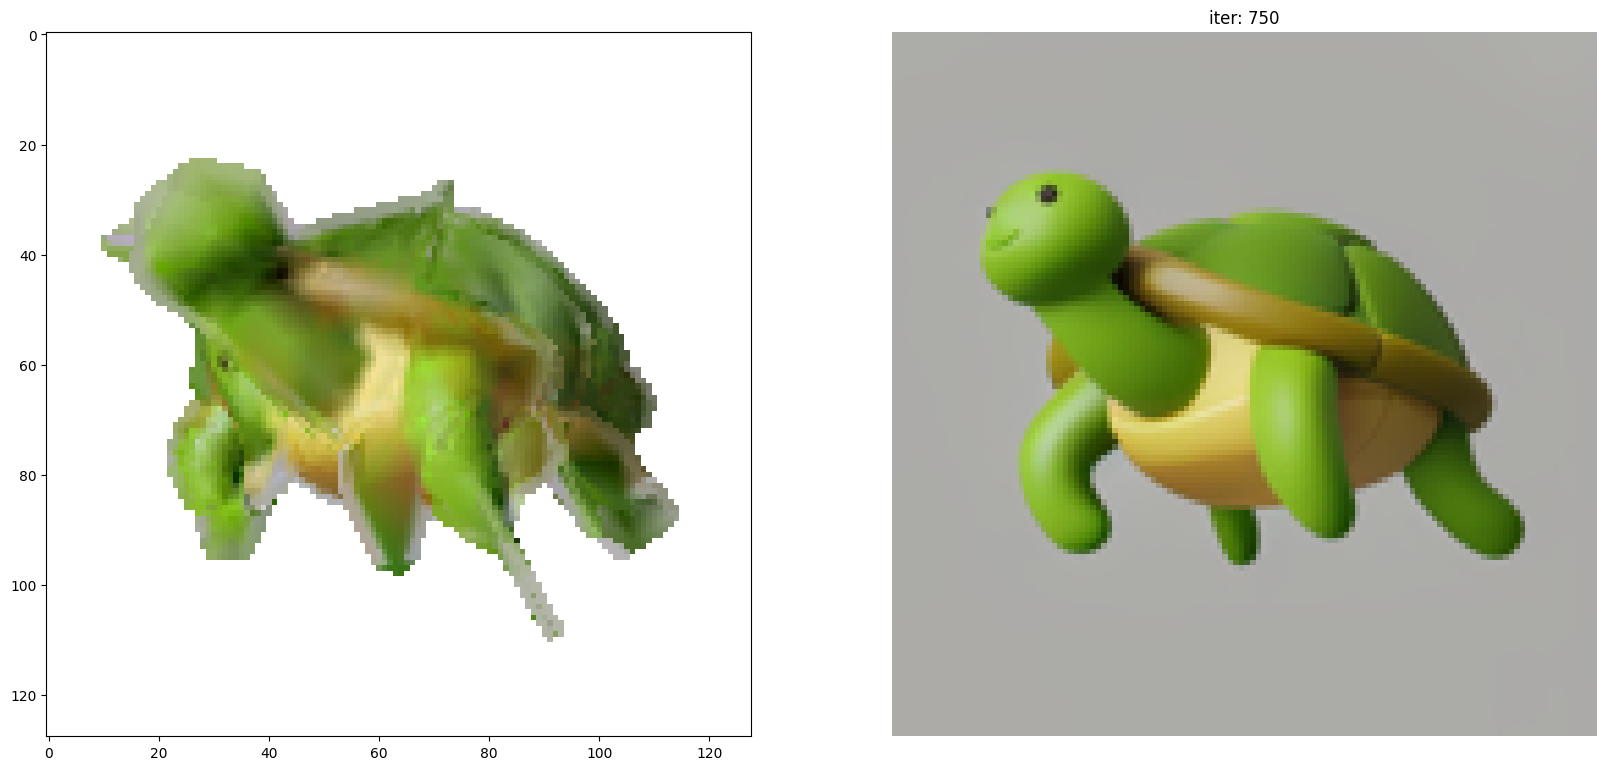

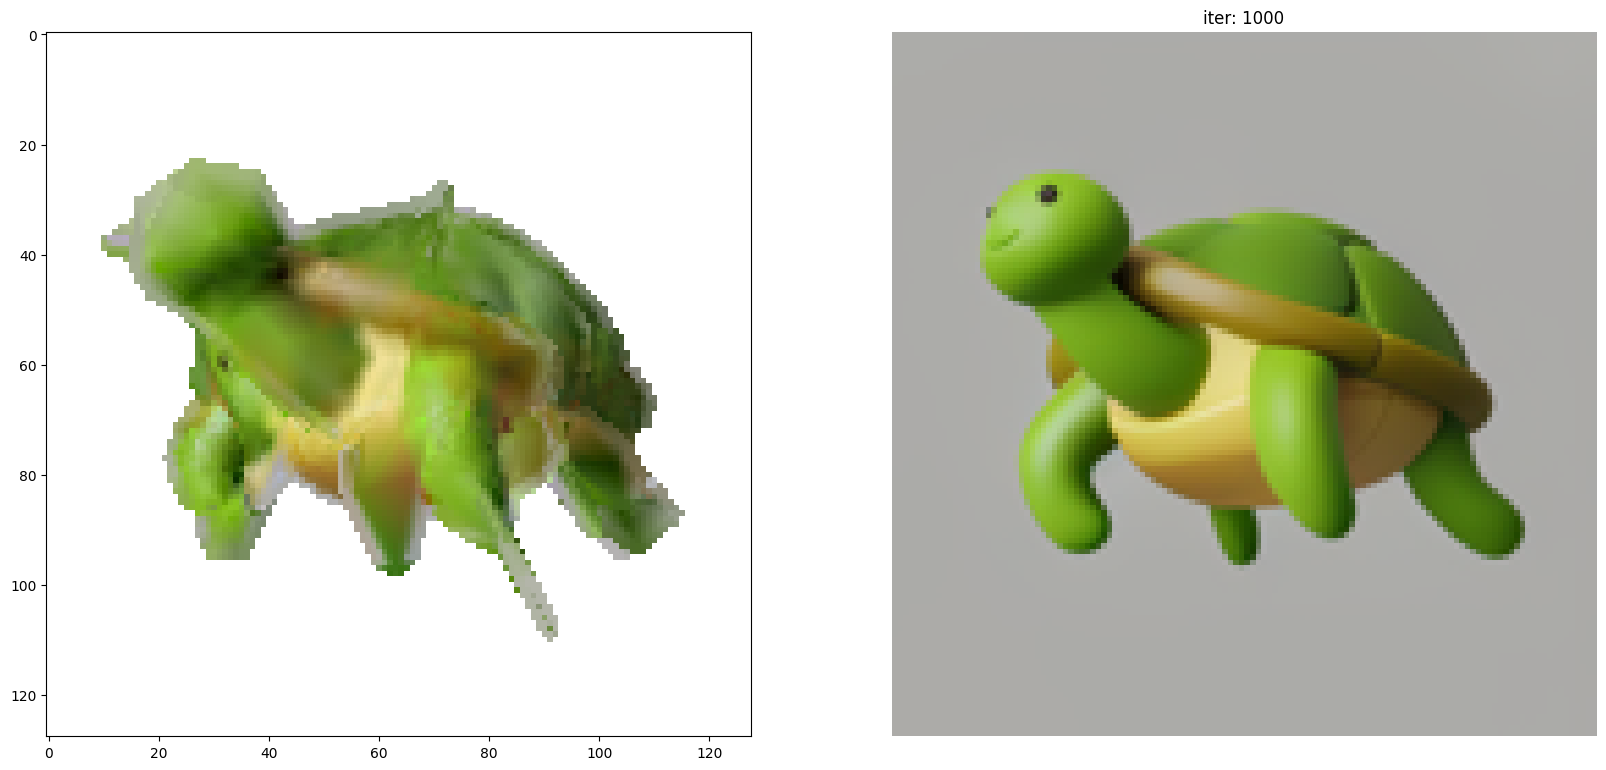

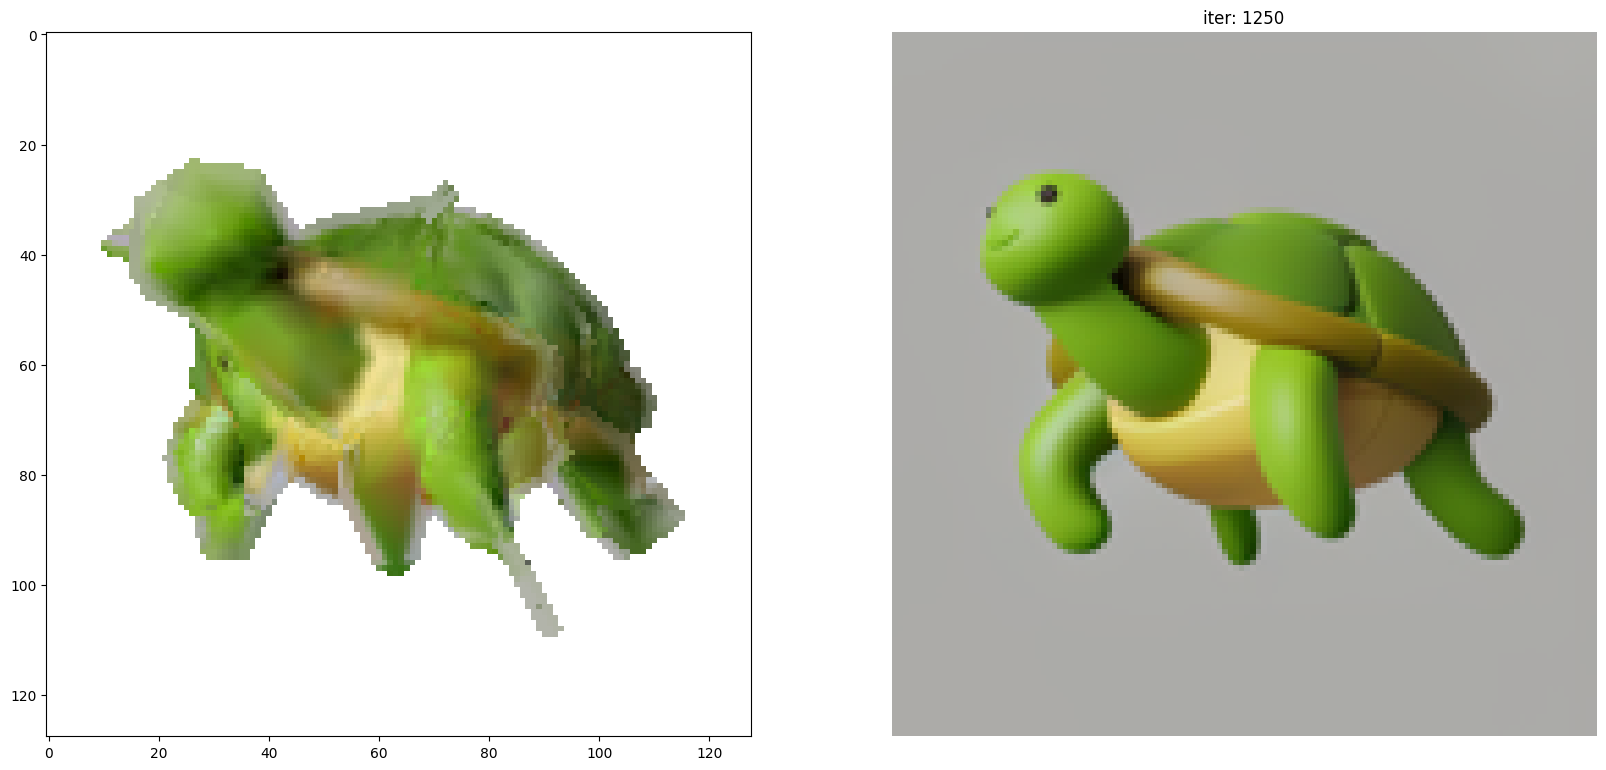

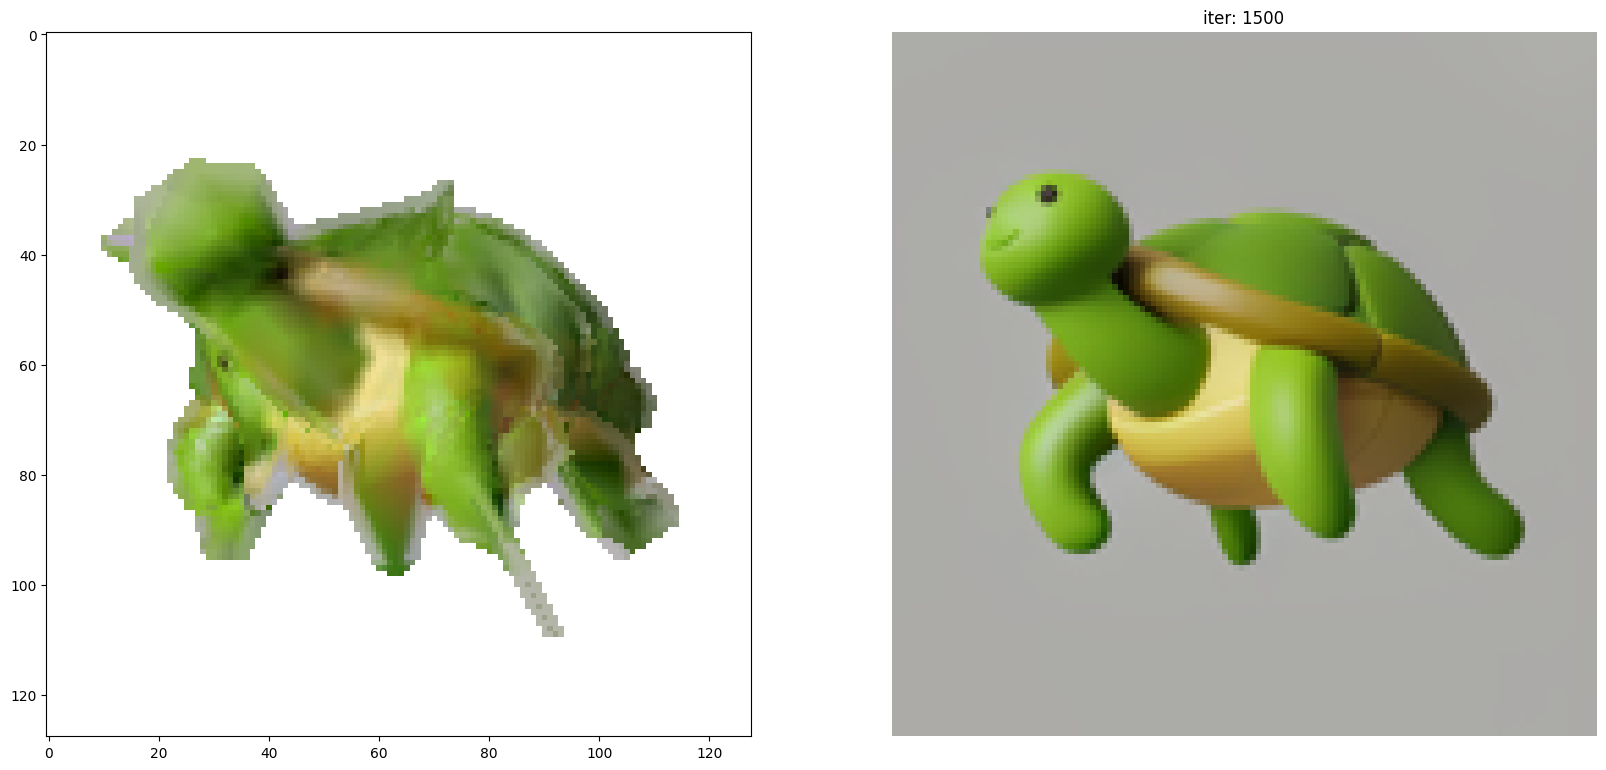

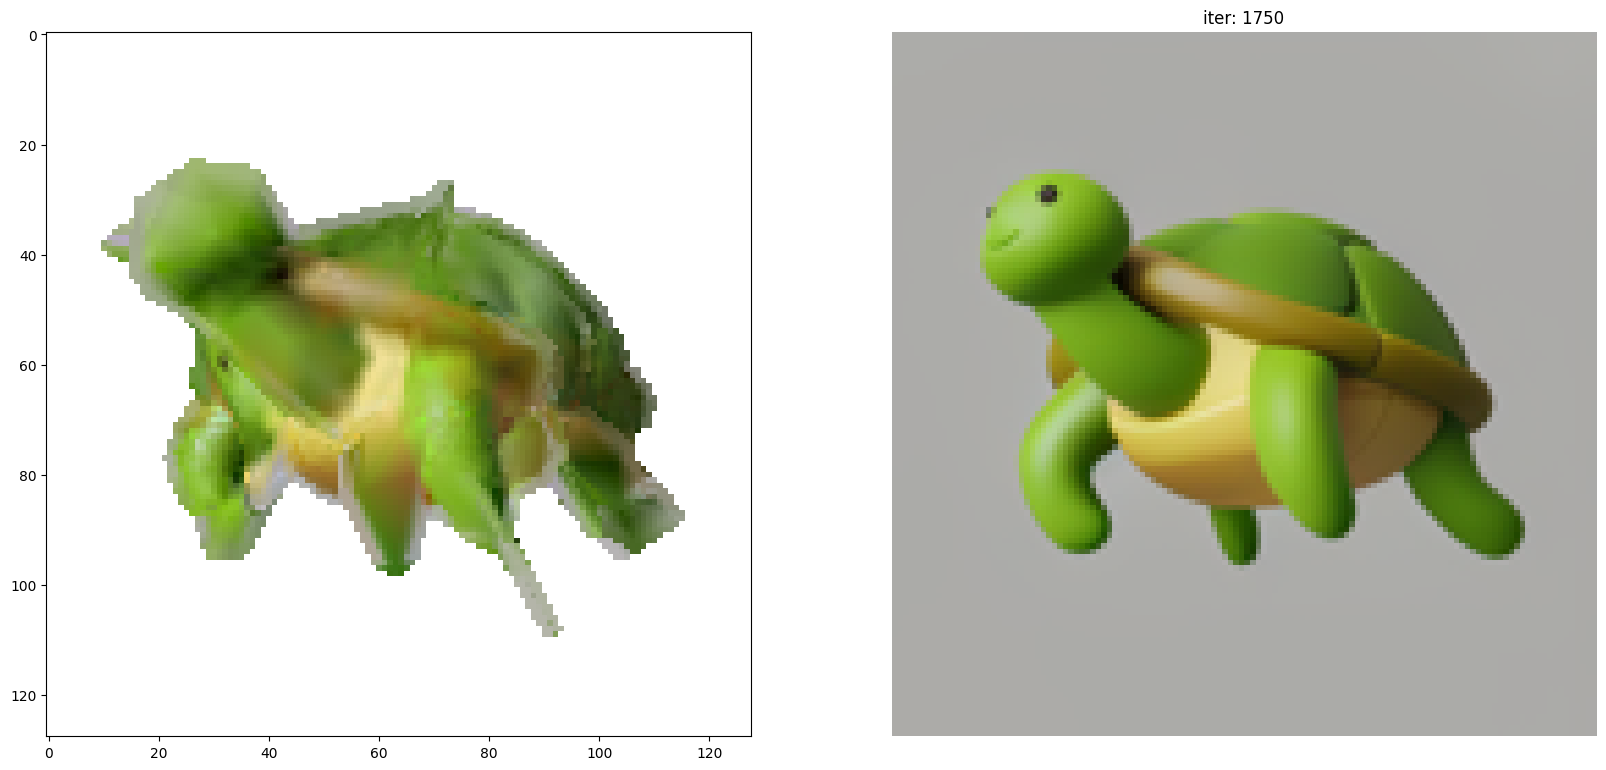

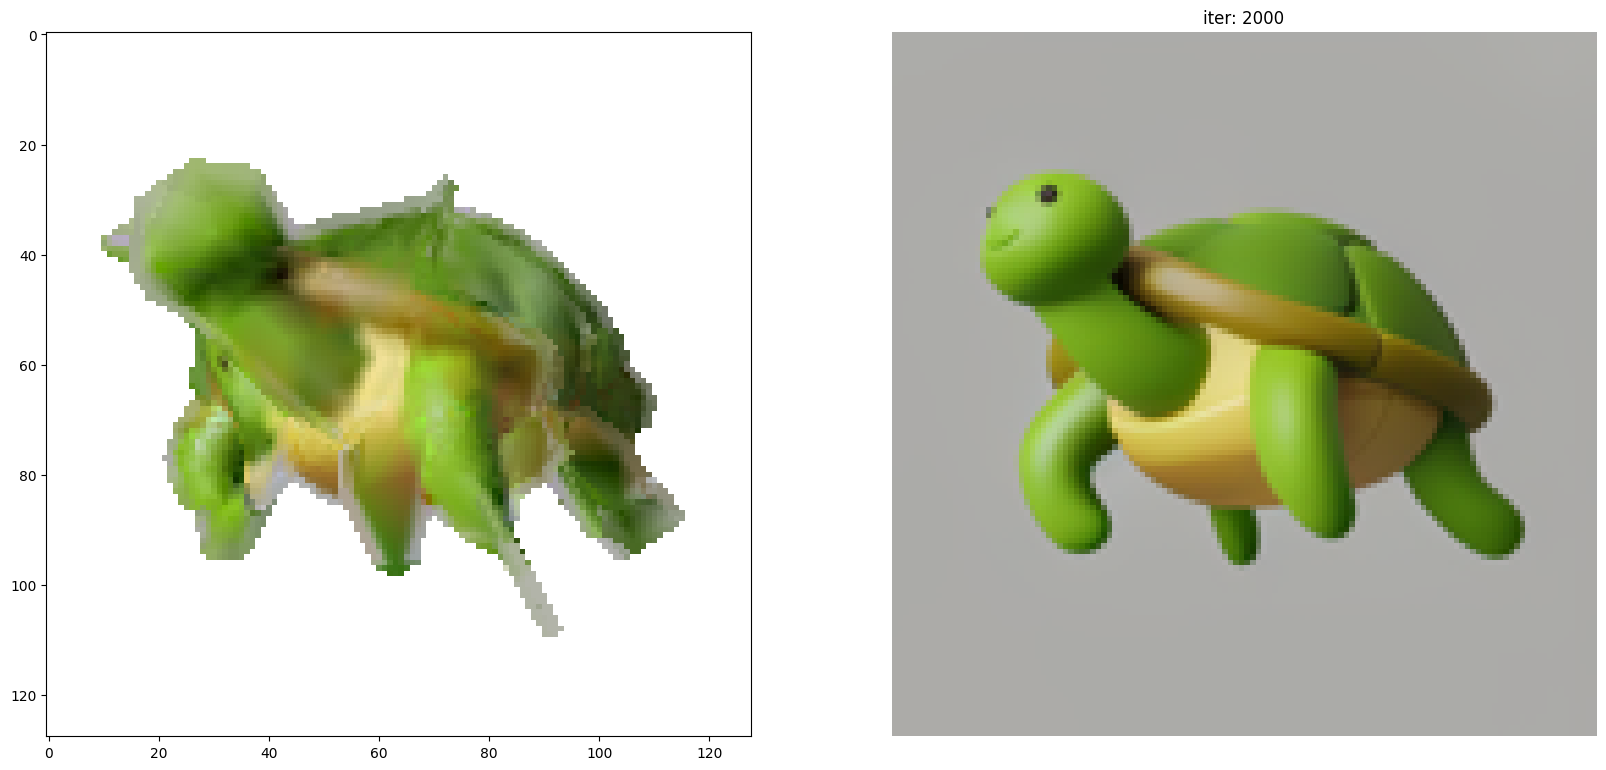

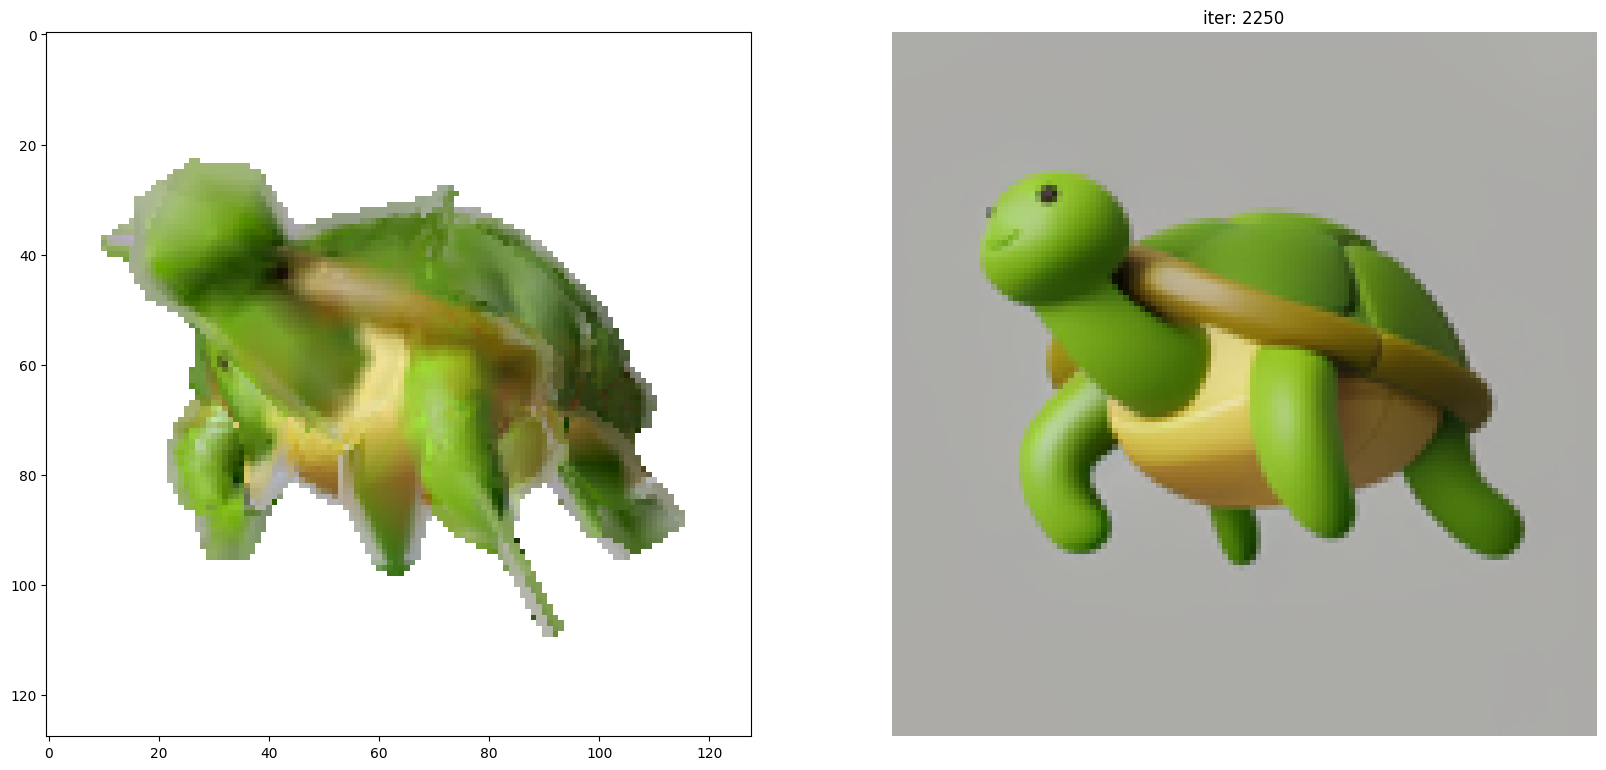

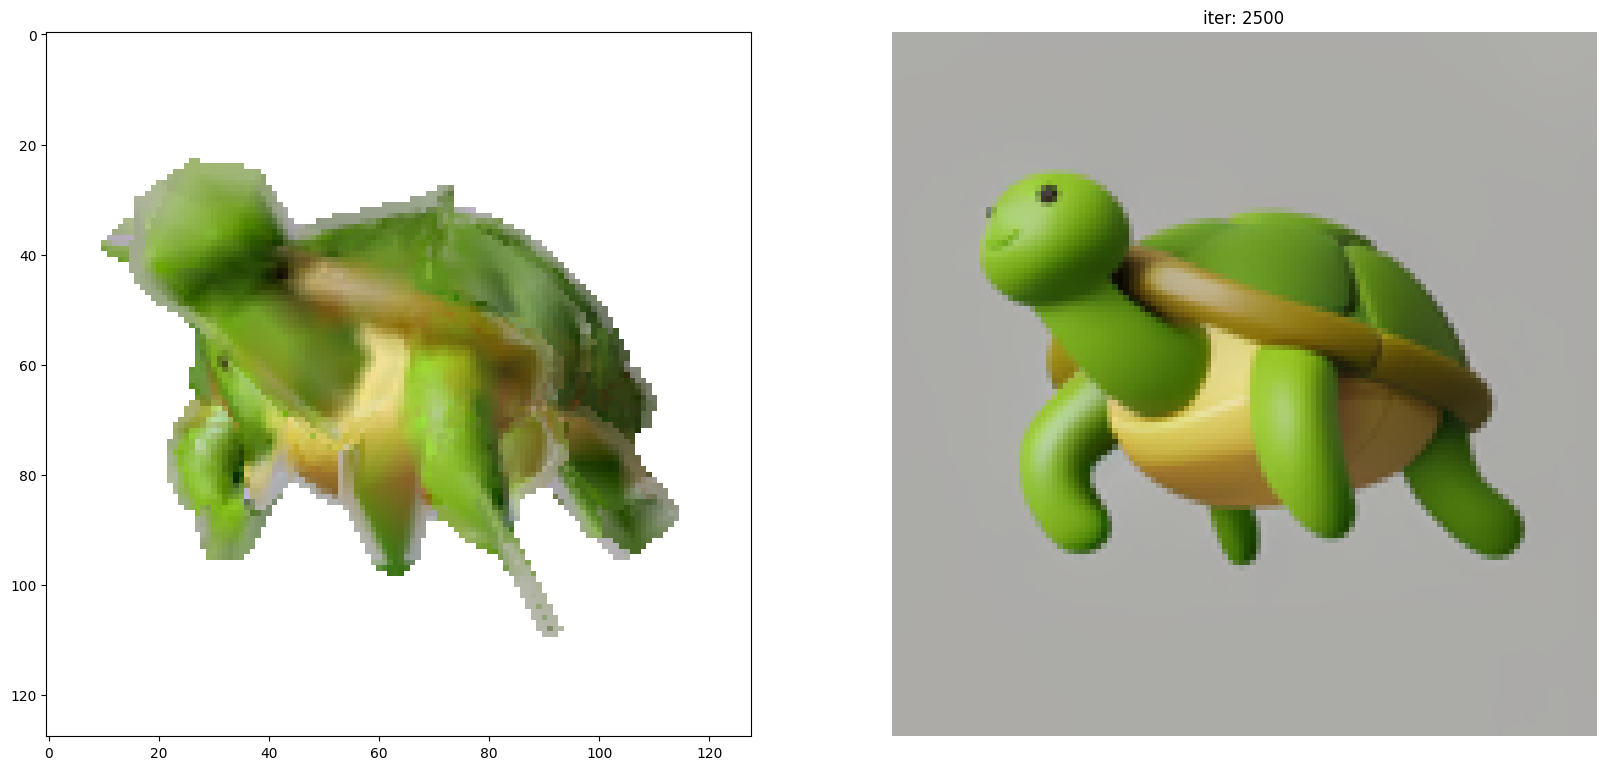

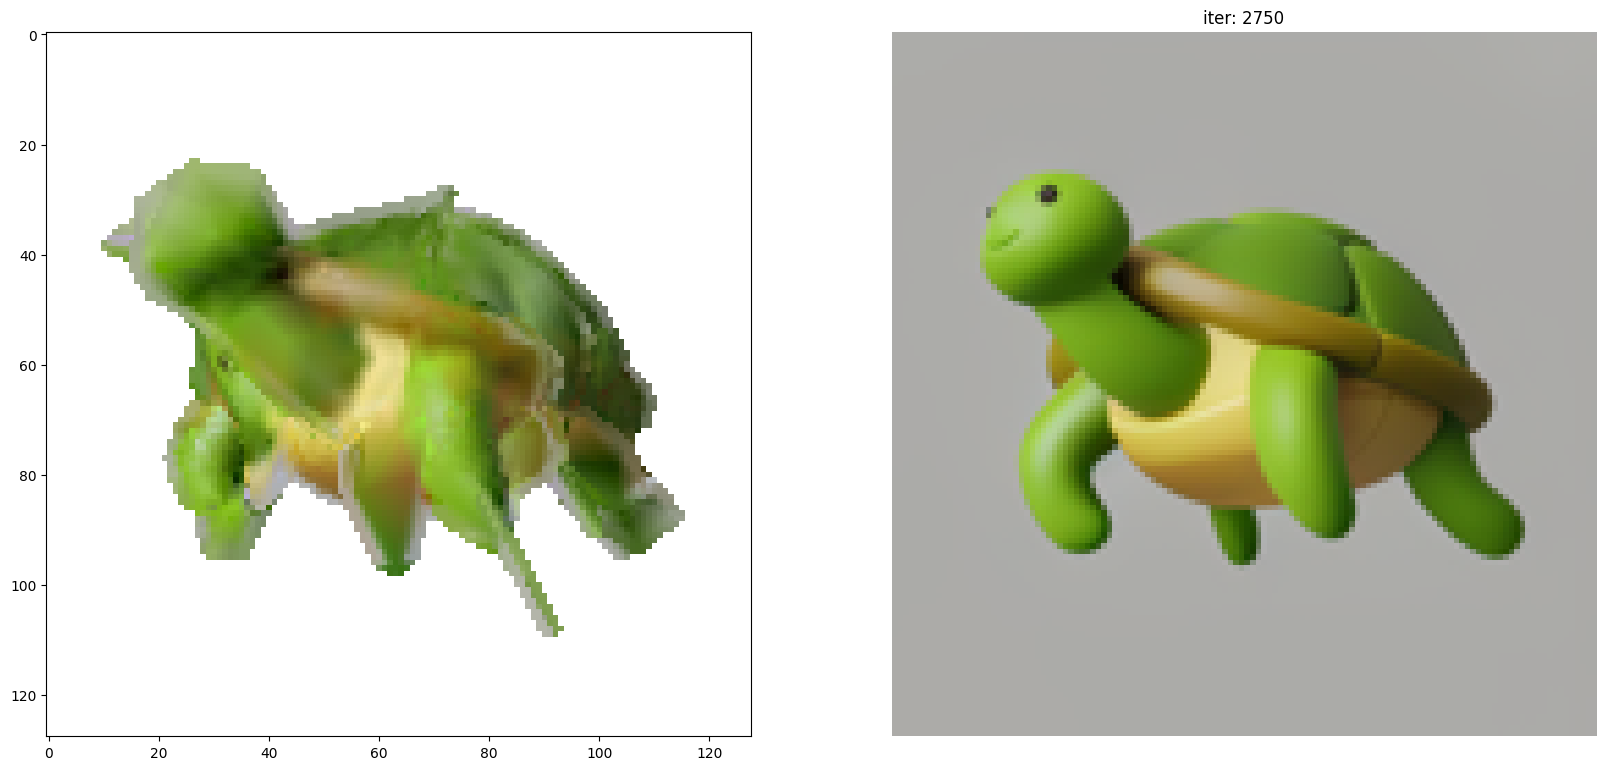

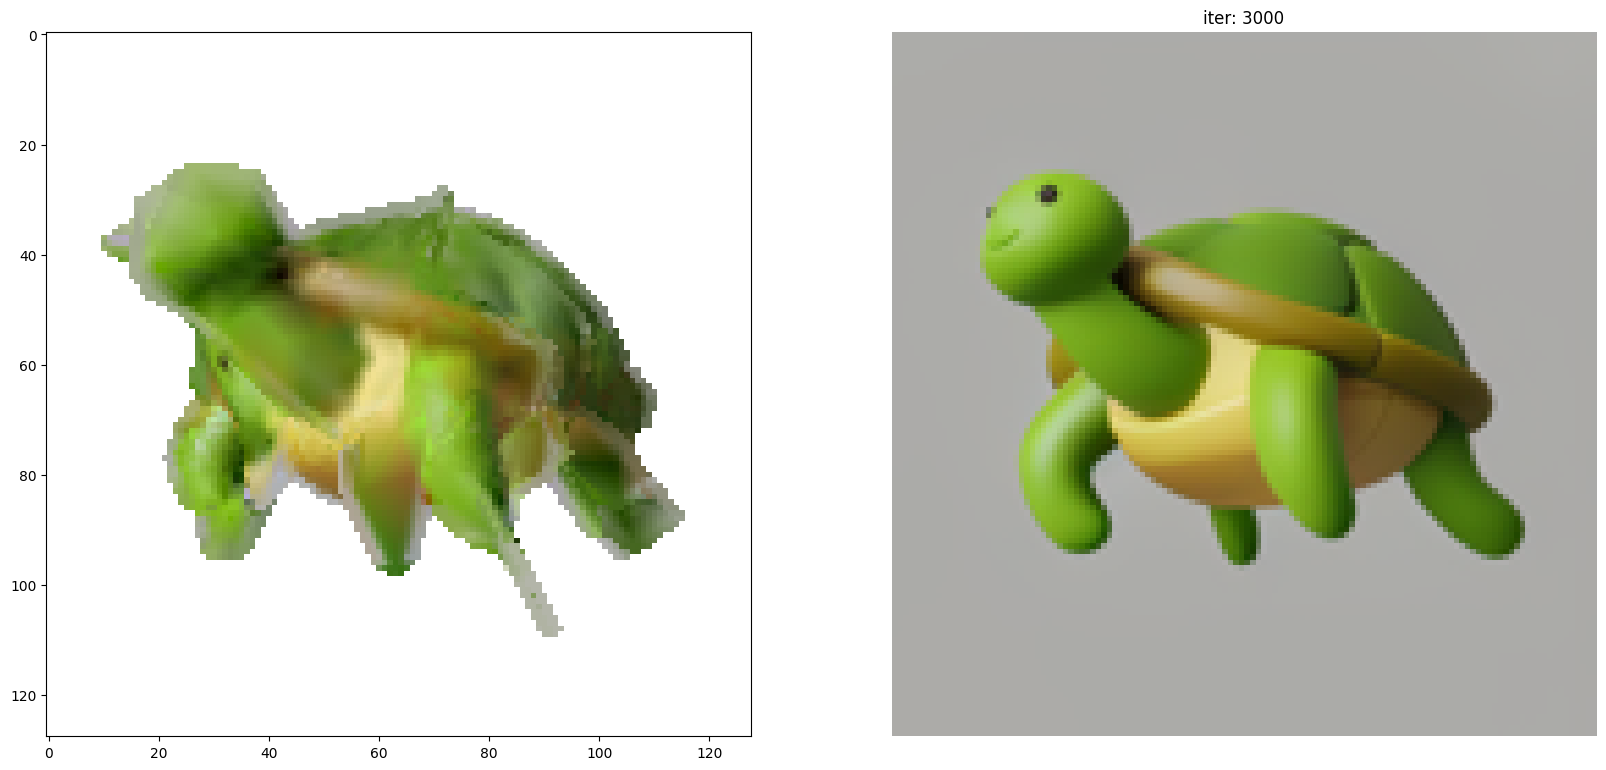

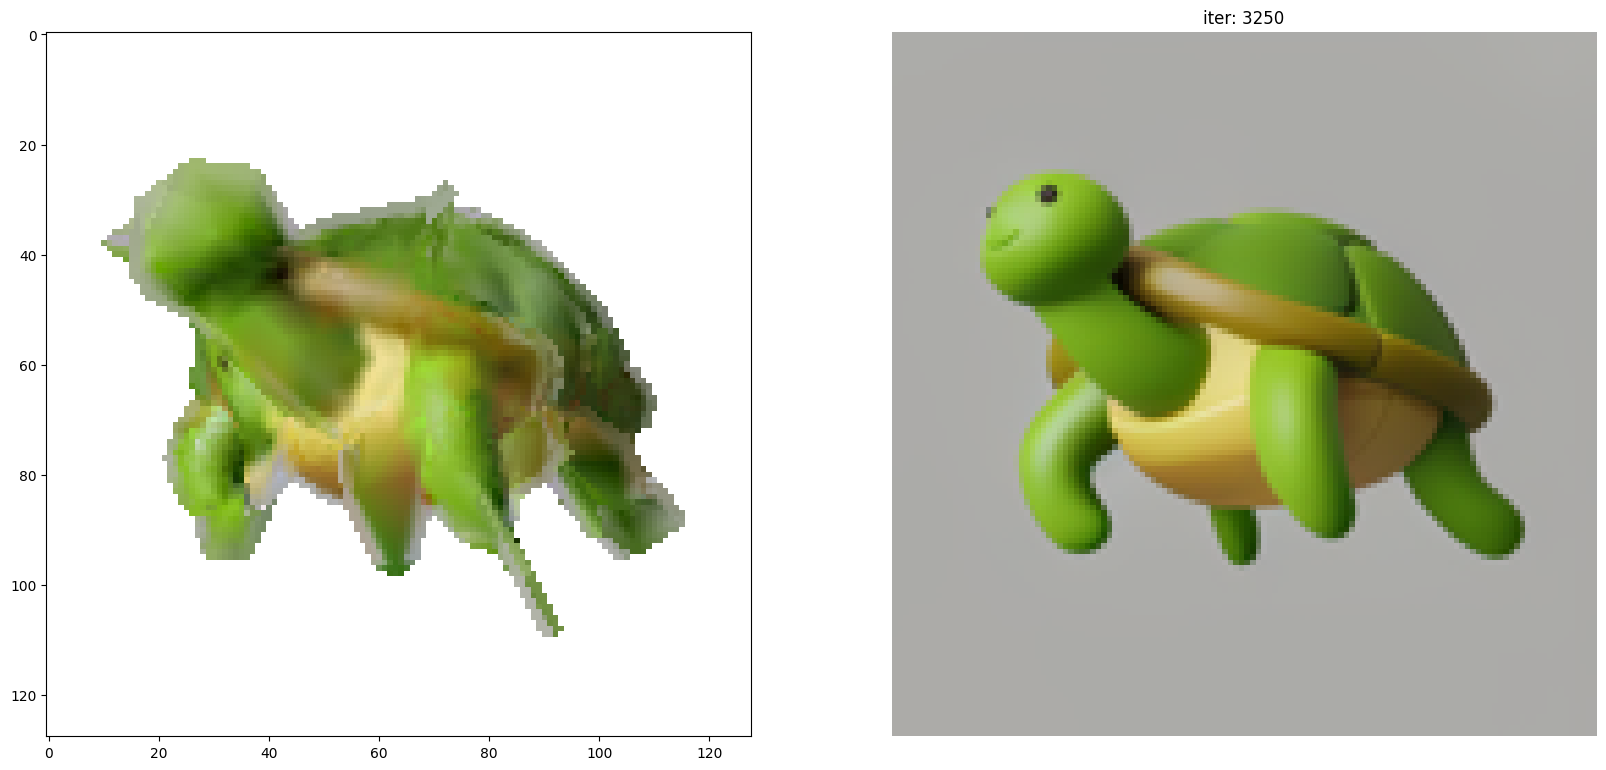

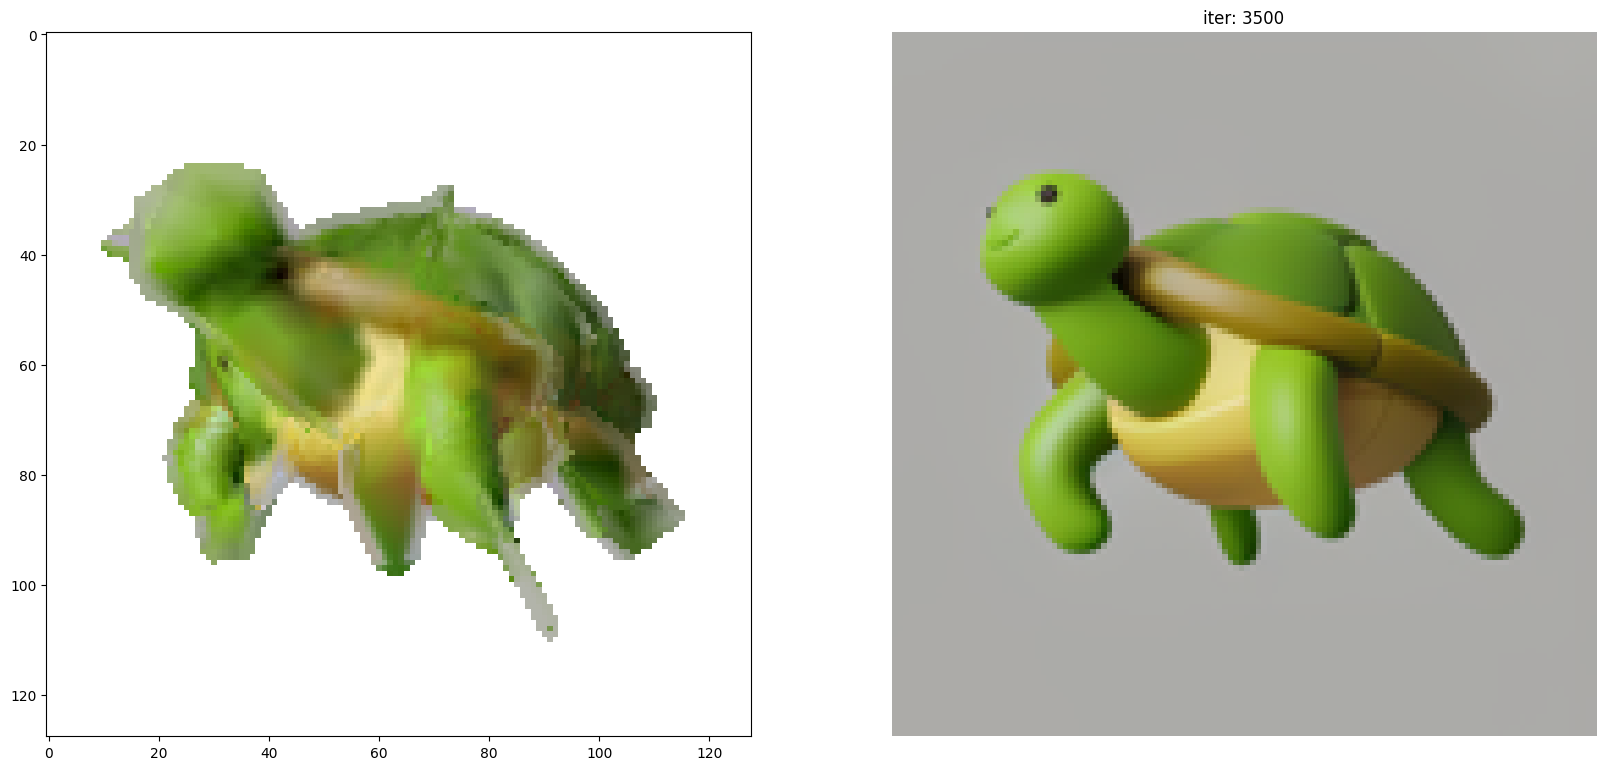

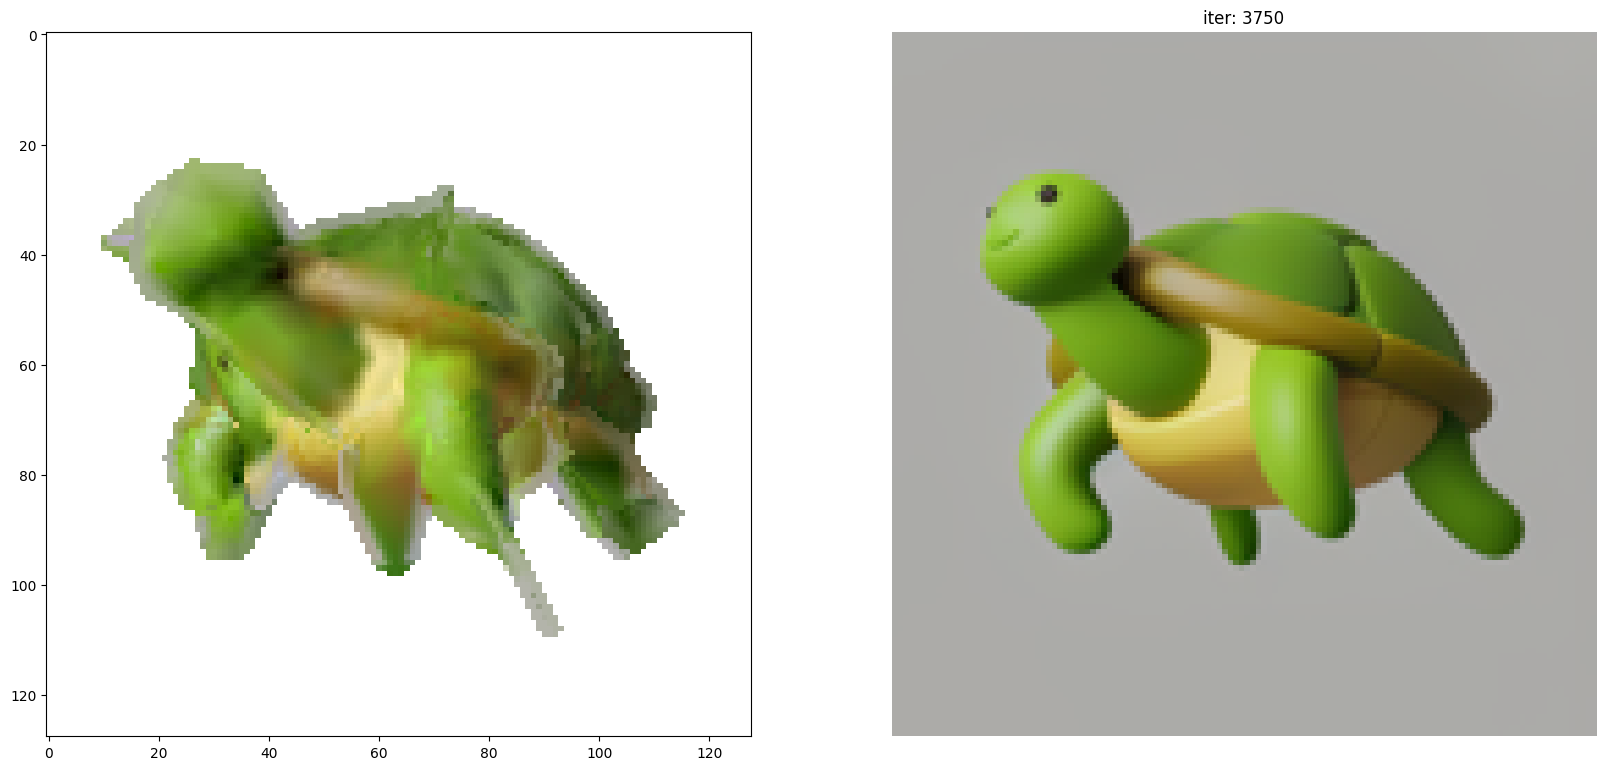

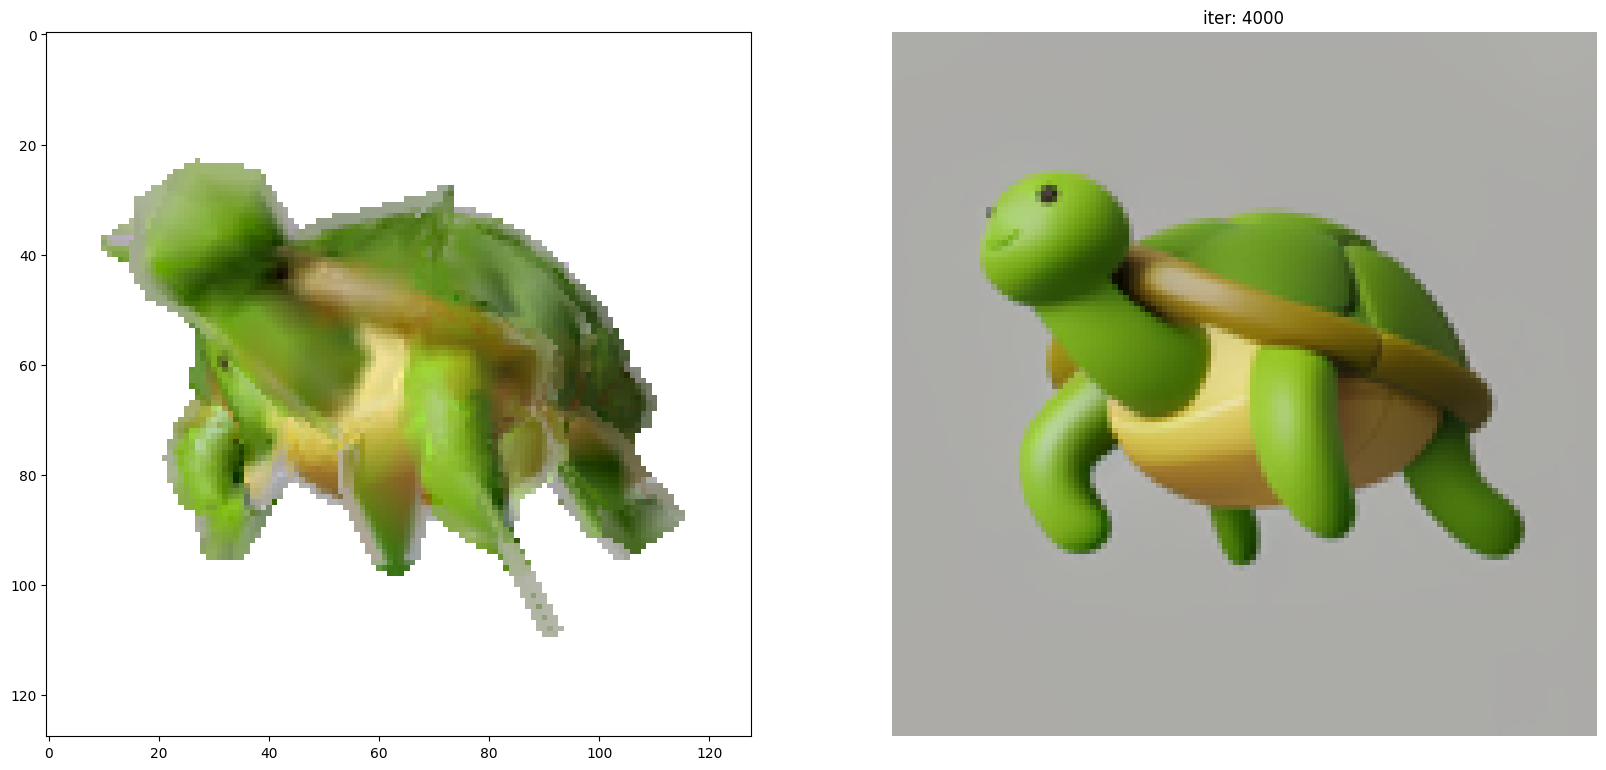

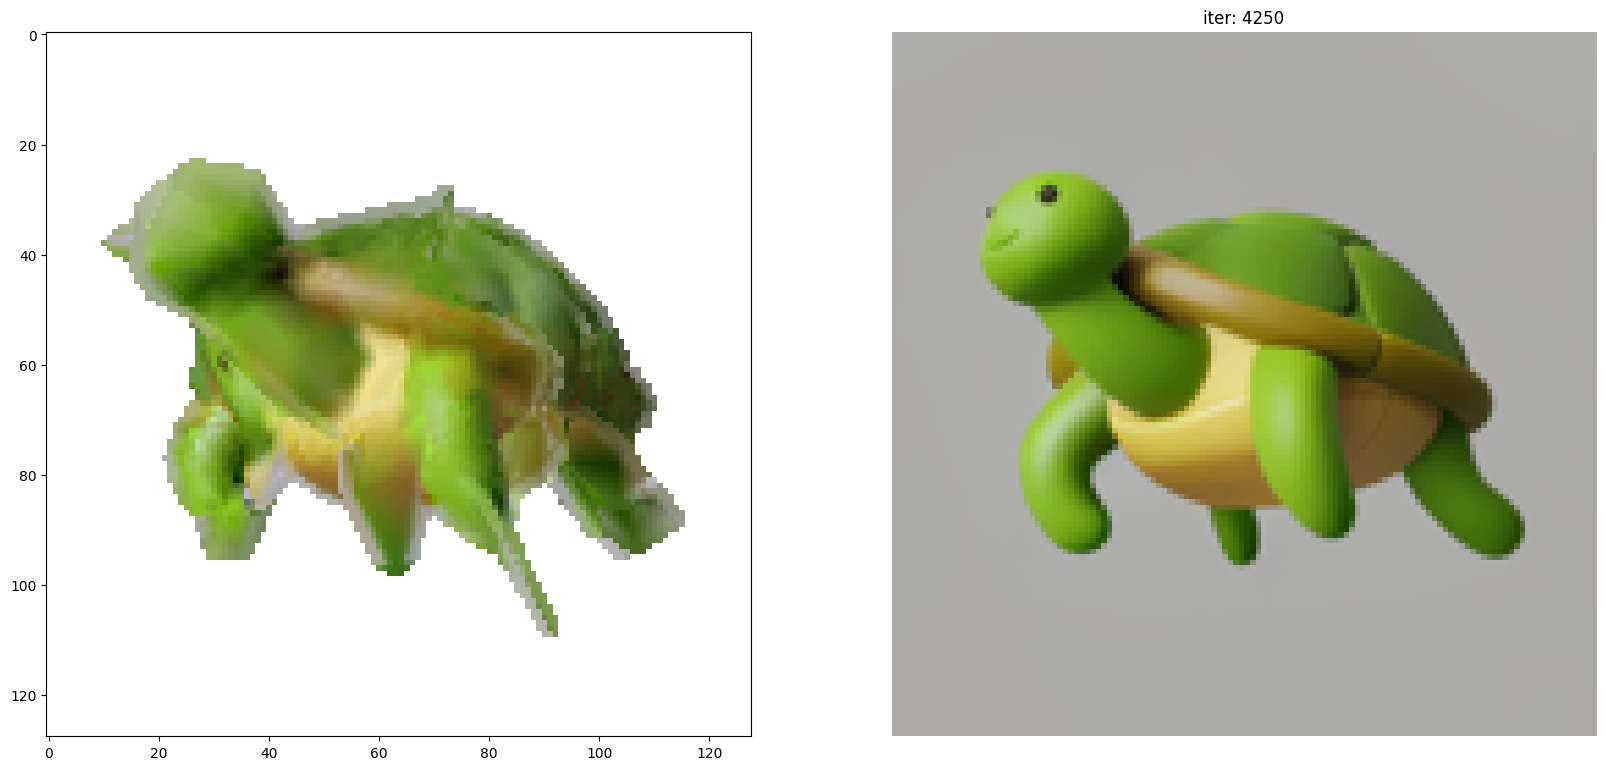

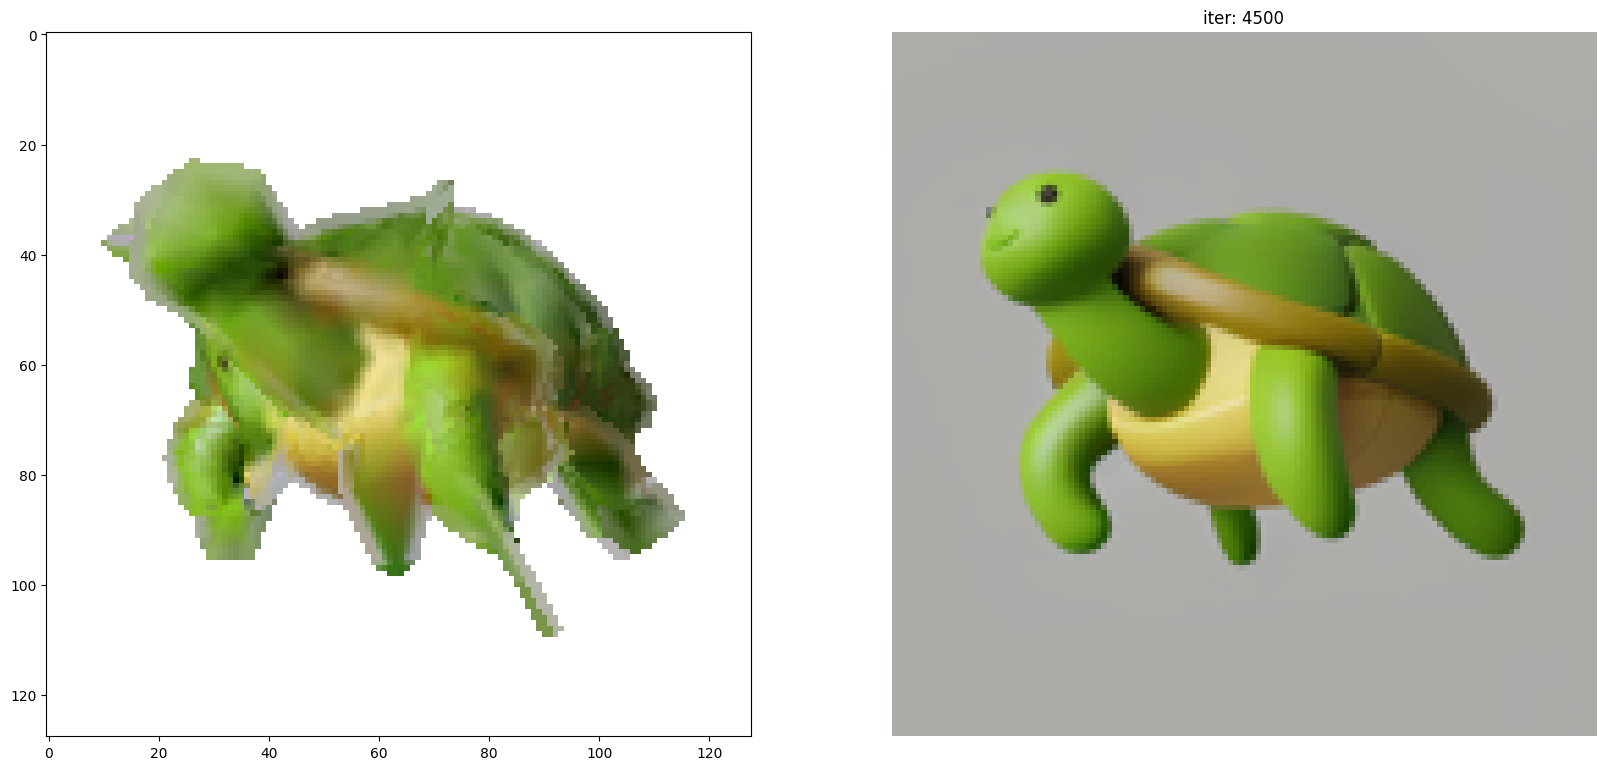

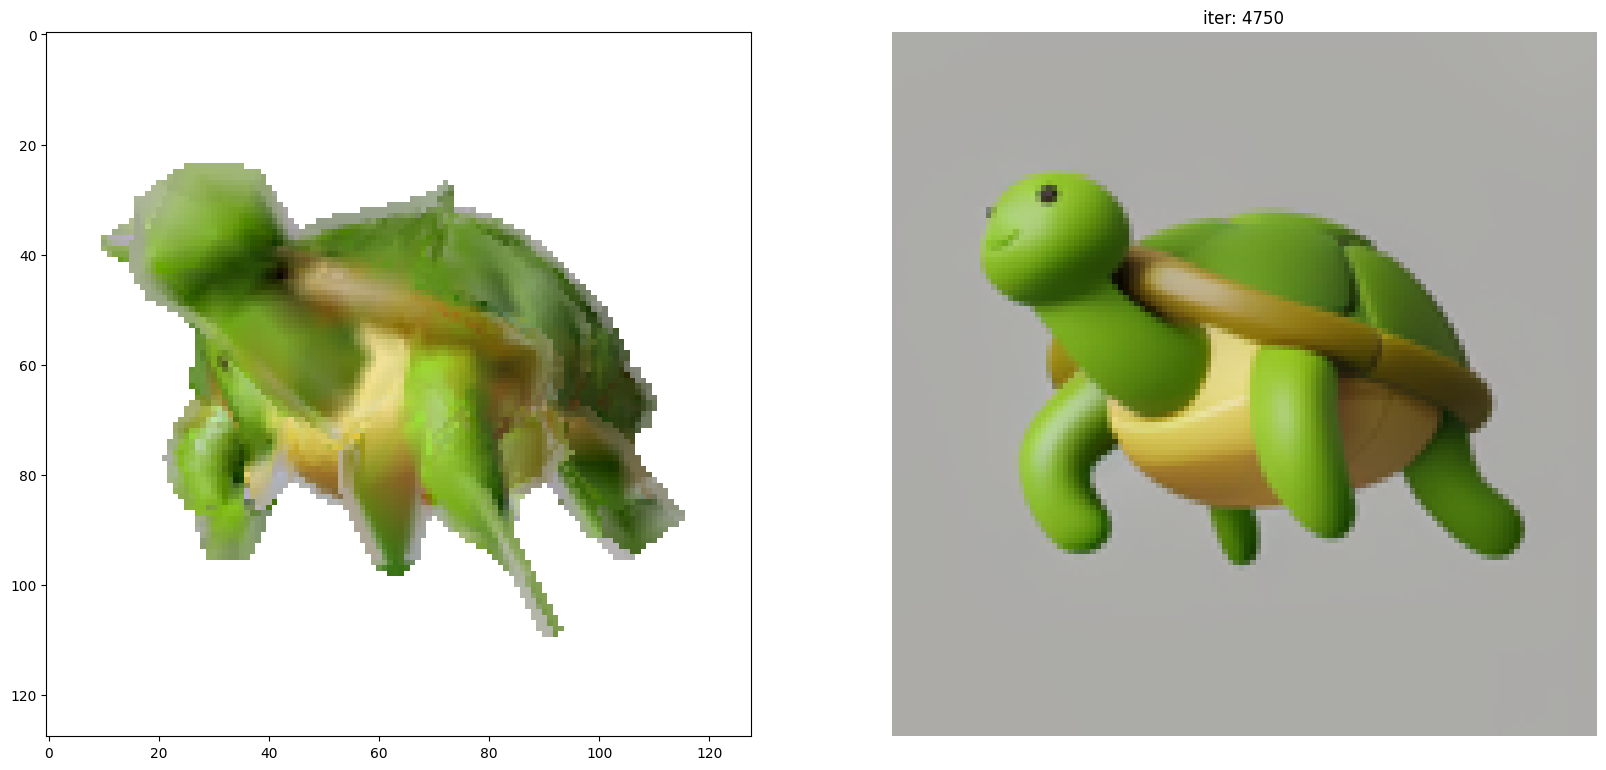

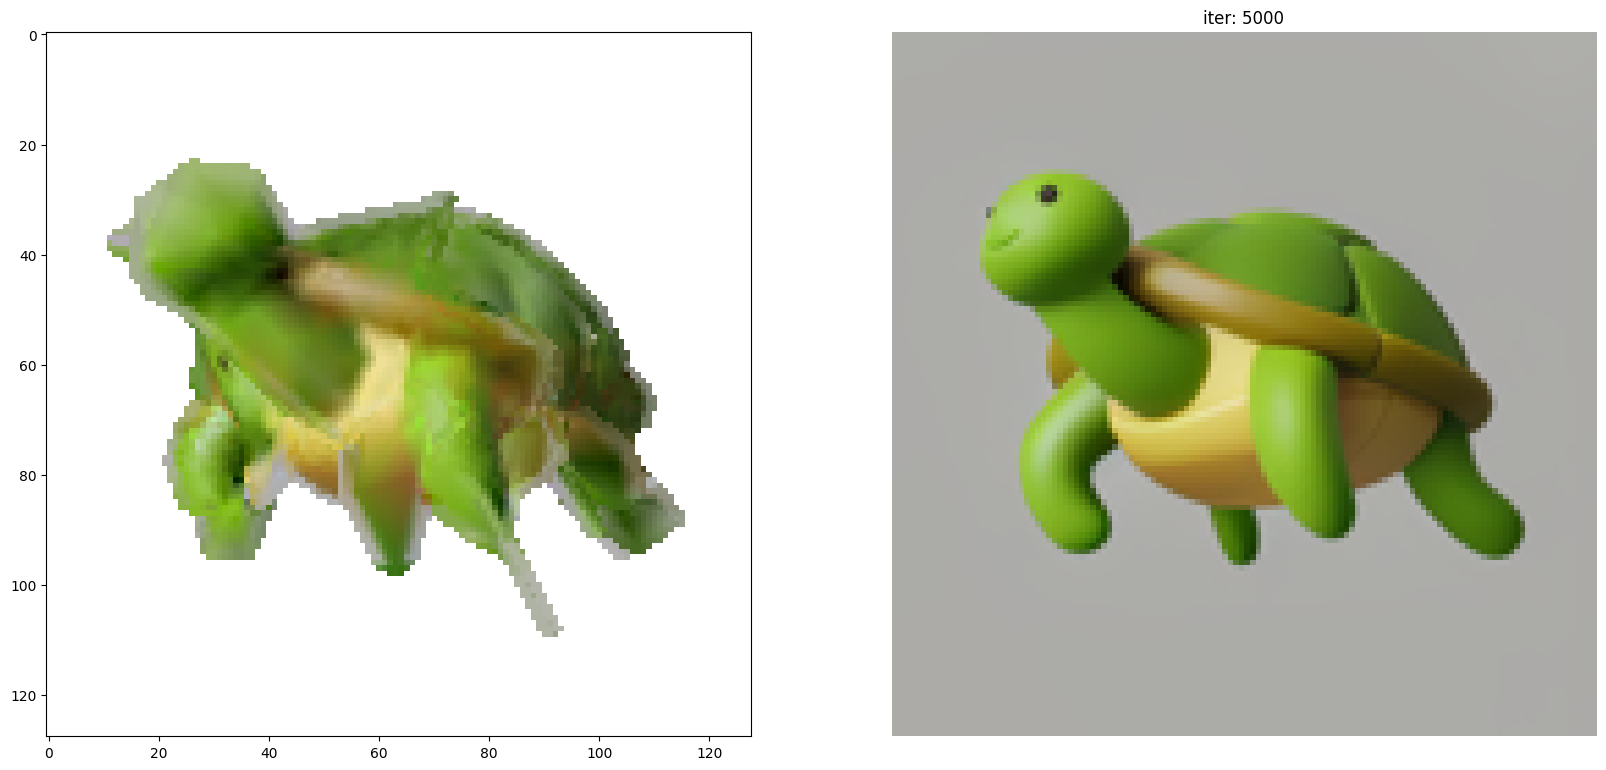

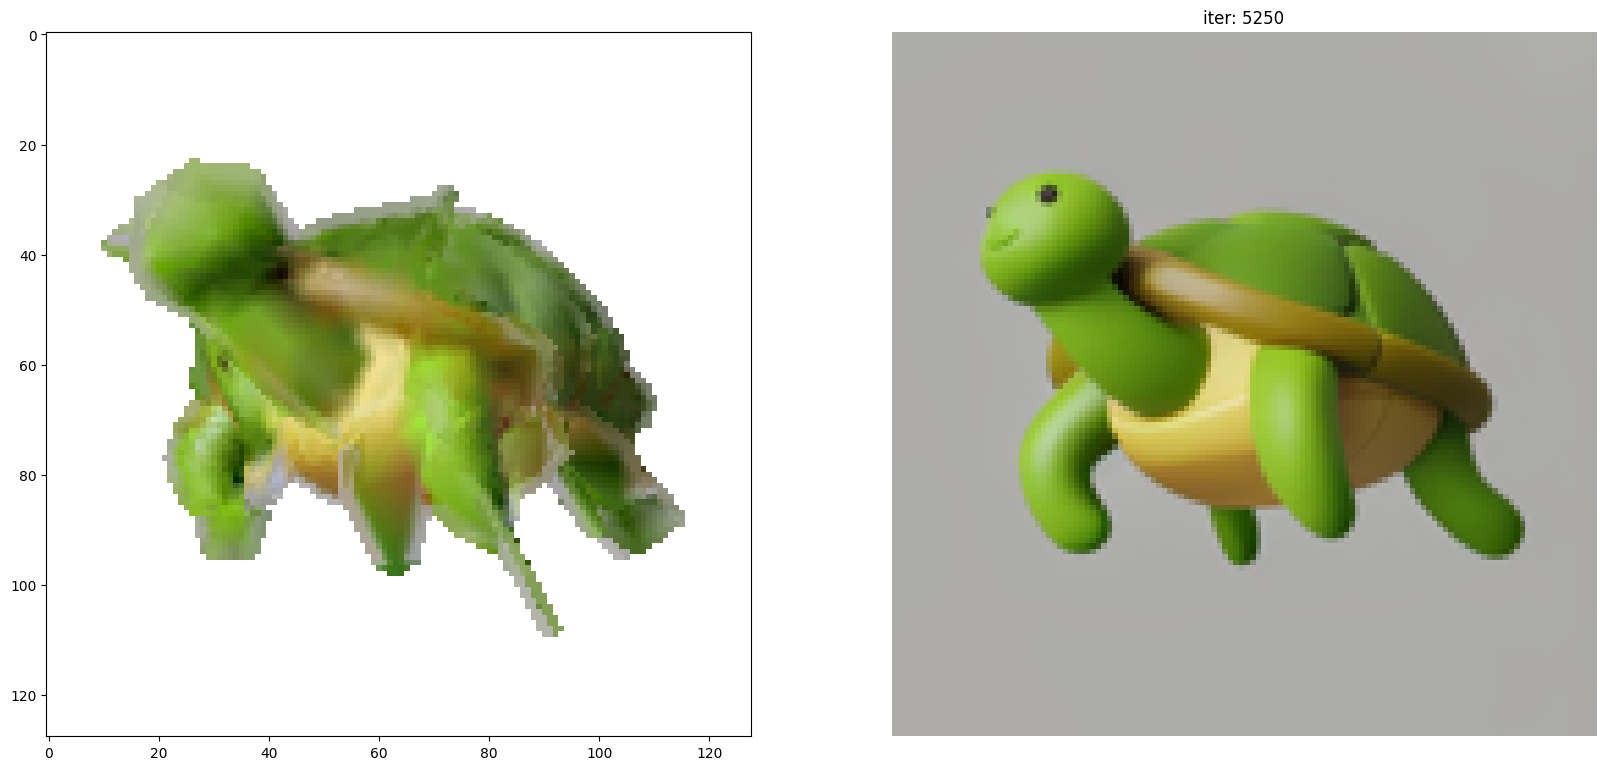

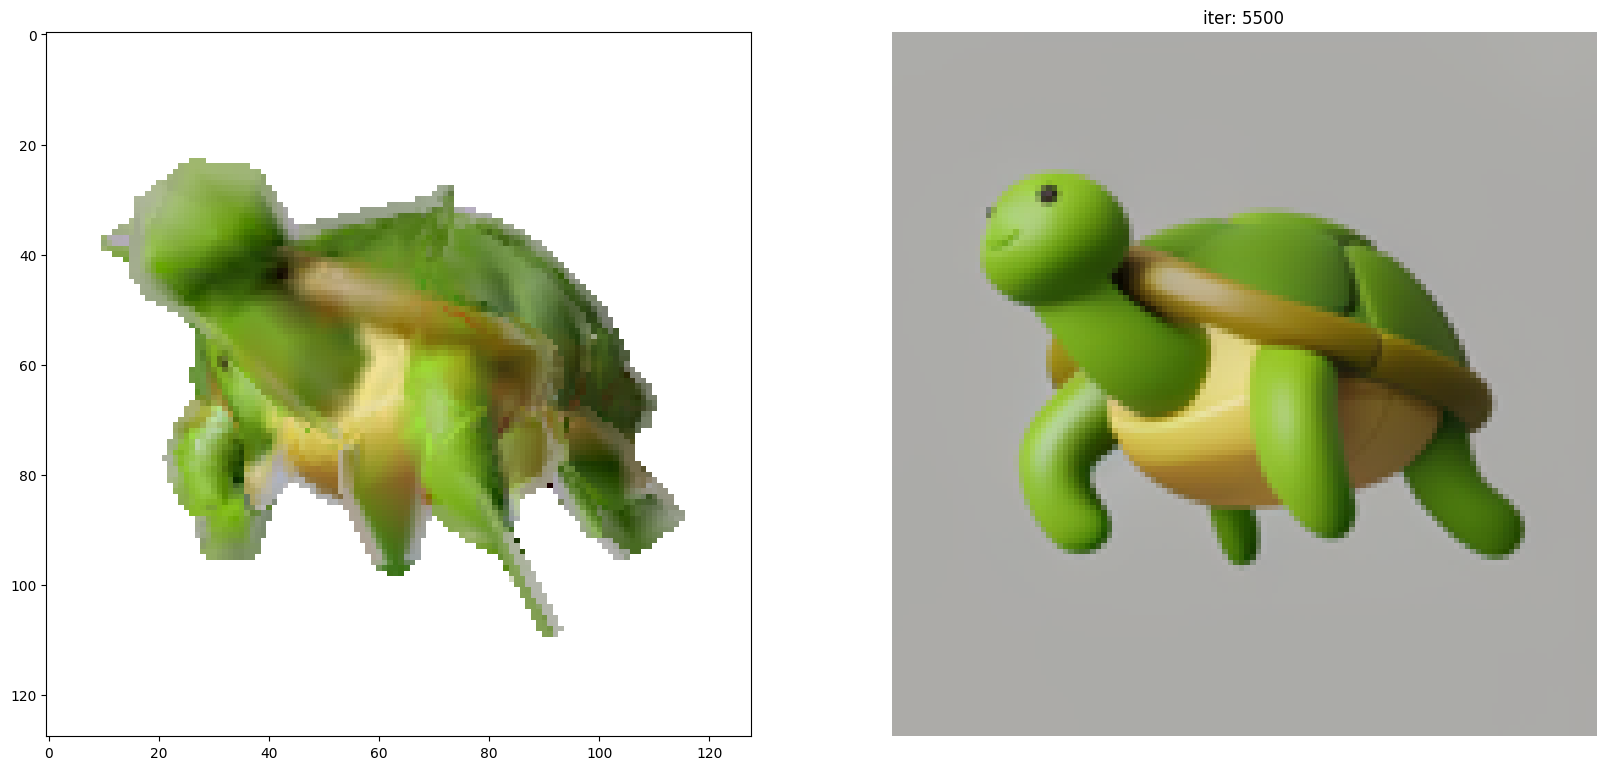

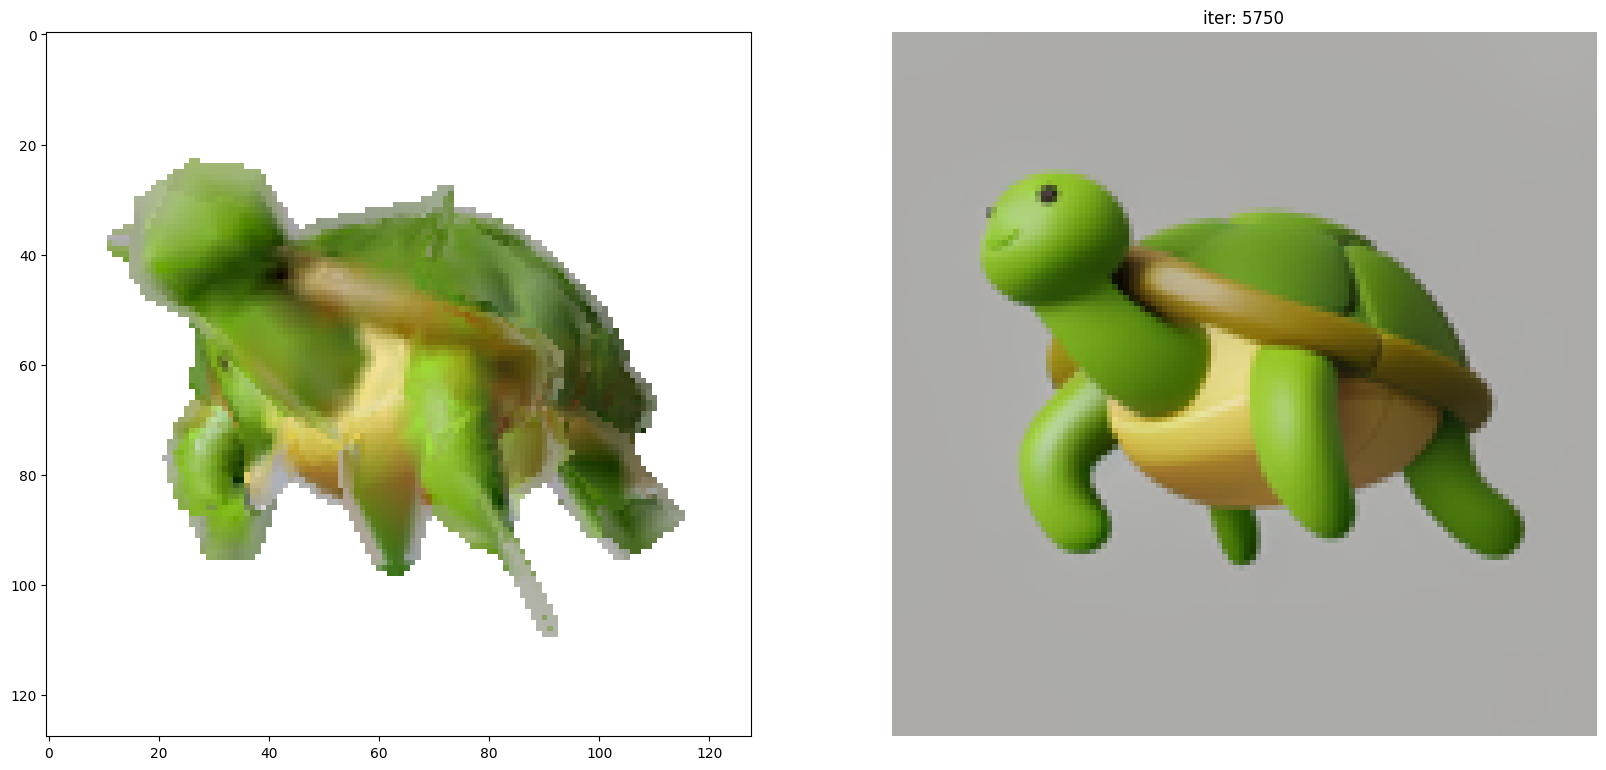

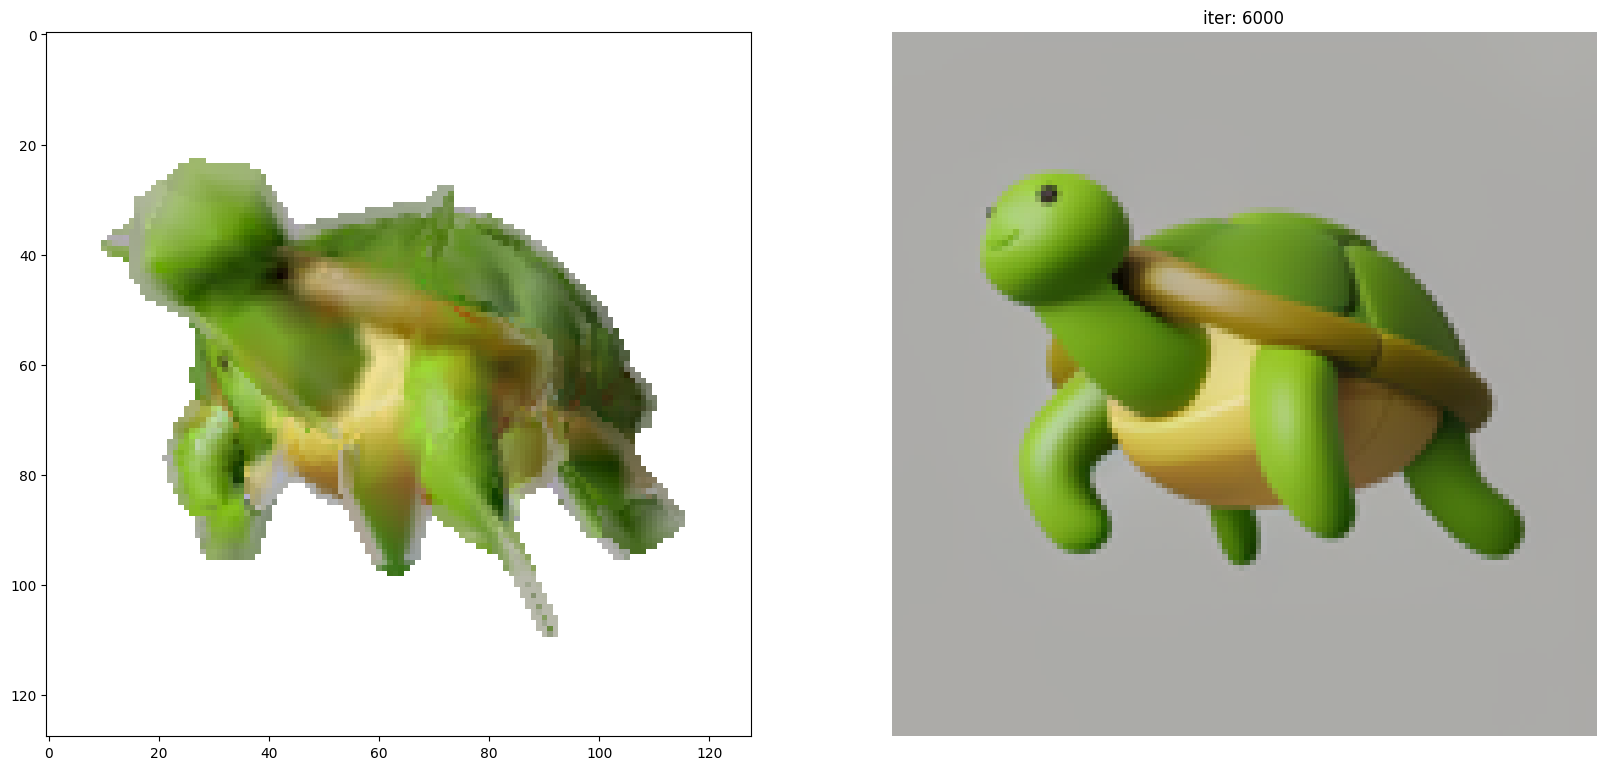

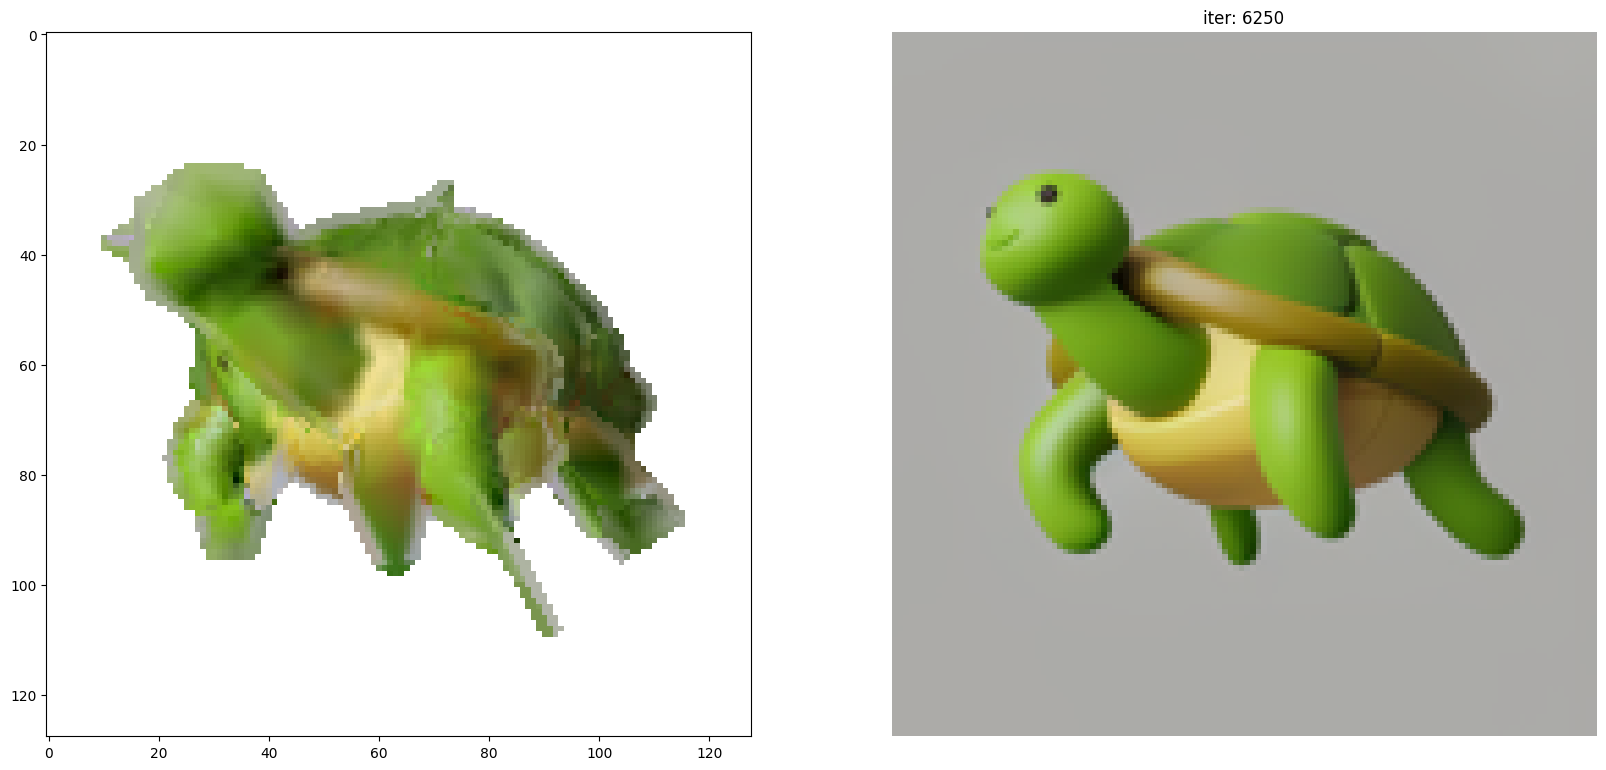

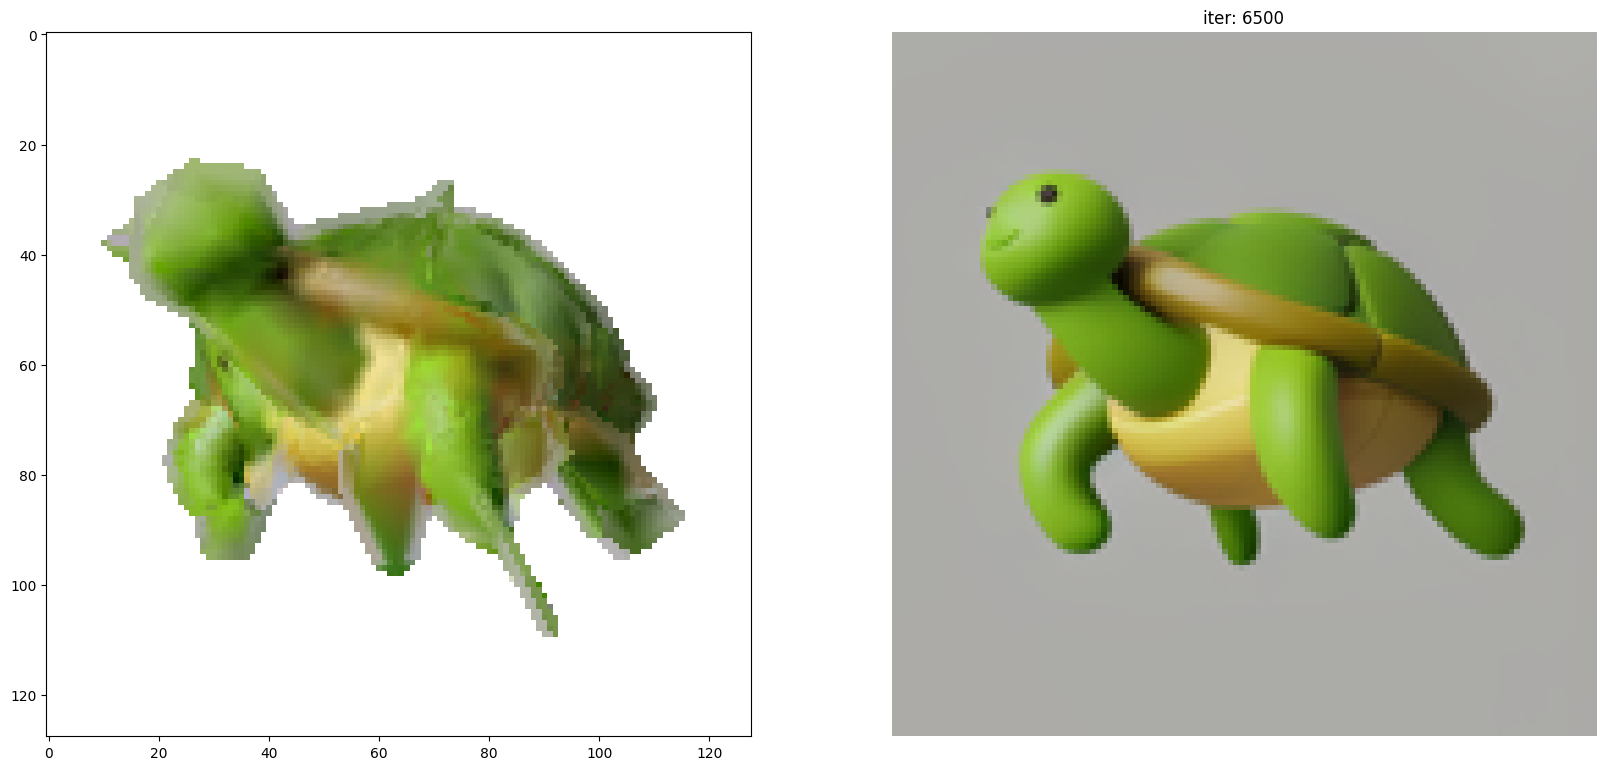

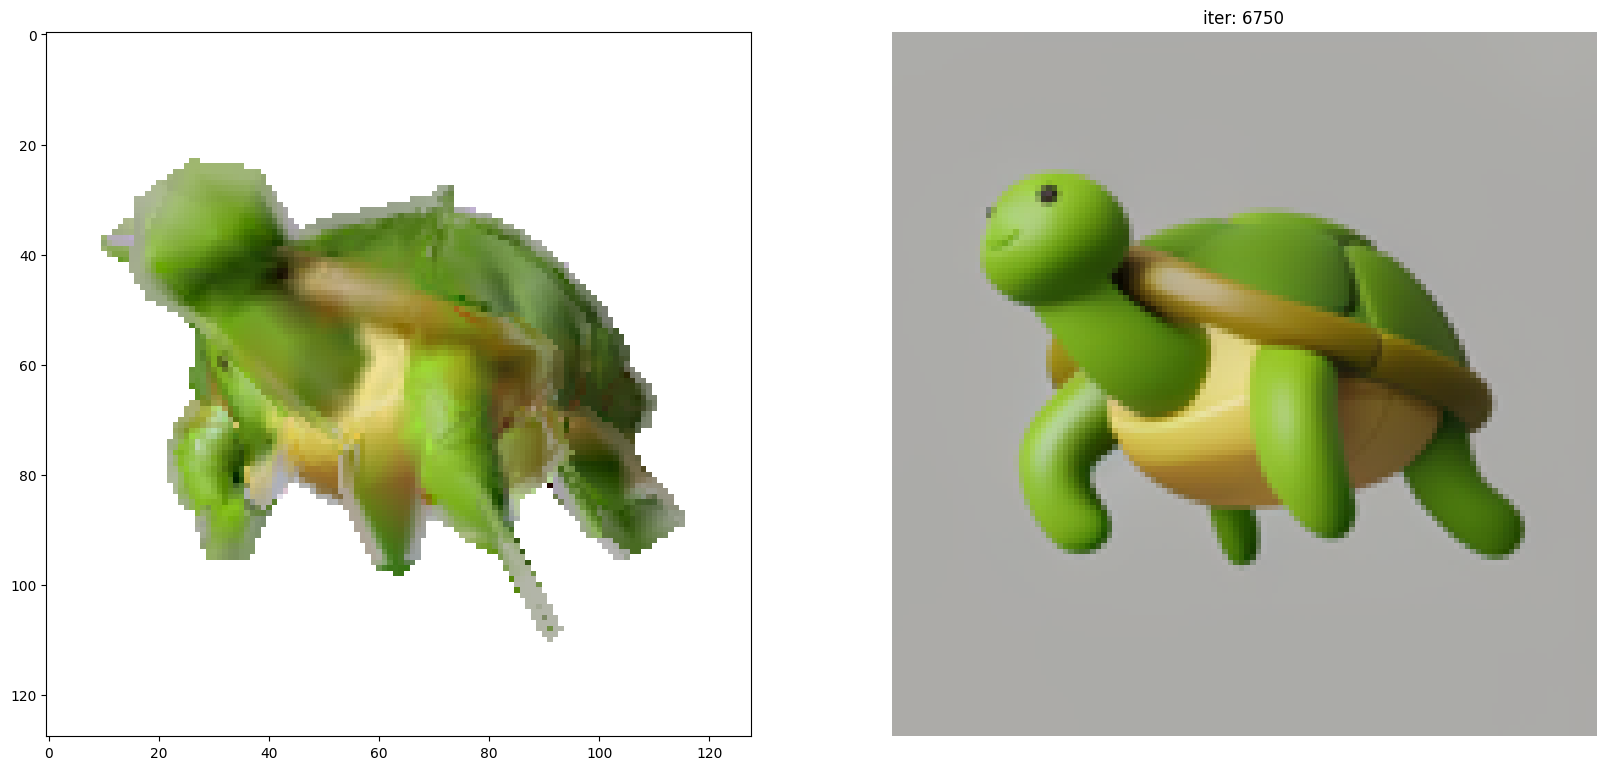

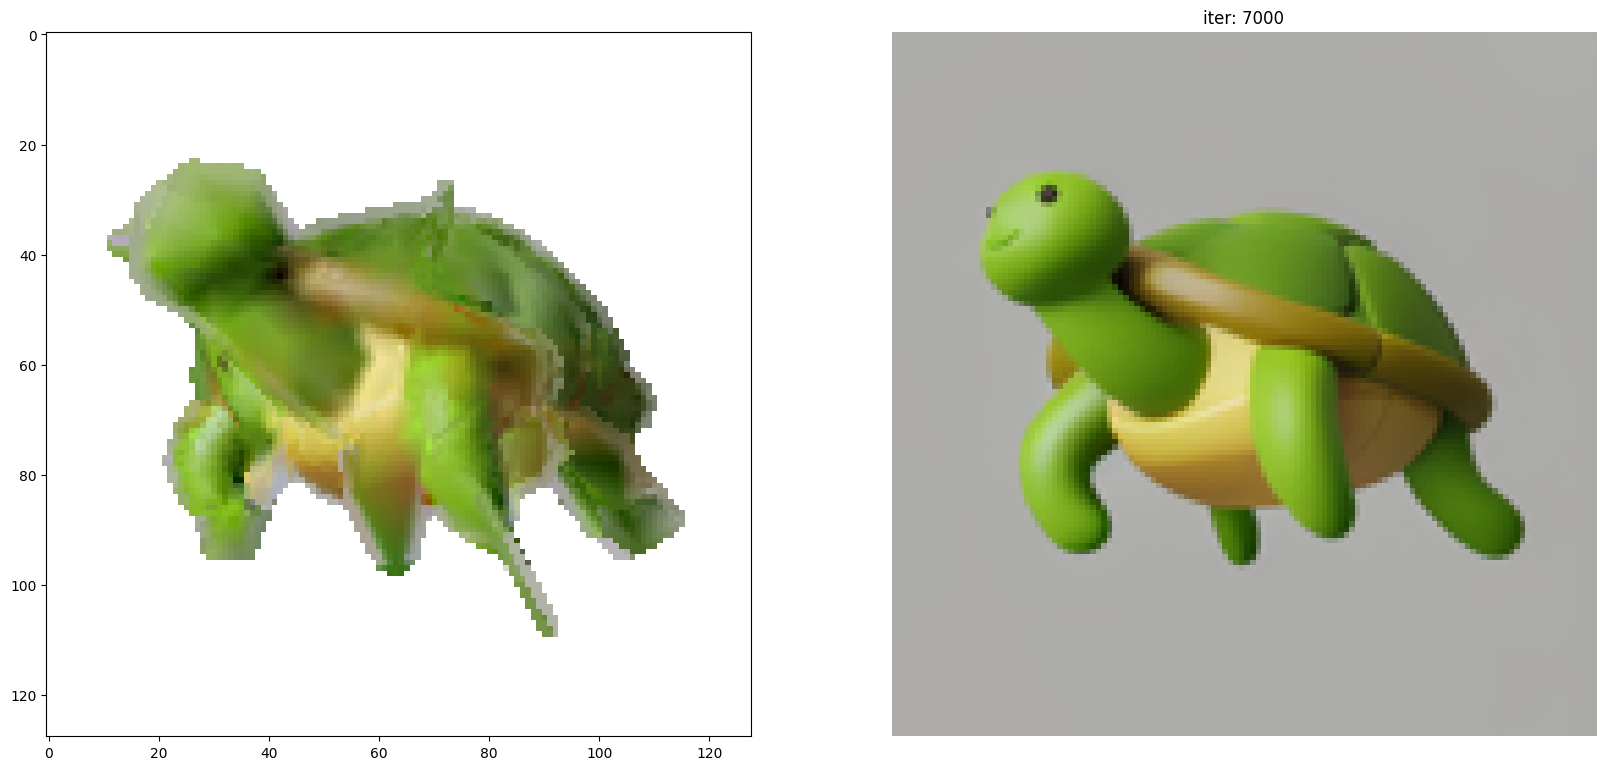

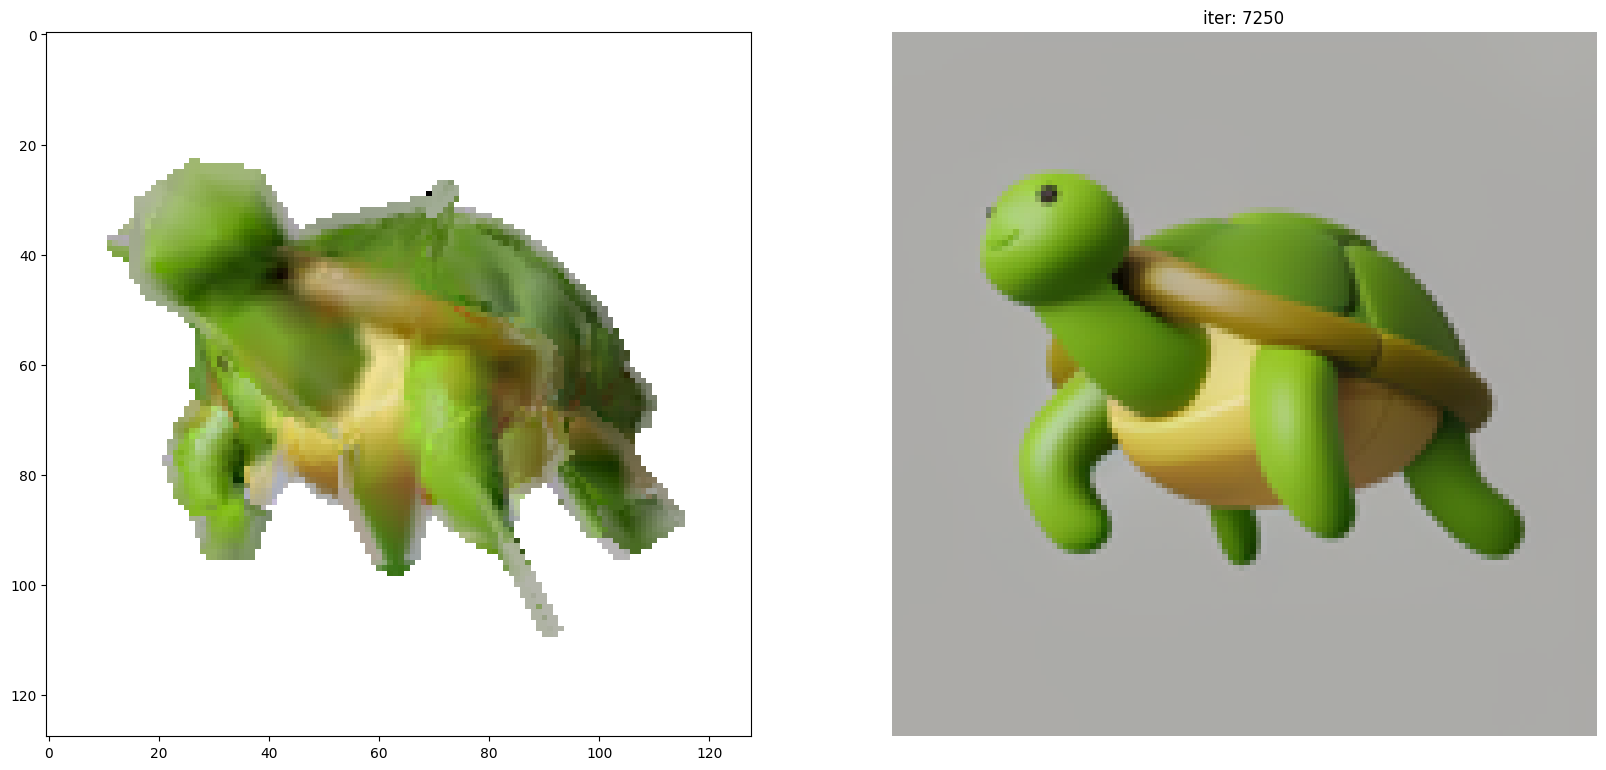

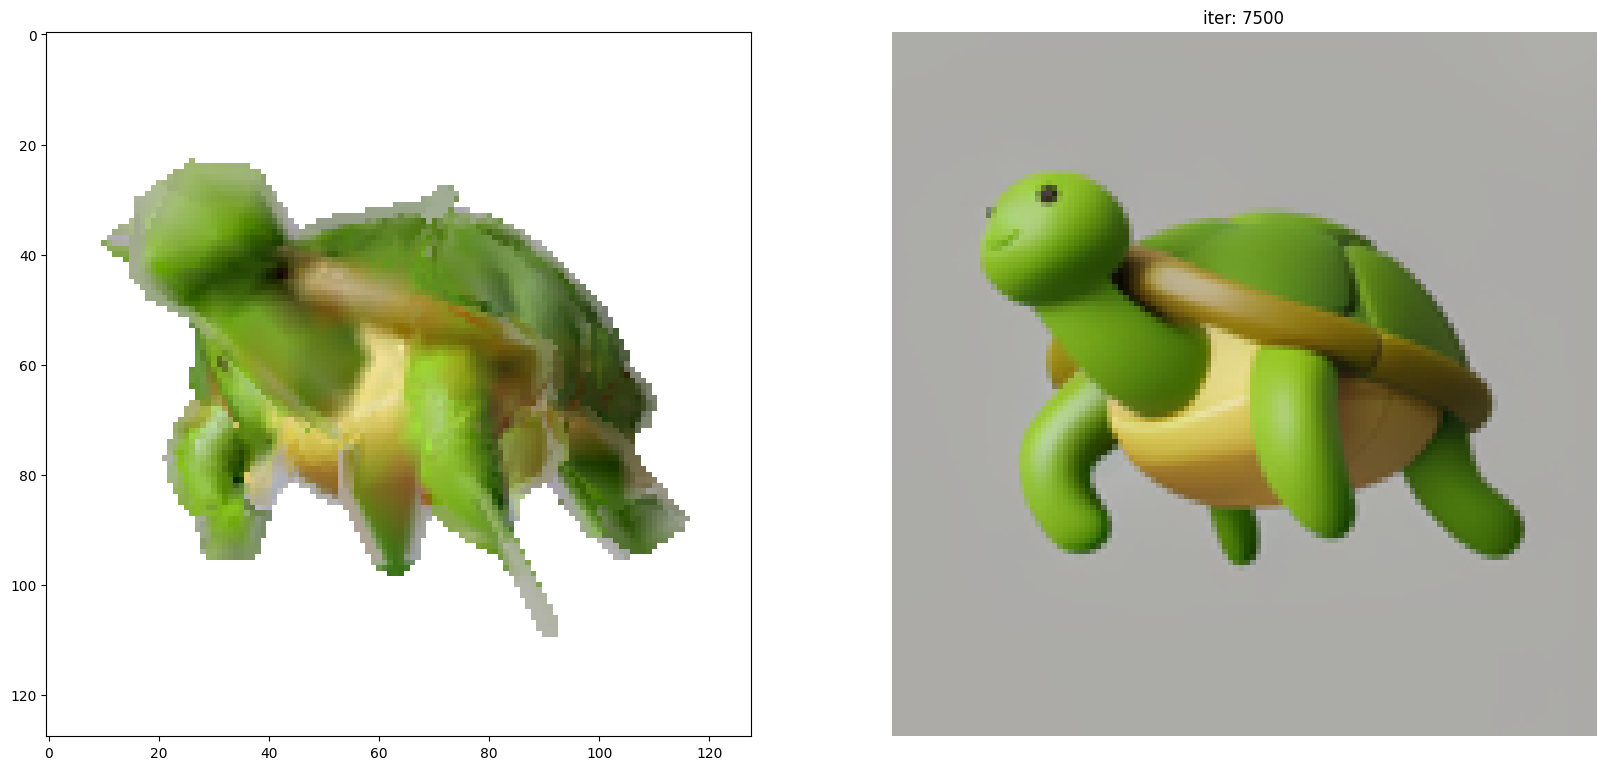

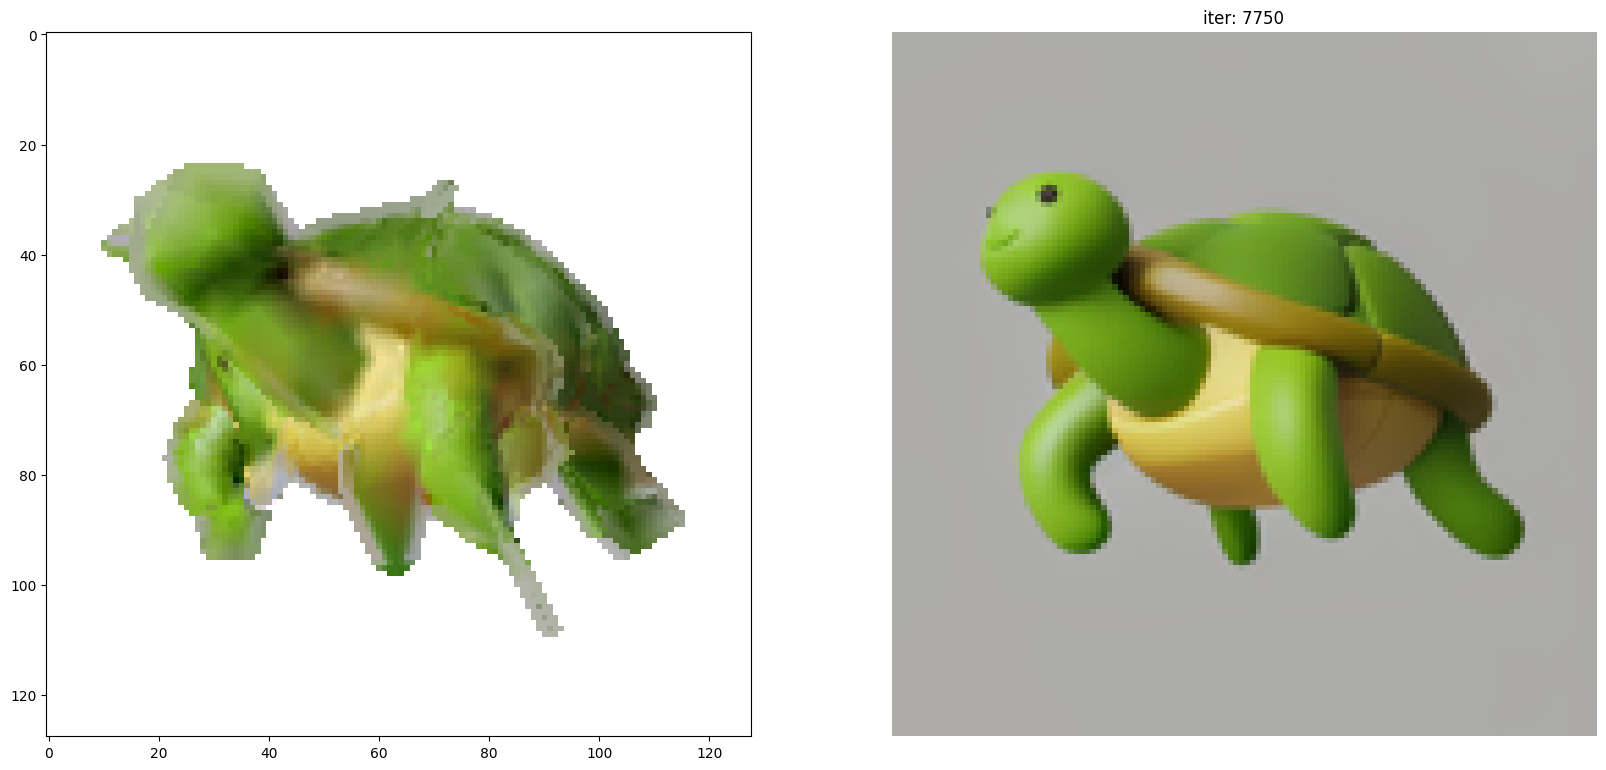

In [108]:
loop = tqdm(range(ITERATIONS))

for i in loop:
    # Initialize optimizer
    optimizer.zero_grad()

    # Deform the mesh
    new_src_mesh = src_mesh.offset_verts(deform_verts)

    # Add per vertex colors to texture the mesh
    new_src_mesh.textures = TexturesVertex(verts_features=sphere_verts_rgb)

    # Losses to smooth /regularize the mesh shape
    loss = {k: torch.tensor(0.0, device=device) for k in losses}
    update_mesh_shape_prior_losses(new_src_mesh, loss)

    # Randomly select two views to optimize over in this iteration.  Compared
    # to using just one view, this helps resolve ambiguities between updating
    # mesh shape vs. updating mesh texture
    for j in np.random.permutation(N_VIEWS).tolist()[:num_views_per_iteration]:
        images_predicted = renderer_textured(new_src_mesh, cameras=target_cameras[j], lights=lights)

        # Squared L2 distance between the predicted silhouette and the target
        # silhouette from our dataset
        predicted_silhouette = images_predicted[..., 3]
        loss_silhouette = ((predicted_silhouette - target_sil[j]) ** 2).mean()
        loss["silhouette"] += loss_silhouette / num_views_per_iteration

        # Squared L2 distance between the predicted RGB image and the target
        # image from our dataset
        predicted_rgb = images_predicted[..., :3]
        loss_rgb = ((predicted_rgb - target_rgb[j]) ** 2).mean()
        loss["rgb"] += loss_rgb / num_views_per_iteration

    # Weighted sum of the losses
    sum_loss = torch.tensor(0.0, device=device)
    for k, l in loss.items():
        sum_loss += l * losses[k]["weight"]
        losses[k]["values"].append(float(l.detach().cpu()))

    # Print the losses
    loop.set_description("total_loss = %.6f" % sum_loss)

    # Plot mesh
    if i % plot_period == 0:
        visualize_prediction(new_src_mesh, renderer=renderer_textured, title="iter: %d" % i, silhouette=False)

    # Optimization step
    sum_loss.backward()
    optimizer.step()
    # scheduler.step()

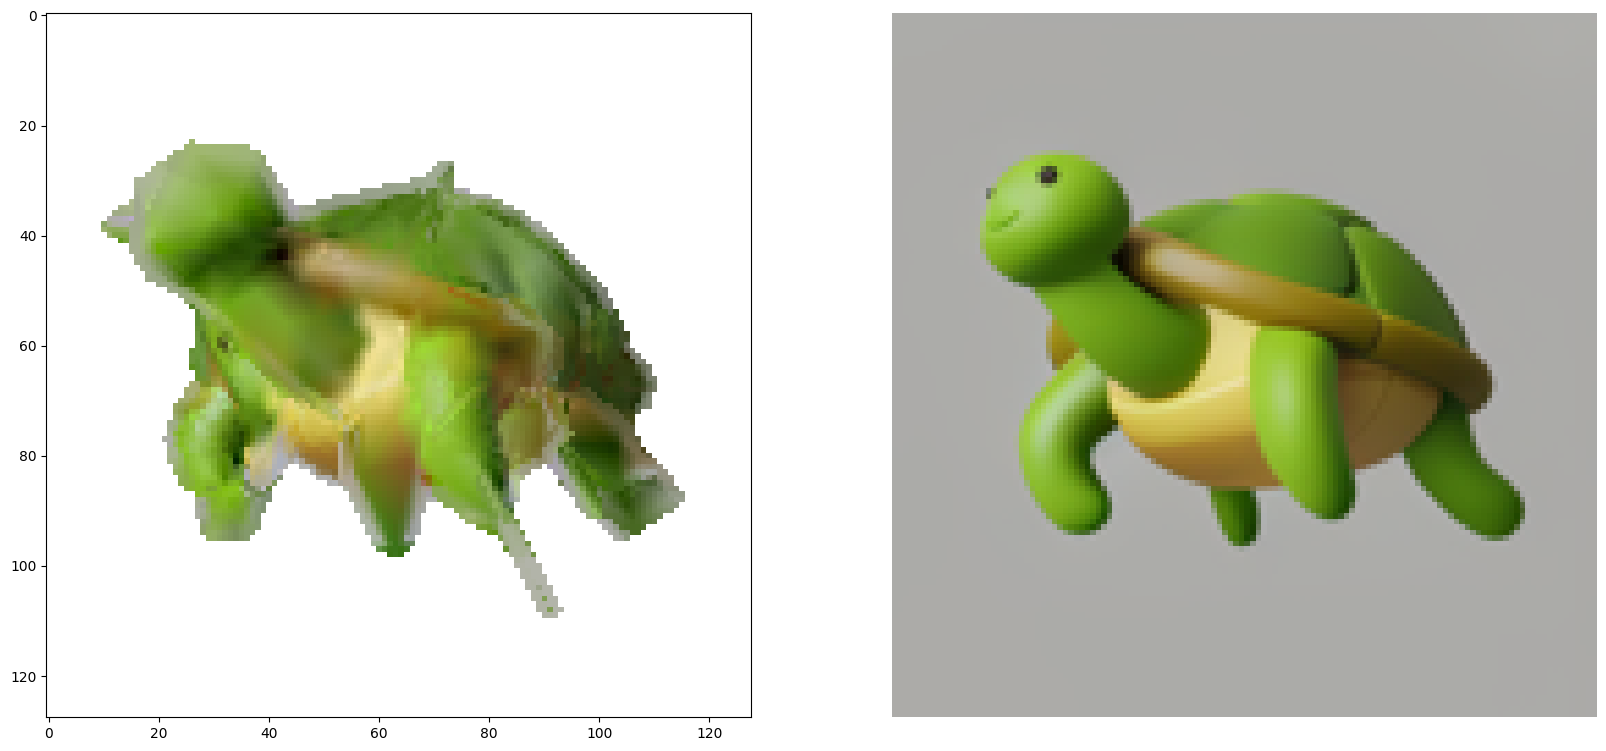

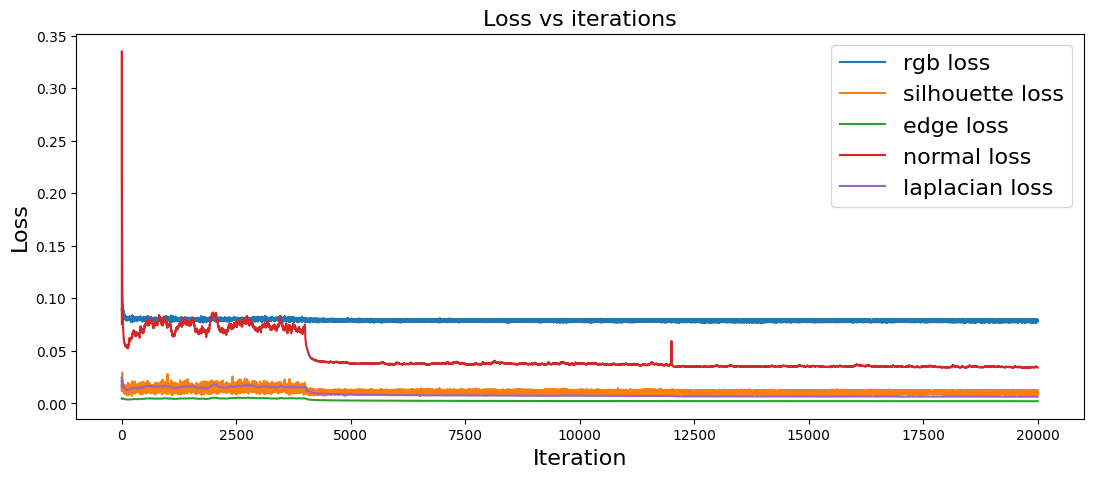

In [109]:
visualize_prediction(new_src_mesh, renderer=renderer_textured, silhouette=False)
plot_losses(losses)

In [111]:
# Fetch the verts and faces of the final predicted mesh
final_verts, final_faces = new_src_mesh.get_mesh_verts_faces(0)

# Scale normalize back to the original target size
final_verts = final_verts

# Store the predicted mesh using save_obj
final_obj = os.path.join('./', 'final_model.obj')
save_obj(final_obj, final_verts, final_faces)

In [125]:
verts = new_src_mesh.verts_packed().detach().clone()
faces = new_src_mesh.faces_packed().detach().clone()

if new_src_mesh.textures is not None:
    tex = new_src_mesh.textures
    verts_colors = tex.verts_features_padded().detach().clone()
    textures = TexturesVertex(verts_features=verts_colors)
else:
    textures = None

safe_mesh = Meshes(verts=[verts], faces=[faces], textures=textures)

In [128]:
import os
import imageio
import torch
from pytorch3d.io import load_obj
from pytorch3d.structures import Meshes
from pytorch3d.renderer import (
    look_at_view_transform,
    OpenGLPerspectiveCameras,
    PointLights,
    RasterizationSettings,
    MeshRenderer,
    MeshRasterizer,
    SoftPhongShader,
    TexturesVertex,
    BlendParams,
)
import matplotlib.pyplot as plt
import numpy as np

def mesh_to_gif(mesh, out_gif_path="mesh_rotation.gif", device="cuda", n_frames=36, image_size=512):
    """
    Renders a rotating mesh and saves as a gif.
    mesh: pytorch3d.structures.Meshes object (batch size == 1).
    out_gif_path: Output path for the gif.
    device: "cuda" or "cpu"
    n_frames: Number of frames in the gif.
    image_size: The rendered image size in pixels.
    """


    if mesh.device != torch.device(device):
        mesh = mesh.to(device)

    # Setup renderer
    R_init, T_init = look_at_view_transform(dist=2.7, elev=20, azim=0)
    cameras_init = FoVPerspectiveCameras(device=device, R=R_init.clone(), T=T_init.clone())

    raster_settings = RasterizationSettings(
        image_size=image_size,
        blur_radius=0.0,
        faces_per_pixel=1,
    )

    lights = PointLights(device=device, location=[[2.0, 2.0, -2.0]])

    renderer = MeshRenderer(
        rasterizer=MeshRasterizer(
            cameras=cameras_init,
            raster_settings=raster_settings
        ),
        shader=SoftPhongShader(
            device=device,
            cameras=cameras_init,
            lights=lights,
            blend_params=BlendParams(background_color=(1,1,1)),
        )
    )

    frames = []
    for i in range(n_frames):
        azim = 360 * (i / n_frames)
        R, T = look_at_view_transform(dist=2.7, elev=20, azim=azim)
        # Out-of-place clone for safety (fixes in-place view modification bug)
        R = R.clone()
        T = T.clone()
        cameras = FoVPerspectiveCameras(device=device, R=R, T=T)

        renderer.shader.cameras = cameras.clone()
        renderer.rasterizer.cameras = cameras.clone()

        images = renderer(mesh).clone()
        image = images[0, ..., :3].detach().cpu().numpy().copy()
        image = (image * 255).astype(np.uint8)
        frames.append(image.copy())

    imageio.mimsave(out_gif_path, frames, fps=15)
    print(f"GIF saved to {out_gif_path}")

mesh_to_gif(safe_mesh, "mesh_rotation.gif", device="cuda", n_frames=36)

# Example usage:
# obj_to_gif(final_obj, out_gif_path="final_model_rotation.gif", device="cuda")


GIF saved to mesh_rotation.gif


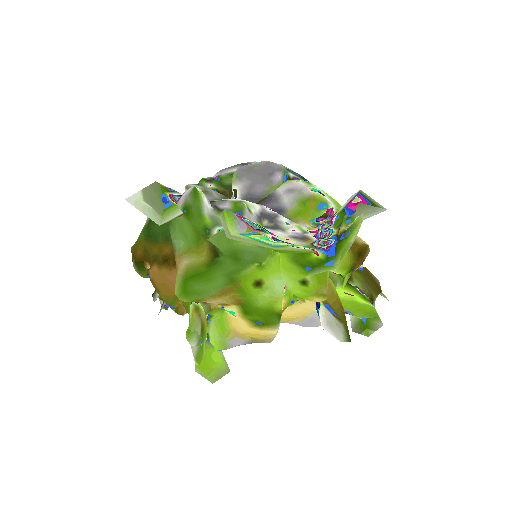

In [ ]:
# from IPython.display import Image

# Image(filename="mesh_rotation.gif")